# Multi-model Toxic Audio Detection ti?ng Vi?t

Notebook này giữ baseline `ToxicCRNN` hiện tại và bổ sung các kiến trúc theo paper: `Lightweight wav2vec2 Transformer`, `ToXCL-inspired detector`, `MuTox-style multilingual detector`, và `Self-attentive CNN`. Pipeline phía dưới cho phép train, validation, test, lưu checkpoint, vẽ confusion matrix/ROC và so sánh metric cho từng model.


## v4 changes: real augmentation + anti-overfitting regularization

This version fixes the previous augmentation plan: duplicated rows were not actually transformed. Training now uses on-the-fly waveform augmentation, SpecAugment, balanced sampling, attention entropy regularization, AdamW weight decay, cosine LR scheduling, early stopping, and progressive Wav2Vec2 freezing. Validation/test audio is not augmented.


# 1. Load Data & EDA

In [2]:
print("hi")

hi


In [3]:
import os
import numpy as np
import pandas as pd

import torch

import torch._dynamo
import torch._dynamo.config

import torchaudio
from tqdm.auto import tqdm
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import StratifiedGroupKFold


a:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\envLab\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ============================================================
# PATH CONFIG
# ============================================================

import os
from pathlib import Path
import pandas as pd

DATASET_FILENAME = (
    "final_vietnamese_toxic_utterance_dataset_v5.1.2_speaker_split.csv"
)

DATASET_DIR_CANDIDATES = [
    Path("..") / "vitosa_datasets",
    Path("vitosa_datasets"),
]

AUDIO_FOLDER_NAME = "wav_segments_v5.1"
RANDOM_STATE = 42

# ============================================================
# FIND DATASET CSV
# ============================================================

BASE_DATASET_DIR = None
FULL_CSV = None

for candidate_dir in DATASET_DIR_CANDIDATES:
    candidate_dir = candidate_dir.resolve()
    candidate_csv = candidate_dir / DATASET_FILENAME

    if candidate_csv.exists():
        BASE_DATASET_DIR = candidate_dir
        FULL_CSV = candidate_csv
        break

if FULL_CSV is None:
    checked_paths = [
        str(d.resolve() / DATASET_FILENAME)
        for d in DATASET_DIR_CANDIDATES
    ]
    raise FileNotFoundError(
        "Cannot find dataset CSV.\n\n"
        "Checked:\n" + "\n".join(checked_paths)
    )

AUDIO_DIR = BASE_DATASET_DIR / AUDIO_FOLDER_NAME

if not AUDIO_DIR.exists():
    raise FileNotFoundError(
        f"Cannot find audio folder:\n{AUDIO_DIR}\n\n"
        f"Expected structure:\n"
        f"{BASE_DATASET_DIR}\n"
        f"├── {DATASET_FILENAME}\n"
        f"└── {AUDIO_FOLDER_NAME}\n"
        f"    ├── *.wav\n"
        f"    └── ..."
    )

print("=" * 70)
print("PATH CONFIG")
print("=" * 70)
print(f"Dataset directory : {BASE_DATASET_DIR}")
print(f"Dataset CSV       : {FULL_CSV}")
print(f"Audio directory   : {AUDIO_DIR}")

# ============================================================
# BUILD FULL AUDIO PATH
# ============================================================

def build_full_audio_path(audio_filename):
    if pd.isna(audio_filename):
        return None

    audio_filename = str(audio_filename).strip()
    if not audio_filename:
        return None

    audio_filename = Path(audio_filename).name
    return str((AUDIO_DIR / audio_filename).resolve())

# ============================================================
# LOAD DATASET
# ============================================================

full_df = pd.read_csv(FULL_CSV)

required_columns = {
    "audio_path",
    "toxicity",
    "split",
}

missing_columns = required_columns - set(full_df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

# ============================================================
# NORMALIZE SPLIT
# ============================================================

full_df["split"] = (
    full_df["split"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# validation -> val
full_df["split"] = full_df["split"].replace({
    "validation": "val",
})

# Completely ignore external_non_toxic
before_external_count = len(full_df)

full_df = full_df[
    full_df["split"] != "external_non_toxic"
].copy()

removed_external_count = (
    before_external_count - len(full_df)
)

print(
    f"Removed external_non_toxic samples: "
    f"{removed_external_count:,}"
)

EXPECTED_SPLITS = {
    "train",
    "val",
    "test",
}

unexpected_splits = sorted(
    set(full_df["split"].unique()) - EXPECTED_SPLITS
)

if unexpected_splits:
    raise ValueError(
        f"Unexpected split values: {unexpected_splits}"
    )

# ============================================================
# WAV-ONLY AUDIO FILENAME
# ============================================================

def normalize_audio_filename(filename):
    if pd.isna(filename):
        return None

    filename = str(filename).strip()

    if not filename:
        return None

    filename = Path(filename).name

    # Do NOT convert .npz -> .wav silently.
    # The current dataset must contain real WAV filenames.
    if not filename.lower().endswith(".wav"):
        raise ValueError(
            f"Non-WAV audio entry found: {filename}"
        )

    return filename

full_df["audio_path"] = (
    full_df["audio_path"]
    .apply(normalize_audio_filename)
)

full_df["audio_full_path"] = (
    full_df["audio_path"]
    .apply(build_full_audio_path)
)

# ============================================================
# CHECK WAV FILES
# ============================================================

full_df["audio_exists"] = (
    full_df["audio_full_path"]
    .apply(
        lambda x:
        x is not None and os.path.isfile(x)
    )
)

missing_audio_df = full_df[
    ~full_df["audio_exists"]
].copy()

if len(missing_audio_df) > 0:
    print("\n" + "=" * 70)
    print("ERROR: MISSING WAV FILES")
    print("=" * 70)
    print(f"Missing audio: {len(missing_audio_df):,}")
    print(
        missing_audio_df[
            ["audio_path", "audio_full_path"]
        ].head(20)
    )

    raise FileNotFoundError(
        f"{len(missing_audio_df):,} WAV files are missing. "
        "Fix audio paths before training."
    )

print("\n[OK] All WAV audio files exist.")

# ============================================================
# DATASET SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"Total samples: {len(full_df):,}")

print("\nToxicity:")
print(full_df["toxicity"].value_counts())

print("\nSplit x toxicity:")
print(
    pd.crosstab(
        full_df["split"],
        full_df["toxicity"]
    )
)

print("\nAudio existence:")
print(full_df["audio_exists"].value_counts())

# ============================================================
# SPLITS
# ============================================================

train_df = (
    full_df[full_df["split"] == "train"]
    .reset_index(drop=True)
)

val_df = (
    full_df[full_df["split"] == "val"]
    .reset_index(drop=True)
)

test_df = (
    full_df[full_df["split"] == "test"]
    .reset_index(drop=True)
)

if min(
    len(train_df),
    len(val_df),
    len(test_df),
) == 0:
    raise ValueError(
        "One split is empty. "
        "Check the split column in the CSV."
    )

train_df = (
    train_df
    .sample(
        frac=1,
        random_state=RANDOM_STATE,
    )
    .reset_index(drop=True)
)

for split_name, split_df in [
    ("TRAIN", train_df),
    ("VAL", val_df),
    ("TEST", test_df),
]:
    print("\n" + "=" * 70)
    print(split_name)
    print("=" * 70)
    print(f"Samples: {len(split_df):,}")
    print(split_df["toxicity"].value_counts())


PATH CONFIG
Dataset directory : A:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\vitosa_datasets
Dataset CSV       : A:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\vitosa_datasets\final_vietnamese_toxic_utterance_dataset_v5.1.2_speaker_split.csv
Audio directory   : A:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\vitosa_datasets\wav_segments_v5.1
Removed external_non_toxic samples: 7,610

[OK] All WAV audio files exist.

DATASET SUMMARY
Total samples: 24,693

Toxicity:
toxicity
0    12366
1    12327
Name: count, dtype: int64

Split x toxicity:
toxicity     0     1
split               
test      1000  1000
train     8968  8946
val       2398  2381

Audio existence:
audio_exists
True    24693
Name: count, dtype: int64

TRAIN
Samples: 17,914
toxicity
0    8968
1    8946
Name: count, dtype: int64

VAL
Samples: 4,779
toxicity
0    2398
1    2381
Name: count, dtype: int64

TEST
Samples: 2,000
toxicity
1    1000
0    1000
Name: count, dtype: int64


In [5]:
print(full_df.columns.tolist())

['audio_source', 'audio_path', 'sampling_rate', 'transcript', 'toxicity', 'split', 'toxic_spans_text', 'BIO_Tag', 'start_sec', 'end_sec', 'duration', '__row_id', 'pseudo_speaker_id', 'audio_full_path', 'audio_exists']


In [6]:
# ============================================================
# TOXIC WITH SPAN - CREATE DATA AUGMENTATION TRAIN
# ============================================================

if "toxic_spans_text" not in train_df.columns:
    train_df = train_df.copy()
    train_df["toxic_spans_text"] = ""

span_text = (
    train_df["toxic_spans_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

toxic_span_df = train_df[
    (train_df["toxicity"] == 1)
    &
    (span_text != "")
].copy()

# ============================================================
# TOXIC WITHOUT SPAN
# ============================================================

toxic_no_span_df = train_df[
    (train_df["toxicity"] == 1)
    &
    (span_text == "")
].copy()

# ============================================================
# NON TOXIC
# ============================================================

non_toxic_df = train_df[
    train_df["toxicity"] == 0
].copy()

print("Toxic with span :", len(toxic_span_df))
print("Toxic no span   :", len(toxic_no_span_df))
print("Non toxic       :", len(non_toxic_df))


Toxic with span : 8946
Toxic no span   : 0
Non toxic       : 8968


In [7]:
# ============================================================
# TRAINING AUGMENTATION CONFIG
# ============================================================
#
# IMPORTANT:
# The previous notebook duplicated rows and only stored
# augment_type. The Dataset did not actually transform the audio,
# so those duplicated rows were effectively identical samples.
#
# This version performs REAL on-the-fly augmentation in the
# Dataset and balances the highly imbalanced train split with
# WeightedRandomSampler.
# ============================================================

AUGMENT_CONFIG = {
    # Waveform augmentation
    "noise_std": 0.003,
    "noise_prob": 0.50,

    "time_shift_max_seconds": 0.50,
    "time_shift_prob": 0.50,

    "gain_min": 0.80,
    "gain_max": 1.20,
    "gain_prob": 0.50,

    # Real acoustic augmentation
    "background_noise_prob": 0.50,
    "reverb_prob": 0.40,
    "acoustic_prob": 0.30,

    # Mel SpecAugment
    "freq_mask_param": 15,
    "time_mask_param": 35,
    "specaugment_prob": 0.75,

    # Attention regularization
    # Small value; tune in [0.0005, 0.005].
    "attention_entropy_weight": 0.001,
}

# Do NOT duplicate toxic rows here.
# Keep the speaker-independent split unchanged.
train_df = train_df.copy()
train_df["augment_type"] = "on_the_fly"

print("=" * 70)
print("TRAINING AUGMENTATION")
print("=" * 70)
print("On-the-fly waveform augmentation: ENABLED")
print("  - Gaussian noise")
print("  - Time shifting")
print("  - Random gain")
print("SpecAugment: ENABLED")
print("Class balancing: WeightedRandomSampler")
print("Attention entropy regularization: ENABLED")
print()
print("Train size:", len(train_df))
print("\nOriginal train toxicity distribution:")
print(train_df["toxicity"].value_counts())


TRAINING AUGMENTATION
On-the-fly waveform augmentation: ENABLED
  - Gaussian noise
  - Time shifting
  - Random gain
SpecAugment: ENABLED
Class balancing: WeightedRandomSampler
Attention entropy regularization: ENABLED

Train size: 17914

Original train toxicity distribution:
toxicity
0    8968
1    8946
Name: count, dtype: int64


In [8]:
# ============================================================
# AUGMENTATION AUDIT
# ============================================================

print("=" * 70)
print("AUGMENTATION AUDIT")
print("=" * 70)

print("REAL waveform augmentation:")
print("  ✓ Gaussian noise")
print("  ✓ Zero-padded time shift ±0.5 sec")
print("  ✓ Random gain 0.80x - 1.20x")

print("\nMel augmentation:")
print("  ✓ Frequency masking")
print("  ✓ Time masking")

print("\nTraining regularization:")
print("  ✓ WeightedRandomSampler for class imbalance")
print("  ✓ Attention entropy penalty on toxic samples")
print("  ✓ AdamW weight decay = 0.01")
print("  ✓ CosineAnnealingLR")
print("  ✓ Gradient clipping")
print("  ✓ Early stopping")

print("\nWav2Vec2:")
print("  ✓ Feature extractor frozen")
print("  ✓ First 6 Transformer encoder layers frozen")
print("  ✓ Only later encoder layers + task heads fine-tuned")


AUGMENTATION AUDIT
REAL waveform augmentation:
  ✓ Gaussian noise
  ✓ Zero-padded time shift ±0.5 sec
  ✓ Random gain 0.80x - 1.20x

Mel augmentation:
  ✓ Frequency masking
  ✓ Time masking

Training regularization:
  ✓ WeightedRandomSampler for class imbalance
  ✓ Attention entropy penalty on toxic samples
  ✓ AdamW weight decay = 0.01
  ✓ CosineAnnealingLR
  ✓ Gradient clipping
  ✓ Early stopping

Wav2Vec2:
  ✓ Feature extractor frozen
  ✓ First 6 Transformer encoder layers frozen
  ✓ Only later encoder layers + task heads fine-tuned


In [9]:

import os
import random
import glob

import torch
import torch.nn.functional as F
import torchaudio


# ============================================================
# REALISTIC WAVFORM AUGMENTATION
# For Wav2Vec2 raw waveform models
# ============================================================

NOISE_FOLDER = "dataset/noise"


def time_shift_waveform(waveform, max_shift_samples):
    if max_shift_samples <= 0:
        return waveform

    shift = random.randint(
        -max_shift_samples,
        max_shift_samples,
    )

    if shift == 0:
        return waveform

    shifted = torch.zeros_like(waveform)

    if shift > 0:
        shifted[..., shift:] = waveform[..., :-shift]
    else:
        shifted[..., :shift] = waveform[..., -shift:]

    return shifted


def load_random_noise(length, sample_rate):
    noise_files = glob.glob(
        os.path.join(NOISE_FOLDER, "*.wav")
    )

    if not noise_files:
        return None

    path = random.choice(noise_files)

    noise, sr = torchaudio.load(path)
    noise = noise.mean(dim=0)

    if sr != sample_rate:
        noise = torchaudio.functional.resample(
            noise,
            sr,
            sample_rate,
        )

    if noise.numel() < length:
        noise = F.pad(
            noise,
            (0, length - noise.numel())
        )
    else:
        start = random.randint(
            0,
            noise.numel() - length
        )
        noise = noise[start:start + length]

    return noise


def add_background_noise(
    waveform,
    sample_rate,
    snr_range=(5, 20),
):
    noise = load_random_noise(
        waveform.numel(),
        sample_rate,
    )

    if noise is None:
        return waveform

    signal_power = waveform.pow(2).mean()
    noise_power = noise.pow(2).mean() + 1e-8

    snr_db = random.uniform(*snr_range)

    scale = torch.sqrt(
        signal_power /
        (noise_power * 10 ** (snr_db / 10))
    )

    return waveform + noise * scale


def add_reverb(
    waveform,
    sample_rate,
):
    delay = random.randint(
        int(0.02 * sample_rate),
        int(0.15 * sample_rate),
    )

    decay = random.uniform(
        0.2,
        0.6,
    )

    echo = torch.zeros_like(waveform)

    if delay < waveform.numel():
        echo[delay:] = waveform[:-delay] * decay

    return waveform + echo


def acoustic_effect(waveform):

    # microphone clipping
    if random.random() < 0.2:
        threshold = random.uniform(
            0.6,
            0.9,
        )
        waveform = torch.clamp(
            waveform,
            -threshold,
            threshold,
        )

    # microphone gain variation
    if random.random() < 0.3:
        waveform = waveform * random.uniform(
            0.7,
            1.3,
        )

    return waveform


def augment_waveform(
    waveform,
    sample_rate=16000,
    noise_std=0.003,
    noise_prob=0.3,
    time_shift_max_seconds=0.5,
    time_shift_prob=0.3,
    gain_min=0.8,
    gain_max=1.2,
    gain_prob=0.3,
):
    """
    Realistic augmentation:
    - gain
    - time shift
    - Gaussian noise
    - background environmental noise
    - room echo/reverb
    - acoustic microphone effects
    """

    if random.random() < gain_prob:
        waveform *= random.uniform(
            gain_min,
            gain_max,
        )

    if random.random() < time_shift_prob:
        waveform = time_shift_waveform(
            waveform,
            int(
                sample_rate *
                time_shift_max_seconds
            ),
        )

    if random.random() < noise_prob:
        waveform += (
            torch.randn_like(waveform)
            * noise_std
        )

    # real environment noise
    if random.random() < 0.5:
        waveform = add_background_noise(
            waveform,
            sample_rate,
            snr_range=(5,20),
        )

    # room acoustic / echo
    if random.random() < 0.4:
        waveform = add_reverb(
            waveform,
            sample_rate,
        )

    waveform = acoustic_effect(
        waveform
    )

    return waveform.clamp(-1,1)


In [10]:
# ============================================================
# DATASET PIPELINE
# ============================================================
# Only ToxicSpeechDataset is used.
# Split is already provided by speaker_split CSV.
# Augmentation is applied only inside Dataset when is_train=True.


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ==========================================
# 1. BỘ LỌC SỰ TẬP TRUNG (ATTENTION POOLING)
# ==========================================
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # Mạng Neural nhỏ xíu để tính điểm "Độc hại" cho từng Frame thời gian
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape đầu vào từ GRU: (Batch, Time, Hidden)
        
        scores = self.attn(x) # Shape: (Batch, Time, 1)
        weights = torch.softmax(scores, dim=1) # Chuyển điểm thành tỷ lệ % (Tổng = 1.0)
        
        # Lấy các frame nhân với trọng số của nó rồi cộng dồn lại
        context = torch.sum(x * weights, dim=1) # Shape: (Batch, Hidden)
        
        return context, weights

# ==========================================
# 2. KIẾN TRÚC MẠNG LÕI (TOXIC-CRNN)
# ==========================================
class ToxicCRNN(nn.Module):
    def __init__(self, n_mels=64, hidden_dim=128):
        super().__init__()
        
        # --- GIAI ĐOẠN 1: CNN (Trích xuất đặc trưng hình ảnh) ---
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2) # Giảm nửa Chiều cao (Tần số) & Chiều ngang (Thời gian)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 1)) # Lần này CHỈ giảm Chiều cao (Tần số), giữ nguyên Thời gian
        
        # Tính toán kích thước dữ liệu sau khi đi qua CNN
        # Ban đầu n_mels = 64 -> pool1 còn 32 -> pool2 còn 16.
        # Số channels hiện tại là 64. Vậy kích thước dải tần số là: 64 * 16 = 1024
        self.rnn_input_dim = 64 * (n_mels // 4)

        # --- GIAI ĐOẠN 2: BiGRU (Học mạch ngữ cảnh thời gian) ---
        self.gru = nn.GRU(
            input_size=self.rnn_input_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True # Học cả chiều xuôi và ngược
        )

        # --- GIAI ĐOẠN 3: Attention (Tìm điểm nhấn chửi thề) ---
        self.attention = AttentionPooling(hidden_dim * 2) # * 2 vì là mạng 2 chiều (Bidirectional)

        # --- GIAI ĐOẠN 4: Bộ phân loại cuối cùng (Classifier) ---
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3), # Chống học vẹt
            nn.Linear(64, 1) # Đầu ra 1 số duy nhất (Logit) để phân loại Toxic/Non-Toxic
        )

    def forward(self, x):
        # Đầu vào x từ Dataset có shape: (Batch Size, 1, 64 mels, 400 frames)
        
        # 1. Đi qua CNN
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x) # Shape: (Batch, 32, 32, 200)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x) # Shape: (Batch, 64, 16, 200)

        # 2. Xoay Rubik (Reshape) để nạp vào RNN
        batch_size, channels, freq, time = x.size()
        x = x.permute(0, 3, 1, 2).contiguous() # Đẩy chiều Time lên trước: (Batch, Time, Channels, Freq)
        x = x.view(batch_size, time, channels * freq) # Gộp Freq và Channels: (Batch, 200, 1024)

        # 3. Đi qua BiGRU
        out, _ = self.gru(x) # Shape: (Batch, 200, 256)

        # 4. Đi qua Attention
        context, attn_weights = self.attention(out) # context: (Batch, 256) | weights: (Batch, 200, 1)

        # 5. Phân loại
        logits = self.classifier(context) # Shape: (Batch, 1)
        
        return logits, attn_weights

print("✅ Đã lắp ráp thành công động cơ TOXIC-CRNN!")

✅ Đã lắp ráp thành công động cơ TOXIC-CRNN!


# Datasets

In [12]:
from torch.utils.data import Dataset


class ToxicSpeechDataset(Dataset):
    """
    Raw WAV dataset for Wav2Vec2-based models.

    Training augmentation:
      - random gain
      - time shift
      - Gaussian noise
      - environmental background noise
      - room echo/reverb
      - microphone acoustic distortion

    Validation/test are untouched.
    """

    def __init__(
        self,
        dataframe,
        sample_rate: int = 16000,
        max_seconds: float = 8.0,
        is_train: bool = False,
        noise_std: float = 0.003,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.sample_rate = sample_rate
        self.max_samples = int(
            sample_rate * max_seconds
        )
        self.is_train = is_train
        self.noise_std = noise_std

    def __len__(self):
        return len(self.df)

    def _load_audio(self, audio_path):
        if not os.path.isfile(audio_path):
            raise FileNotFoundError(
                f"Audio file not found:\n{audio_path}"
            )

        waveform, original_sample_rate = (
            torchaudio.load(audio_path)
        )

        if waveform.ndim == 1:
            waveform = waveform.unsqueeze(0)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(
                dim=0,
                keepdim=True,
            )

        if original_sample_rate != self.sample_rate:
            waveform = torchaudio.functional.resample(
                waveform,
                orig_freq=original_sample_rate,
                new_freq=self.sample_rate,
            )

        return waveform.squeeze(0)

    def _fix_length(self, waveform):
        if waveform.numel() < self.max_samples:
            waveform = F.pad(
                waveform,
                (
                    0,
                    self.max_samples - waveform.numel(),
                ),
            )
        else:
            # Keep the original deterministic 8-second window.
            # We do not randomly crop weakly-labelled toxic clips,
            # because the toxic event may be anywhere in the clip.
            waveform = waveform[
                :self.max_samples
            ]

        return waveform

    def __getitem__(self, idx):
        audio_path = self.df.loc[
            idx,
            "audio_full_path",
        ]

        label = float(
            self.df.loc[
                idx,
                "toxicity",
            ]
        )

        waveform = self._load_audio(
            audio_path
        )

        waveform = self._fix_length(
            waveform
        )

        # Normalize first.
        waveform = (
            waveform - waveform.mean()
        )
        waveform = waveform / (
            waveform.abs().max() + 1e-6
        )

        # REAL waveform augmentation.
        if self.is_train:
            waveform = augment_waveform(
                waveform,
                sample_rate=self.sample_rate,
                noise_std=self.noise_std,
                noise_prob=AUGMENT_CONFIG["noise_prob"],
                time_shift_max_seconds=AUGMENT_CONFIG[
                    "time_shift_max_seconds"
                ],
                time_shift_prob=AUGMENT_CONFIG[
                    "time_shift_prob"
                ],
                gain_min=AUGMENT_CONFIG["gain_min"],
                gain_max=AUGMENT_CONFIG["gain_max"],
                gain_prob=AUGMENT_CONFIG["gain_prob"],
            )

        return (
            waveform,
            torch.tensor(
                label,
                dtype=torch.float32,
            ),
        )


# Unified Audio Dataset Pipeline

Pipeline:

```
CSV speaker split
        |
        v
Load train / validation / test
        |
        v
Audio preprocessing
- load wav
- mono
- resample 16kHz
- fixed length 8s
- normalize
        |
        v
Training only augmentation
- background noise
- reverberation
- acoustic distortion
- Gaussian noise
- gain
- time shift
        |
        v
DataLoader
        |
        v
All models
```

Validation/Test are never augmented.


In [13]:

# ============================================================
# BUILD FINAL DATASET AFTER SPLIT
# ============================================================

from torch.utils.data import DataLoader


def prepare_audio_dataframe(df):
    """
    Prepare dataframe only.
    No augmentation here.
    """

    df = df.copy()

    df["audio_full_path"] = (
        df["audio_path"]
        .apply(
            lambda x: str(
                AUDIO_DIR / Path(x).name
            )
        )
    )

    df = df[
        df["audio_full_path"]
        .apply(os.path.isfile)
    ].reset_index(drop=True)

    return df



# use existing speaker split
train_df = prepare_audio_dataframe(train_df)
val_df   = prepare_audio_dataframe(val_df)
test_df  = prepare_audio_dataframe(test_df)


print("="*60)
print("FINAL DATASET")
print("="*60)

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)



# ============================================================
# DATASET OBJECTS
# ============================================================

train_dataset = ToxicSpeechDataset(
    train_df,
    sample_rate=16000,
    max_seconds=8,
    is_train=True,
)


val_dataset = ToxicSpeechDataset(
    val_df,
    sample_rate=16000,
    max_seconds=8,
    is_train=False,
)


test_dataset = ToxicSpeechDataset(
    test_df,
    sample_rate=16000,
    max_seconds=8,
    is_train=False,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)


val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)


test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)


print("\nDataset ready.")


FINAL DATASET
Train: 17914
Validation: 4779
Test: 2000

Dataset ready.


a:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\envLab\Lib\site-packages\torchaudio\functional\functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


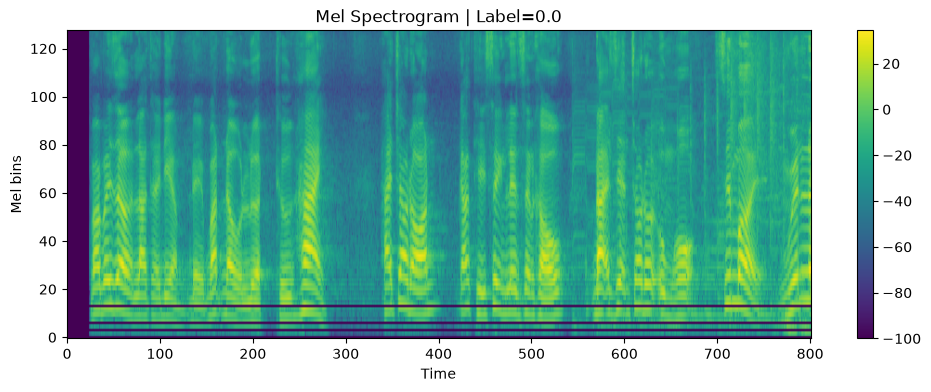

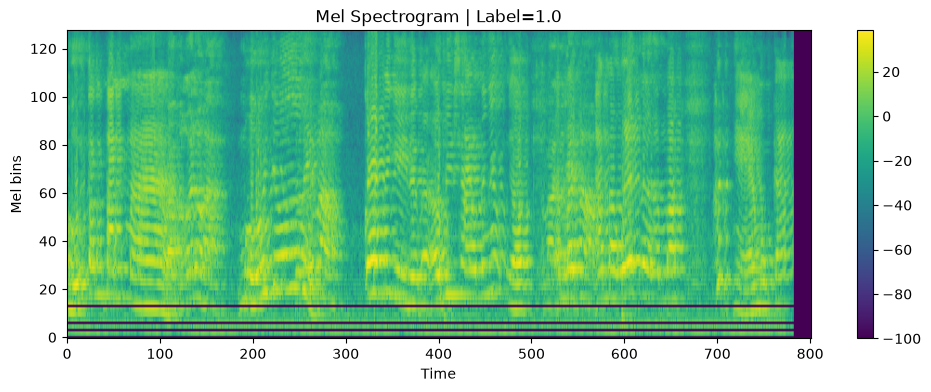

In [14]:
import matplotlib.pyplot as plt


# ============================================================
# VISUALIZE MEL SPECTROGRAM
# ============================================================
def visualize_mel_spectrogram(
    dataset,
    index=0,
    sample_rate=16000,
):

    waveform, label = dataset[index]


    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_mels=128,
        n_fft=400,
        hop_length=160,
    )


    mel = mel_transform(
        waveform.unsqueeze(0)
    )


    mel_db = torchaudio.transforms.AmplitudeToDB()(
        mel
    )


    plt.figure(figsize=(12,4))

    plt.imshow(
        mel_db.squeeze(0)
        .numpy(),
        origin="lower",
        aspect="auto",
    )

    plt.title(
        f"Mel Spectrogram | Label={label.item()}"
    )

    plt.xlabel("Time")
    plt.ylabel("Mel bins")

    plt.colorbar()

    plt.show()


visualize_mel_spectrogram(
    train_dataset,
    index=0
)

visualize_mel_spectrogram(
    train_dataset,
    index=1
)

# 2. Model Architectures theo Paper

Các cell dưới đây bổ sung 4 hướng kiến trúc audio toxicity detection bên cạnh baseline `ToxicCRNN` hiện tại. Tất cả model được chuẩn hóa để trả về tuple (logits, aux) giống pipeline cũ, trong đó logits có shape (batch, 1) và aux chứa attention/explanation/metadata phục vụ phân tích.

> Lưu ý triển khai: các model wav2vec2 dùng `transformers`. Nếu máy chưa cài package hoặc chưa cache checkpoint, hãy cài `transformers` và tải checkpoint trước khi train.


# 2.1 Lightweight Toxicity Detection in Spoken Language: Transformer for Edge Devices

**Paper:** [Lightweight Toxicity Detection in Spoken Language: A Transformer-based Approach for Edge Devices](https://arxiv.org/abs/2304.11408)

**Kiến trúc:** WAV → mono 16 kHz waveform → wav2vec 2.0 feature extractor → Transformer encoder → attention/mean pooling → classification head.

Model dưới đây nhận trực tiếp waveform `.wav`, không dùng `.npz`. File WAV được đọc bằng `torchaudio.load()`, chuyển mono và resample về 16 kHz trước khi đưa vào Wav2Vec2.


In [15]:
import math
import os
import time
import random
from dataclasses import dataclass
from typing import Optional

import numpy as np
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns


class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.view(-1, 1).float()
        bce_loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
        )
        pt = torch.exp(-bce_loss)
        focal_loss = (
            self.alpha
            * (1 - pt) ** self.gamma
            * bce_loss
        )
        return focal_loss.mean()


def require_transformers():
    try:
        from transformers import Wav2Vec2Model
    except ImportError as exc:
        raise ImportError(
            "Wav2Vec2 models require `transformers`."
        ) from exc
    return Wav2Vec2Model


def freeze_wav2vec_layers(
    wav2vec,
    freeze_feature_encoder=True,
    freeze_first_n_encoder_layers=6,
):
    """Freeze feature extractor + first N Transformer blocks."""

    if freeze_feature_encoder:
        wav2vec.feature_extractor._freeze_parameters()

    layers = getattr(
        getattr(wav2vec, "encoder", None),
        "layers",
        None,
    )

    if layers is not None:
        n = min(
            freeze_first_n_encoder_layers,
            len(layers),
        )

        for layer in layers[:n]:
            for param in layer.parameters():
                param.requires_grad = False

        print(
            f"[Wav2Vec2] Frozen feature extractor + "
            f"first {n}/{len(layers)} encoder layers."
        )




class LightweightWav2VecTransformer(nn.Module):
    """wav2vec2 + lightweight Transformer + attention pooling."""

    def __init__(
        self,
        wav2vec_name: str = "facebook/wav2vec2-base",
        transformer_dim: int = 256,
        nhead: int = 4,
        num_layers: int = 1,
        dropout: float = 0.30,
        freeze_wav2vec_feature_encoder: bool = True,
        freeze_first_n_encoder_layers: int = 6,
    ):
        super().__init__()

        Wav2Vec2Model = require_transformers()

        self.wav2vec = Wav2Vec2Model.from_pretrained(
            wav2vec_name
        )

        wav_dim = self.wav2vec.config.hidden_size

        freeze_wav2vec_layers(
            self.wav2vec,
            freeze_feature_encoder=(
                freeze_wav2vec_feature_encoder
            ),
            freeze_first_n_encoder_layers=(
                freeze_first_n_encoder_layers
            ),
        )

        self.proj = nn.Linear(
            wav_dim,
            transformer_dim,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=nhead,
            dim_feedforward=transformer_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.attention_pool = AttentionPooling(
            transformer_dim
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(transformer_dim),
            nn.Linear(
                transformer_dim,
                transformer_dim // 2,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                transformer_dim // 2,
                1,
            ),
        )

    def forward(
        self,
        waveforms,
        attention_mask=None,
    ):
        wav_out = self.wav2vec(
            waveforms,
            attention_mask=attention_mask,
        ).last_hidden_state

        x = self.proj(wav_out)
        x = self.transformer(x)

        context, weights = self.attention_pool(x)

        logits = self.classifier(context)

        return logits, {
            "attn_weights": weights,
            "features": x,
        }


def quantize_for_edge(model: nn.Module) -> nn.Module:
    """Dynamic INT8 quantization for CPU inference."""

    model_cpu = model.to("cpu").eval()

    return torch.quantization.quantize_dynamic(
        model_cpu,
        {nn.Linear, nn.GRU, nn.LSTM},
        dtype=torch.qint8,
    )


In [16]:
# ============================================================
# WAV INPUT PIPELINE SMOKE TEST
# ============================================================

print("=" * 70)
print("WAV INPUT PIPELINE SMOKE TEST")
print("=" * 70)


# 1. Test one real WAV

sample_wav = train_df.loc[
    0,
    "audio_full_path"
]

waveform, sr = torchaudio.load(
    sample_wav
)

print(f"File: {sample_wav}")
print(f"Original shape: {tuple(waveform.shape)}")
print(f"Original sample rate: {sr}")


if waveform.shape[0] > 1:
    waveform = waveform.mean(
        dim=0,
        keepdim=True,
    )


if sr != 16000:
    waveform = torchaudio.functional.resample(
        waveform,
        sr,
        16000,
    )
    sr = 16000


print(
    f"Final shape: {tuple(waveform.shape)}"
)

print(
    f"Final sample rate: {sr}"
)


assert waveform.ndim == 2
assert waveform.shape[0] == 1
assert sr == 16000



# ============================================================
# 2. Test unified ToxicSpeechDataset
# ============================================================

x, y = train_dataset[0]


print(
    f"Waveform shape: {tuple(x.shape)}"
)

print(
    f"Label: {y.item()}"
)


assert x.ndim == 1

assert x.shape[0] == (
    16000 * 8
)



print(
    "\nWAV pipeline smoke test PASSED."
)

WAV INPUT PIPELINE SMOKE TEST
File: A:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\vitosa_datasets\wav_segments_v5.1\5kfLCjQhB9E_23.wav
Original shape: (1, 141248)
Original sample rate: 16000
Final shape: (1, 141248)
Final sample rate: 16000
Waveform shape: (128000,)
Label: 0.0

WAV pipeline smoke test PASSED.


In [17]:
# ============================================================
# FINAL AUDIO INPUT AUDIT
# ============================================================

import re
from IPython import get_ipython

print("=" * 70)
print("FINAL AUDIO INPUT AUDIT")
print("=" * 70)

npz_code_hits = []
audio_loader_hits = []

for cell_idx, cell in enumerate(get_ipython().user_ns.get("In", [])):
    if not isinstance(cell, str):
        continue

    if re.search(r"\.npz|np\.load|numpy\.load", cell, re.IGNORECASE):
        npz_code_hits.append(cell_idx)

    if "torchaudio.load(" in cell:
        audio_loader_hits.append(cell_idx)

if npz_code_hits:
    print("WARNING: NPZ-related code detected in executed input cells:")
    print(npz_code_hits)
else:
    print("[OK] No .npz / np.load() usage detected in executed code.")

print(f"[OK] torchaudio.load() references detected in executed cells: {audio_loader_hits}")

print("\nExpected audio flow:")
print("CSV audio_path")
print("    -> audio_full_path")
print("    -> torchaudio.load(.wav)")
print("    -> mono")
print("    -> 16 kHz")
print("    -> Mel OR raw waveform")
print("    -> model")


FINAL AUDIO INPUT AUDIT
[4, 17]
[OK] torchaudio.load() references detected in executed cells: [9, 12, 16, 17]

Expected audio flow:
CSV audio_path
    -> audio_full_path
    -> torchaudio.load(.wav)
    -> mono
    -> 16 kHz
    -> Mel OR raw waveform
    -> model


# 2.2 ToXCL: Unified Detection + Explanation + Distillation

**Paper:** [ToXCL: A Unified Framework for Toxic Speech Detection and Explanation](https://arxiv.org/abs/2403.16685)

**? t??ng paper:** Target Group Generator + Encoder-Decoder Model + Teacher Classifier ?? distillation. Notebook hi?n t?i ch? c? audio label nh? ph?n, ch?a c? target group/explanation text, n?n code b?n d??i tri?n khai ph?n l?i ph? h?p d? li?u hi?n t?i: encoder ph?t hi?n toxic t? audio, teacher logits t?y ch?n ?? distillation, v? explanation decoder d?ng optional ?? m? r?ng khi c? nh?n gi?i th?ch.


In [18]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 1000):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


class AudioPatchEncoder(nn.Module):
    """Mel spectrogram -> sequence embedding cho c?c model Transformer/CNN hybrid."""

    def __init__(self, in_channels=1, d_model=256, dropout=0.15):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d((2, 1)),
            nn.Dropout2d(dropout),
        )
        self.proj = nn.Linear(64 * 16, d_model)
        self.pos = PositionalEncoding(d_model)

    def forward(self, specs):
        x = self.cnn(specs)
        bsz, channels, freq, time_steps = x.shape
        x = x.permute(0, 3, 1, 2).contiguous().view(bsz, time_steps, channels * freq)
        return self.pos(self.proj(x))


class ToXCLAudioDetector(nn.Module):
    """ToXCL-inspired audio detector v?i distillation hook v? explanation decoder t?y ch?n."""

    def __init__(
        self,
        d_model: int = 256,
        nhead: int = 4,
        num_encoder_layers: int = 3,
        num_target_groups: int = 8,
        vocab_size: int = 0,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.audio_encoder = AudioPatchEncoder(d_model=d_model, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_encoder_layers)
        self.pool = AttentionPooling(d_model)
        self.toxic_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )
        self.target_group_head = nn.Linear(d_model, num_target_groups)

        self.vocab_size = vocab_size
        if vocab_size > 0:
            self.decoder_embedding = nn.Embedding(vocab_size, d_model)
            dec_layer = nn.TransformerDecoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )
            self.decoder = nn.TransformerDecoder(dec_layer, num_layers=2)
            self.explanation_head = nn.Linear(d_model, vocab_size)
        else:
            self.decoder_embedding = None
            self.decoder = None
            self.explanation_head = None

    def forward(self, specs, decoder_input_ids: Optional[torch.Tensor] = None):
        memory = self.encoder(self.audio_encoder(specs))
        context, weights = self.pool(memory)
        logits = self.toxic_head(context)
        target_group_logits = self.target_group_head(context)

        explanation_logits = None
        if self.decoder is not None and decoder_input_ids is not None:
            tgt = self.decoder_embedding(decoder_input_ids)
            decoded = self.decoder(tgt=tgt, memory=memory)
            explanation_logits = self.explanation_head(decoded)

        aux = {
            "attn_weights": weights,
            "target_group_logits": target_group_logits,
            "explanation_logits": explanation_logits,
            "features": memory,
        }
        return logits, aux


class DistillationBCEWithLogitsLoss(nn.Module):
    """Supervised loss + optional teacher distillation."""

    def __init__(self, alpha=0.5, gamma=2.0, kd_alpha=0.3, temperature=2.0):
        super().__init__()
        self.supervised_loss = BinaryFocalLoss(alpha=alpha, gamma=gamma)
        self.kd_alpha = kd_alpha
        self.temperature = temperature

    def forward(self, student_logits, targets, teacher_logits=None):
        supervised = self.supervised_loss(student_logits, targets)
        if teacher_logits is None:
            return supervised

        teacher_probs = torch.sigmoid(teacher_logits / self.temperature)
        kd = F.binary_cross_entropy_with_logits(
            student_logits / self.temperature,
            teacher_probs,
            reduction="mean",
        ) * (self.temperature ** 2)
        return (1 - self.kd_alpha) * supervised + self.kd_alpha * kd


# 2.3 MuTox: Multilingual Audio-based Toxicity Detector

**Paper:** [MuTox: Universal MUltilingual Audio-based TOXicity Dataset and Zero-shot Detector](https://arxiv.org/abs/2401.05060)

**Ý tưởng:** audio-based classifier trực tiếp trên speech, ưu tiên khả năng đa ngôn ngữ và zero-shot. Với dataset hiện tại nếu chưa có cột ngôn ngữ, model dùng language_id = 0 cho tiếng Việt; nếu sau này có cột language_id/language, có thể mở rộng Dataset để trả thêm ID ngôn ngữ.


In [19]:
class MuToxStyleAudioClassifier(nn.Module):
    """
    Wav2Vec2 + language embedding + attention pooling.

    The current dataset is Vietnamese, so language_id defaults to 0.
    The architecture remains extensible to multilingual training.
    """

    def __init__(
        self,
        wav2vec_name: str = "facebook/wav2vec2-base",
        projection_dim: int = 256,
        num_languages: int = 32,
        dropout: float = 0.30,
        freeze_feature_encoder: bool = True,
        freeze_first_n_encoder_layers: int = 6,
    ):
        super().__init__()

        Wav2Vec2Model = require_transformers()

        self.wav2vec = Wav2Vec2Model.from_pretrained(
            wav2vec_name
        )

        wav_dim = self.wav2vec.config.hidden_size

        freeze_wav2vec_layers(
            self.wav2vec,
            freeze_feature_encoder=freeze_feature_encoder,
            freeze_first_n_encoder_layers=(
                freeze_first_n_encoder_layers
            ),
        )

        self.frame_projection = nn.Sequential(
            nn.Linear(
                wav_dim,
                projection_dim,
            ),
            nn.LayerNorm(projection_dim),
            nn.GELU(),
        )

        self.language_embedding = nn.Embedding(
            num_languages,
            projection_dim,
        )

        self.pool = AttentionPooling(
            projection_dim
        )

        self.classifier = nn.Sequential(
            nn.Linear(
                projection_dim * 2,
                projection_dim,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(
                projection_dim,
                1,
            ),
        )

    def forward(
        self,
        waveforms,
        language_ids=None,
        attention_mask=None,
    ):
        features = self.wav2vec(
            waveforms,
            attention_mask=attention_mask,
        ).last_hidden_state

        features = self.frame_projection(
            features
        )

        pooled, weights = self.pool(
            features
        )

        if language_ids is None:
            language_ids = torch.zeros(
                waveforms.size(0),
                dtype=torch.long,
                device=waveforms.device,
            )

        lang_vec = self.language_embedding(
            language_ids
        )

        logits = self.classifier(
            torch.cat(
                [pooled, lang_vec],
                dim=-1,
            )
        )

        return logits, {
            "attn_weights": weights,
            "features": features,
            "language_ids": language_ids,
        }


# 2.4 Audio-based Toxic Language Classification using Self-attentive CNN

**Paper:** Microsoft Research, audio input ? acoustic feature extraction ? CNN ? self-attention ? classifier.

Model này là baseline audio-only nhỏ hơn wav2vec2: dùng Mel-spectrogram hiện tại, CNN để trích đặc trưng cục bộ, multi-head self-attention để học vùng thời gian quan trọng, rồi pooling + classifier.


In [20]:
class SelfAttentiveCNN(nn.Module):
    """Mel spectrogram -> CNN -> Transformer self-attention -> classifier."""

    def __init__(
        self,
        n_mels: int = 64,
        d_model: int = 192,
        nhead: int = 4,
        num_attention_layers: int = 2,
        dropout: float = 0.25,
    ):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),
            nn.Conv2d(64, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.Dropout2d(dropout),
        )
        self.feature_dim = 96 * (n_mels // 4)
        self.proj = nn.Linear(self.feature_dim, d_model)
        self.pos = PositionalEncoding(d_model)

        attn_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.self_attention = nn.TransformerEncoder(attn_layer, num_layers=num_attention_layers)
        self.pool = AttentionPooling(d_model)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 96),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(96, 1),
        )

    def forward(self, specs):
        x = self.cnn(specs)
        bsz, channels, freq, time_steps = x.shape
        x = x.permute(0, 3, 1, 2).contiguous().view(bsz, time_steps, channels * freq)
        x = self.pos(self.proj(x))
        x = self.self_attention(x)
        context, weights = self.pool(x)
        logits = self.classifier(context)
        return logits, {"attn_weights": weights, "features": x}


# 3. Pipeline train/validation/test chung cho t?t c? model

??i `MODEL_NAME` ?? ch?y t?ng ki?n tr?c:

- `toxic_crnn`: baseline CRNN g?c c?a notebook.
- `self_attentive_cnn`: Self-attentive CNN baseline.
- `toxcl_audio`: ToXCL-inspired audio detector.
- `lightweight_wav2vec_transformer`: wav2vec2 + Transformer edge-oriented.
- `mutox_style`: wav2vec2 multilingual/zero-shot style.

C?c model Mel d?ng `ToxicSpeechDataset`; c?c model raw waveform d?ng `ToxicSpeechDataset`.


In [21]:
@dataclass
class TrainConfig:
    model_name: str = "self_attentive_cnn"
    batch_size: int = 32
    epochs: int = 20

    # Mel models
    lr: float = 1e-3

    # Raw pretrained speech models should use a much smaller LR.
    raw_lr: float = 2e-5

    weight_decay: float = 1e-2
    max_grad_norm: float = 1.0
    threshold: float = 0.5

    num_workers: int = 0
    save_dir: str = "."

    raw_max_seconds: float = 8.0
    wav2vec_name: str = "facebook/wav2vec2-base"

    # Wav2Vec2 fine-tuning control
    freeze_feature_encoder: bool = True
    freeze_first_n_encoder_layers: int = 6

    # Regularization
    attention_entropy_weight: float = 0.001

    # Early stopping
    early_stopping_patience: int = 5


RAW_MODEL_NAMES = {
    "lightweight_wav2vec_transformer",
    "mutox_style",
}

MEL_MODEL_NAMES = {
    "toxic_crnn",
    "self_attentive_cnn",
    "toxcl_audio",
    "cnn_logmel_delta_delta",
    "cnn_multires_logmel",
    "cnn_residual_logmel",
}


# ============================================================
# DATASETS
# ============================================================

def create_datasets_for_model(
    model_name: str,
    raw_max_seconds: float = 8.0,
):
    """
    Unified dataset pipeline.

    All models receive the same waveform dataset.
    Mel models convert waveform -> log-mel inside the training step.
    """

    return (
        ToxicSpeechDataset(
            train_df,
            is_train=True,
            noise_std=AUGMENT_CONFIG["noise_std"],
            max_seconds=raw_max_seconds,
        ),
        ToxicSpeechDataset(
            val_df,
            is_train=False,
            max_seconds=raw_max_seconds,
        ),
        ToxicSpeechDataset(
            test_df,
            is_train=False,
            max_seconds=raw_max_seconds,
        ),
    )

# ============================================================
# BALANCED TRAIN SAMPLER
# TOXICITY × DURATION QUARTILE
# ============================================================

USE_DURATION_QUARTILE_BALANCING = True

DURATION_QUARTILE_LABEL = "duration_quartile"


def add_duration_quartiles(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Create duration quartile bins using TRAINING data only.

    Q1 = shortest 25%
    Q2 = 25%-50%
    Q3 = 50%-75%
    Q4 = longest 25%

    Important:
    The quartile boundaries are calculated from the
    dataframe passed to this function.
    """

    df = dataframe.copy()

    # --------------------------------------------------------
    # Validate duration
    # --------------------------------------------------------

    if "duration" not in df.columns:
        raise ValueError(
            "Column 'duration' not found in dataframe."
        )

    # --------------------------------------------------------
    # Convert duration to numeric
    # --------------------------------------------------------

    df["duration"] = pd.to_numeric(
        df["duration"],
        errors="coerce",
    )

    # --------------------------------------------------------
    # Check missing duration
    # --------------------------------------------------------

    if df["duration"].isna().any():
        missing_count = int(
            df["duration"].isna().sum()
        )

        raise ValueError(
            f"Found {missing_count} samples "
            f"with invalid duration."
        )

    # --------------------------------------------------------
    # Check valid duration
    # --------------------------------------------------------

    if (df["duration"] <= 0).any():
        invalid_count = int(
            (df["duration"] <= 0).sum()
        )

        raise ValueError(
            f"Found {invalid_count} samples "
            f"with duration <= 0."
        )

    # --------------------------------------------------------
    # Quantile bins
    # --------------------------------------------------------

    try:

        df[DURATION_QUARTILE_LABEL] = pd.qcut(
            df["duration"],
            q=4,
            labels=[
                "Q1",
                "Q2",
                "Q3",
                "Q4",
            ],
            duplicates="drop",
        )

    except ValueError as exc:

        raise ValueError(
            "Could not create duration quartiles. "
            "Check duration distribution."
        ) from exc

    return df


# ============================================================
# BALANCED TRAIN SAMPLER
# ============================================================

def make_balanced_sampler(
    dataframe: pd.DataFrame,
):
    """
    Create a WeightedRandomSampler that balances:

        toxicity × duration quartile

    Groups:

        0 × Q1
        0 × Q2
        0 × Q3
        0 × Q4

        1 × Q1
        1 × Q2
        1 × Q3
        1 × Q4

    Duration quartiles are calculated from the TRAINING
    dataframe passed into this function.

    Validation/Test are NOT affected because this sampler
    is only used for train_loader.
    """

    df = dataframe.copy()

    # ========================================================
    # 1. CHECK REQUIRED COLUMNS
    # ========================================================

    required_columns = [
        "toxicity",
        "duration",
    ]

    missing_columns = [
        col
        for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            "Missing required columns: "
            f"{missing_columns}"
        )

    # ========================================================
    # 2. CLEAN TOXICITY
    # ========================================================

    df["toxicity"] = pd.to_numeric(
        df["toxicity"],
        errors="coerce",
    )

    if df["toxicity"].isna().any():

        raise ValueError(
            "Found invalid/missing values "
            "in 'toxicity'."
        )

    # Only binary classification is expected
    unique_labels = set(
        df["toxicity"].astype(int).unique()
    )

    if not unique_labels.issubset({0, 1}):

        raise ValueError(
            "Expected binary toxicity labels "
            "{0, 1}, but found: "
            f"{sorted(unique_labels)}"
        )

    df["toxicity"] = (
        df["toxicity"]
        .astype(int)
    )

    # ========================================================
    # 3. CLEAN DURATION
    # ========================================================

    df["duration"] = pd.to_numeric(
        df["duration"],
        errors="coerce",
    )

    if df["duration"].isna().any():

        missing_count = int(
            df["duration"].isna().sum()
        )

        raise ValueError(
            f"Found {missing_count} samples "
            "with invalid/missing duration."
        )

    if (
        df["duration"] <= 0
    ).any():

        invalid_count = int(
            (
                df["duration"] <= 0
            ).sum()
        )

        raise ValueError(
            f"Found {invalid_count} samples "
            "with duration <= 0."
        )

    # ========================================================
    # 4. CREATE DURATION QUARTILES
    # ========================================================

    if USE_DURATION_QUARTILE_BALANCING:

        try:

            df["duration_quartile"] = pd.qcut(
                df["duration"],
                q=4,
                labels=[
                    "Q1",
                    "Q2",
                    "Q3",
                    "Q4",
                ],
                duplicates="drop",
            )

        except ValueError as exc:

            raise ValueError(
                "Unable to create duration "
                "quartiles with pd.qcut(). "
                "Check the duration distribution."
            ) from exc

    else:

        # Fallback:
        # toxicity-only balancing
        df["duration_quartile"] = "ALL"

    # ========================================================
    # 5. CREATE TOXICITY × DURATION GROUP
    # ========================================================

    df["balance_group"] = (
        df["toxicity"].astype(str)
        + "_"
        + df["duration_quartile"].astype(str)
    )

    # ========================================================
    # 6. COUNT EACH GROUP
    # ========================================================

    group_counts = (
        df["balance_group"]
        .value_counts()
    )

    # ========================================================
    # 7. INVERSE-FREQUENCY WEIGHT
    # ========================================================

    group_weights = (
        1.0 / group_counts
    )

    sample_weights = (
        df["balance_group"]
        .map(group_weights)
        .astype(float)
        .to_numpy()
    )

    # ========================================================
    # 8. SAFETY CHECK
    # ========================================================

    if not np.isfinite(
        sample_weights
    ).all():

        raise ValueError(
            "Invalid sample weights detected."
        )

    if len(sample_weights) != len(df):

        raise RuntimeError(
            "Number of sample weights does not "
            "match dataframe length."
        )

    # ========================================================
    # 9. PRINT DISTRIBUTION
    # ========================================================

    print("\n" + "=" * 80)
    print(
        "BALANCED TRAIN SAMPLER"
    )
    print("=" * 80)

    print(
        "\nOriginal toxicity distribution:"
    )

    print(
        df["toxicity"]
        .value_counts()
        .sort_index()
    )

    print(
        "\nDuration quartile boundaries:"
    )

    print(
        df["duration"]
        .quantile(
            [
                0.00,
                0.25,
                0.50,
                0.75,
                1.00,
            ]
        )
    )

    print(
        "\nToxicity × Duration groups:"
    )

    group_distribution = (
        df["balance_group"]
        .value_counts()
        .sort_index()
    )

    print(
        group_distribution
    )

    print(
        "\nSampling weights:"
    )

    print(
        group_weights
        .sort_index()
    )

    # ========================================================
    # 10. CREATE WEIGHTED RANDOM SAMPLER
    # ========================================================

    sampler = (
        torch.utils.data.WeightedRandomSampler(
            weights=torch.as_tensor(
                sample_weights,
                dtype=torch.double,
            ),

            # One epoch samples the same number
            # of samples as the original train set
            num_samples=len(df),

            # Needed because rare groups must
            # be sampled more frequently
            replacement=True,
        )
    )

    print(
        "\nSampler:"
    )

    print(
        f"  Number of samples : {len(df)}"
    )

    print(
        f"  Number of groups  : "
        f"{len(group_counts)}"
    )

    print(
        "  Strategy           : "
        "toxicity x duration quartile"
    )

    print("=" * 80)

    return sampler



def create_dataloaders_for_model(
    config: TrainConfig,
):
    train_ds, val_ds, test_ds = (
        create_datasets_for_model(
            config.model_name,
            raw_max_seconds=config.raw_max_seconds,
        )
    )

    train_sampler = make_balanced_sampler(
        train_df
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=config.batch_size,
        sampler=train_sampler,
        shuffle=False,
        drop_last=True,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    return (
        train_loader,
        val_loader,
        test_loader,
    )


# ============================================================
# MODEL FACTORY
# ============================================================

def create_model(config: TrainConfig):

    if config.model_name == "toxic_crnn":
        return ToxicCRNN(
            n_mels=64,
            hidden_dim=128,
        )

    if config.model_name == "self_attentive_cnn":
        return SelfAttentiveCNN(
            n_mels=64,
            d_model=192,
            num_attention_layers=1,
            dropout=0.30,
        )

    if config.model_name == "toxcl_audio":
        return ToXCLAudioDetector(
            d_model=256,
            num_encoder_layers=2,
            num_target_groups=8,
            vocab_size=0,
            dropout=0.30,
        )

    if config.model_name == "lightweight_wav2vec_transformer":
        return LightweightWav2VecTransformer(
            wav2vec_name=config.wav2vec_name,
            transformer_dim=256,
            nhead=4,
            num_layers=1,
            dropout=0.30,
            freeze_wav2vec_feature_encoder=(
                config.freeze_feature_encoder
            ),
            freeze_first_n_encoder_layers=(
                config.freeze_first_n_encoder_layers
            ),
        )

    if config.model_name == "mutox_style":
        return MuToxStyleAudioClassifier(
            wav2vec_name=config.wav2vec_name,
            num_languages=32,
            dropout=0.30,
            freeze_feature_encoder=(
                config.freeze_feature_encoder
            ),
            freeze_first_n_encoder_layers=(
                config.freeze_first_n_encoder_layers
            ),
        )

    if config.model_name == "cnn_logmel_delta_delta":
        return LogMelDeltaDeltaCNN(
            n_mels=64,
            dropout=0.30,
        )

    if config.model_name == "cnn_multires_logmel":
        return MultiResolutionLogMelCNN(
            n_mels=64,
            dropout=0.30,
        )

    if config.model_name == "cnn_residual_logmel":
        return ResidualLogMelCNN(
            n_mels=64,
            dropout=0.30,
        )

    raise ValueError(
        f"MODEL_NAME invalid: {config.model_name}"
    )


# ============================================================
# OUTPUT / METRICS
# ============================================================

def unpack_model_output(output):
    if isinstance(output, tuple):
        return output[0], output[1]
    return output, None


def forward_batch(
    model,
    batch,
    device,
    model_name: str,
    training: bool = False,
):

    inputs, labels = batch

    inputs = inputs.to(
        device,
        non_blocking=True,
    )

    labels = labels.to(
        device,
        non_blocking=True,
    )

    # ========================================================
    # PREPARE INPUT BASED ON MODEL FAMILY
    # ========================================================

    inputs = prepare_model_input(
        inputs,
        model_name=model_name,
        training=training,
    )

    # ========================================================
    # SAFETY CHECK
    # ========================================================

    if model_name in MEL_MODEL_NAMES:

        if inputs.ndim != 4:

            raise RuntimeError(
                f"{model_name} expects "
                f"[B, 1, Mel, Time], "
                f"but received "
                f"{tuple(inputs.shape)}"
            )

    elif model_name in RAW_MODEL_NAMES:

        if inputs.ndim != 2:

            raise RuntimeError(
                f"{model_name} expects "
                f"[B, Time], "
                f"but received "
                f"{tuple(inputs.shape)}"
            )

    # ========================================================
    # MODEL FORWARD
    # ========================================================

    logits, aux = unpack_model_output(
        model(inputs)
    )

    return (
        logits,
        labels,
        aux,
    )


def compute_binary_metrics(
    targets,
    preds,
    probs,
):
    metrics = {
        "accuracy": accuracy_score(
            targets,
            preds,
        ),
        "precision": precision_score(
            targets,
            preds,
            zero_division=0,
        ),
        "recall": recall_score(
            targets,
            preds,
            zero_division=0,
        ),
        "f1": f1_score(
            targets,
            preds,
            zero_division=0,
        ),
    }

    metrics["auc"] = (
        roc_auc_score(
            targets,
            probs,
        )
        if len(np.unique(targets)) > 1
        else float("nan")
    )

    return metrics


# ============================================================
# ATTENTION ENTROPY REGULARIZATION
# ============================================================

def attention_entropy_penalty(
    aux,
    labels,
    device,
):
    """
    Encourage toxic examples to use concentrated temporal
    attention rather than smearing attention across all frames.

    This is entropy regularization, not naive L1 on softmax
    attention. It is applied only to toxic examples.
    """

    if not isinstance(aux, dict):
        return torch.zeros(
            (),
            device=device,
        )

    attn = aux.get("attn_weights")

    if attn is None:
        return torch.zeros(
            (),
            device=device,
        )

    # [B, T, 1] -> [B, T]
    if attn.ndim == 3:
        attn = attn.squeeze(-1)

    if attn.ndim != 2:
        return torch.zeros(
            (),
            device=device,
        )

    toxic_mask = (
        labels.view(-1) > 0.5
    )

    if not toxic_mask.any():
        return torch.zeros(
            (),
            device=device,
        )

    toxic_attn = attn[toxic_mask]

    toxic_attn = toxic_attn.clamp(
        min=1e-8,
        max=1.0,
    )

    entropy = -(
        toxic_attn
        * torch.log(toxic_attn)
    ).sum(dim=-1)

    # Normalize to approximately [0, 1].
    entropy = entropy / max(
        1.0,
        math.log(
            toxic_attn.shape[-1]
        ),
    )

    return entropy.mean()


# ============================================================
# ONE EPOCH
# ============================================================

def run_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    config: TrainConfig,
    train: bool,
):
    model.train(train)

    total_loss = 0.0
    total_cls_loss = 0.0
    total_attn_penalty = 0.0

    all_targets = []
    all_preds = []
    all_probs = []

    phase = (
        "Train"
        if train
        else "Valid"
    )

    for batch in tqdm(
        loader,
        desc=phase,
    ):
        if train:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(train):

            logits, labels, aux = (
                forward_batch(
                    model,
                    batch,
                    device,
                    config.model_name,
                )
            )

            classification_loss = (
                criterion(
                    logits,
                    labels,
                )
            )

            if train:
                attn_penalty = (
                    attention_entropy_penalty(
                        aux,
                        labels,
                        device,
                    )
                )

                loss = (
                    classification_loss
                    + config.attention_entropy_weight
                    * attn_penalty
                )
            else:
                attn_penalty = torch.zeros(
                    (),
                    device=device,
                )
                loss = classification_loss

            if train:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    config.max_grad_norm,
                )

                optimizer.step()

        total_loss += loss.item()
        total_cls_loss += (
            classification_loss.item()
        )
        total_attn_penalty += (
            attn_penalty.item()
        )

        probs = (
            torch.sigmoid(logits)
            .detach()
            .view(-1)
            .cpu()
            .numpy()
        )

        preds = (
            probs > config.threshold
        ).astype(int)

        all_probs.extend(
            probs.tolist()
        )
        all_preds.extend(
            preds.tolist()
        )
        all_targets.extend(
            labels.detach()
            .int()
            .cpu()
            .numpy()
            .tolist()
        )

    avg_loss = (
        total_loss
        / max(1, len(loader))
    )

    avg_cls_loss = (
        total_cls_loss
        / max(1, len(loader))
    )

    avg_attn_penalty = (
        total_attn_penalty
        / max(1, len(loader))
    )

    metrics = compute_binary_metrics(
        all_targets,
        all_preds,
        all_probs,
    )

    metrics["classification_loss"] = (
        avg_cls_loss
    )
    metrics["attention_penalty"] = (
        avg_attn_penalty
    )

    return (
        avg_loss,
        metrics,
    )


# ============================================================
# TRAIN MODEL
# ============================================================

def train_model(config: TrainConfig):

    device = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    (
        train_loader,
        val_loader,
        test_loader,
    ) = create_dataloaders_for_model(
        config
    )

    model = create_model(
        config
    ).to(device)

    criterion = BinaryFocalLoss(
        alpha=0.5,
        gamma=2.0,
    )

    lr = (
        config.raw_lr
        if config.model_name in RAW_MODEL_NAMES
        else config.lr
    )

    optimizer = torch.optim.AdamW(
        (
            p
            for p in model.parameters()
            if p.requires_grad
        ),
        lr=lr,
        weight_decay=config.weight_decay,
    )

    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=config.epochs,
            eta_min=lr * 0.05,
        )
    )

    history = {
        "train_loss": [],
        "valid_loss": [],
        "valid_accuracy": [],
        "valid_precision": [],
        "valid_recall": [],
        "valid_f1": [],
        "valid_auc": [],
        "lr": [],
        "attention_penalty": [],
    }

    best_valid_f1 = -1.0
    best_path = os.path.join(
        config.save_dir,
        f"best_{config.model_name}.pth",
    )

    epochs_without_improvement = 0

    print(
        f"Training model: "
        f"{config.model_name}"
    )
    print(
        f"Device: {device}"
    )
    print(
        f"Learning rate: {lr}"
    )
    print(
        f"Weight decay: "
        f"{config.weight_decay}"
    )
    print(
        f"Attention entropy weight: "
        f"{config.attention_entropy_weight}"
    )
    print(
        f"Checkpoint: {best_path}\n"
    )

    for epoch in range(
        config.epochs
    ):
        start_time = time.time()

        train_loss, train_metrics = (
            run_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                device,
                config,
                train=True,
            )
        )

        valid_loss, valid_metrics = (
            run_one_epoch(
                model,
                val_loader,
                criterion,
                optimizer,
                device,
                config,
                train=False,
            )
        )

        current_lr = (
            optimizer.param_groups[0]["lr"]
        )

        history["train_loss"].append(
            train_loss
        )
        history["valid_loss"].append(
            valid_loss
        )

        for key in [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "auc",
        ]:
            history[
                f"valid_{key}"
            ].append(
                valid_metrics[key]
            )

        history["lr"].append(
            current_lr
        )

        history[
            "attention_penalty"
        ].append(
            train_metrics[
                "attention_penalty"
            ]
        )

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"Epoch {epoch + 1:02d}/"
            f"{config.epochs} | "
            f"{elapsed/60:.1f}m | "
            f"LR {current_lr:.2e} | "
            f"Train {train_loss:.4f} | "
            f"Valid {valid_loss:.4f} | "
            f"F1 {valid_metrics['f1']:.4f} | "
            f"AUC {valid_metrics['auc']:.4f} | "
            f"AttnReg {train_metrics['attention_penalty']:.5f}"
        )

        # Scheduler steps after validation.
        scheduler.step()

        # Save best by validation F1.
        if (
            valid_metrics["f1"]
            > best_valid_f1
        ):
            best_valid_f1 = (
                valid_metrics["f1"]
            )

            epochs_without_improvement = 0

            torch.save(
                {
                    "model_name": (
                        config.model_name
                    ),
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "config": (
                        config.__dict__
                    ),
                    "best_valid_f1": (
                        best_valid_f1
                    ),
                },
                best_path,
            )

            print(
                f"  Saved best checkpoint: "
                f"{best_path}"
            )

        else:
            epochs_without_improvement += 1

        # Early stopping
        if (
            epochs_without_improvement
            >= config.early_stopping_patience
        ):
            print(
                f"  Early stopping after "
                f"{epoch + 1} epochs."
            )
            break

    return (
        model,
        history,
        best_path,
        test_loader,
    )


def evaluate_checkpoint(
    config: TrainConfig,
    checkpoint_path: str,
    test_loader=None,
):
    device = (
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    if test_loader is None:
        (
            _,
            _,
            test_loader,
        ) = create_dataloaders_for_model(
            config
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )

    model = create_model(
        config
    ).to(device)

    state_dict = checkpoint.get(
        "model_state_dict",
        checkpoint,
    )

    model.load_state_dict(
        state_dict
    )

    model.eval()

    all_targets = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for batch in tqdm(
            test_loader,
            desc="Test",
        ):

            logits, labels, _ = (
                forward_batch(
                    model,
                    batch,
                    device,
                    config.model_name,
                )
            )

            probs = (
                torch.sigmoid(logits)
                .view(-1)
                .cpu()
                .numpy()
            )

            threshold = float(
                checkpoint.get("threshold", config.threshold)
            )

            preds = (
                probs > threshold
            ).astype(int)

            all_probs.extend(
                probs.tolist()
            )
            all_preds.extend(
                preds.tolist()
            )
            all_targets.extend(
                labels.int()
                .cpu()
                .numpy()
                .tolist()
            )

    metrics = compute_full_metrics(
        all_targets,
        all_probs,
        threshold=threshold,
    )

    metrics["threshold"] = threshold

    print(
        "\n" + "=" * 60
    )
    print(
        f"TEST RESULTS - "
        f"{config.model_name}"
    )
    print(
        "=" * 60
    )

    print(
        f"Accuracy : "
        f"{metrics['accuracy']:.4f}"
    )
    print(
        f"Precision: "
        f"{metrics['precision']:.4f}"
    )
    print(
        f"Recall   : "
        f"{metrics['recall']:.4f}"
    )
    print(
        f"F1-score : "
        f"{metrics['f1']:.4f}"
    )
    print(
        f"AUC-ROC  : "
        f"{metrics['auc']:.4f}"
    )

    print(
        "\nClassification Report:\n"
    )

    print(
        classification_report(
            all_targets,
            all_preds,
            target_names=[
                "NON-TOXIC (0)",
                "TOXIC (1)",
            ],
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        all_targets,
        all_preds,
    )

    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Pred NON-TOXIC",
            "Pred TOXIC",
        ],
        yticklabels=[
            "True NON-TOXIC",
            "True TOXIC",
        ],
    )

    plt.xlabel("Prediction")
    plt.ylabel("Ground Truth")
    plt.title(
        f"Confusion Matrix - "
        f"{config.model_name}"
    )
    plt.tight_layout()
    plt.show()

    if len(
        np.unique(all_targets)
    ) > 1:

        fpr, tpr, _ = roc_curve(
            all_targets,
            all_probs,
        )

        plt.figure(
            figsize=(6, 6)
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=(
                f"AUC = "
                f"{metrics['auc']:.4f}"
            ),
        )

        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            color="red",
        )

        plt.xlabel(
            "False Positive Rate"
        )
        plt.ylabel(
            "True Positive Rate"
        )
        plt.title(
            f"ROC Curve - "
            f"{config.model_name}"
        )
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.show()

    return metrics, model


In [22]:

# ============================================================
# WAVEFORM -> LOG MEL FOR CNN MODELS
# ============================================================

MEL_SAMPLE_RATE = 16000
MEL_N_FFT = 400
MEL_HOP_LENGTH = 160
MEL_N_MELS = 64


# ============================================================
# MEL TRANSFORM
# ============================================================

MEL_TRANSFORM = torchaudio.transforms.MelSpectrogram(
    sample_rate=MEL_SAMPLE_RATE,
    n_fft=MEL_N_FFT,
    hop_length=MEL_HOP_LENGTH,
    n_mels=MEL_N_MELS,
    power=2.0,
)

MEL_DB = torchaudio.transforms.AmplitudeToDB(
    stype="power",
    top_db=80.0,
)


# ============================================================
# SPECAUGMENT
# ============================================================

FREQ_MASK = torchaudio.transforms.FrequencyMasking(
    freq_mask_param=AUGMENT_CONFIG["freq_mask_param"]
)

TIME_MASK = torchaudio.transforms.TimeMasking(
    time_mask_param=AUGMENT_CONFIG["time_mask_param"]
)


# ============================================================
# WAVEFORM -> LOG-MEL
# ============================================================

def waveform_to_logmel(
    waveforms: torch.Tensor,
) -> torch.Tensor:

    """
    Convert waveform to Log-Mel spectrogram.

    Input:
        [B, T]

    Output:
        [B, 1, n_mels, frames]
    """

    if waveforms.ndim != 2:
        raise ValueError(
            f"Expected waveform shape [B, T], "
            f"got {tuple(waveforms.shape)}"
        )

    mel_transform = MEL_TRANSFORM.to(
        waveforms.device
    )

    db_transform = MEL_DB.to(
        waveforms.device
    )

    mel = mel_transform(
        waveforms
    )

    mel = db_transform(
        mel
    )

    # [B, 64, T] -> [B, 1, 64, T]
    mel = mel.unsqueeze(1)

    return mel


# ============================================================
# SPECAUGMENT
# ============================================================

def apply_specaugment(
    mel: torch.Tensor,
) -> torch.Tensor:

    """
    Apply SpecAugment to Mel spectrogram.

    Input:
        [B, 1, n_mels, T]

    Output:
        [B, 1, n_mels, T]
    """

    if mel.ndim != 4:
        raise ValueError(
            f"Expected Mel shape [B, 1, M, T], "
            f"got {tuple(mel.shape)}"
        )

    if random.random() >= AUGMENT_CONFIG[
        "specaugment_prob"
    ]:
        return mel

    freq_mask = FREQ_MASK.to(
        mel.device
    )

    time_mask = TIME_MASK.to(
        mel.device
    )

    # torchaudio masking supports:
    # [B, C, F, T]
    mel = freq_mask(mel)
    mel = time_mask(mel)

    return mel


# ============================================================
# UNIFIED MODEL INPUT PREPARATION
# ============================================================

def prepare_model_input(
    x: torch.Tensor,
    model_name: str,
    training: bool = False,
) -> torch.Tensor:

    # --------------------------------------------------------
    # MEL MODELS
    # --------------------------------------------------------

    if model_name in MEL_MODEL_NAMES:

        # Dataset returns [B, T]
        if x.ndim == 2:

            x = waveform_to_logmel(
                x
            )

        # Already converted:
        # [B, 1, M, T]
        elif x.ndim == 4:

            pass

        else:

            raise ValueError(
                f"{model_name}: invalid Mel input "
                f"shape {tuple(x.shape)}"
            )

        # SpecAugment ONLY during training
        if training:

            x = apply_specaugment(
                x
            )

        return x

    # --------------------------------------------------------
    # RAW WAVEFORM MODELS
    # --------------------------------------------------------

    if model_name in RAW_MODEL_NAMES:

        # [B, 1, T] -> [B, T]
        if x.ndim == 3:

            if x.shape[1] == 1:
                x = x.squeeze(1)

        if x.ndim != 2:

            raise ValueError(
                f"{model_name}: invalid waveform "
                f"shape {tuple(x.shape)}"
            )

        return x

    raise ValueError(
        f"Unknown model name: {model_name}"
    )


print("✓ Mel transform ready")
print("✓ SpecAugment ready")
print("✓ Unified model input preparation ready")


✓ Mel transform ready
✓ SpecAugment ready
✓ Unified model input preparation ready


# 4. Kiểm tra nhanh kiến trúc model

Cell này chỉ chạy dummy forward để kiểm tra shape output của các model dùng Mel-spectrogram. Các model wav2vec2 không chạy dummy mặc định vì có thể cần tải checkpoint từ Hugging Face.


In [23]:
# ============================================================
# QUICK SHAPE CHECK FOR MEL-BASED MODELS
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
dummy_specs = torch.randn(2, 1, 64, 400).to(device)

for model_name in ["toxic_crnn", "self_attentive_cnn", "toxcl_audio"]:
    cfg = TrainConfig(model_name=model_name, batch_size=2, epochs=1)
    model = create_model(cfg).to(device)
    model.eval()
    with torch.no_grad():
        logits, aux = model(dummy_specs)
    print(f"{model_name:24s} -> logits: {tuple(logits.shape)} | aux: {type(aux).__name__}")

print("✓ Shape check hoàn tất cho các model Mel-based.")


toxic_crnn               -> logits: (2, 1) | aux: Tensor
self_attentive_cnn       -> logits: (2, 1) | aux: dict
toxcl_audio              -> logits: (2, 1) | aux: dict
✓ Shape check hoàn tất cho các model Mel-based.


a:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\envLab\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


# 5. Train nhieu model va test nhieu model trong cung mot experiment

Cell nay dung de chay batch experiment. Ban chi can chinh `MODELS_TO_RUN`, sau do chay mot lan de notebook tu dong:

- train tung model trong danh sach;
- luu checkpoint tot nhat theo validation F1;
- test tung model tren cung test set;
- gom ket qua vao `multi_model_test_results.csv`;
- luu toan bo `history`, `checkpoint`, `test_metrics` trong `trained_model_artifacts` de visualize o muc 6.

Luu y: cac model wav2vec2 (`lightweight_wav2vec_transformer`, `mutox_style`) can package `transformers`, checkpoint Hugging Face va VRAM lon hon, nen duoc bat bang flag `RUN_WAV2VEC_MODELS`.


In [24]:

# ============================================================
# 7.4 COMMON METRICS + THRESHOLD SELECTION + BOOTSTRAP CI
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    matthews_corrcoef, balanced_accuracy_score
)

def select_threshold_by_val_f1(y_true, probs):
    thresholds = np.unique(np.clip(np.r_[np.linspace(0.05, 0.95, 181), probs], 0, 1))
    best = {"threshold": 0.5, "f1": -1.0}
    for t in thresholds:
        pred = (probs >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best["f1"]:
            best = {"threshold": float(t), "f1": float(f1)}
    return best

def compute_full_metrics(y_true, probs, threshold=0.5):
    pred = (np.asarray(probs) >= threshold).astype(int)
    y_true = np.asarray(y_true).astype(int)
    out = {
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, pred),
        "auc": roc_auc_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan,
        "auprc": average_precision_score(y_true, probs) if len(np.unique(y_true)) == 2 else np.nan,
        "threshold": float(threshold),
    }
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    out["tn"], out["fp"], out["fn"], out["tp"] = [int(x) for x in cm.ravel()]
    return out

def bootstrap_metric_ci(y_true, probs, threshold, metric="f1", n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, pr = y_true[idx], probs[idx]
        if metric == "auc" and len(np.unique(yt)) < 2:
            continue
        m = compute_full_metrics(yt, pr, threshold)
        vals.append(m[metric])
    if not vals:
        return (np.nan, np.nan, np.nan)
    return (float(np.mean(vals)), float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5)))


In [25]:
# ============================================================
# LEGACY MULTI-MODEL RUNNER — DISABLED
# ============================================================
# The scientific benchmark is now trained by cell 7.14.
# Keeping this disabled prevents the original 5-model runner
# from training the same models twice.

# ============================================================
# MULTI-MODEL TRAIN + VALIDATION + TEST
# ============================================================

RUN_MULTI_MODEL_EXPERIMENT = False

# Set True only after the local transformers/Wav2Vec2 environment
# is fixed and the checkpoint can be loaded successfully.
RUN_WAV2VEC_MODELS = True

# Continue with other models if one model fails.
SKIP_FAILED_MODELS = True

# Run all current architectures.
MEL_MODELS_TO_RUN = [
    "toxic_crnn",
    "self_attentive_cnn",
    "toxcl_audio",
]

WAV2VEC_MODELS_TO_RUN = [
    "lightweight_wav2vec_transformer",
    "mutox_style",
]

MODELS_TO_RUN = (
    MEL_MODELS_TO_RUN
    + (
        WAV2VEC_MODELS_TO_RUN
        if RUN_WAV2VEC_MODELS
        else []
    )
)

EXPERIMENT_EPOCHS = 20

MEL_BATCH_SIZE = 32
RAW_WAV2VEC_BATCH_SIZE = 4

RESULTS_CSV_PATH = (
    "multi_model_test_results.csv"
)

all_model_results = []
trained_model_artifacts = {}
failed_model_errors = {}


def build_config_for_model(
    model_name: str
) -> TrainConfig:

    is_raw_model = (
        model_name in RAW_MODEL_NAMES
    )

    return TrainConfig(
        model_name=model_name,
        batch_size=(
            RAW_WAV2VEC_BATCH_SIZE
            if is_raw_model
            else MEL_BATCH_SIZE
        ),
        epochs=EXPERIMENT_EPOCHS,

        # Mel models
        lr=1e-3,

        # Pretrained raw speech models
        raw_lr=2e-5,

        weight_decay=1e-2,

        raw_max_seconds=8.0,

        wav2vec_name=(
            "facebook/wav2vec2-base"
        ),

        freeze_feature_encoder=True,
        freeze_first_n_encoder_layers=6,

        attention_entropy_weight=(
            AUGMENT_CONFIG[
                "attention_entropy_weight"
            ]
        ),

        early_stopping_patience=5,
    )


if RUN_MULTI_MODEL_EXPERIMENT:

    print("=" * 90)
    print("MULTI-MODEL EXPERIMENT")
    print("Models:", MODELS_TO_RUN)
    print("=" * 90)

    for model_idx, model_name in enumerate(
        MODELS_TO_RUN,
        start=1,
    ):

        print(
            "\n" + "=" * 90
        )
        print(
            f"[{model_idx}/"
            f"{len(MODELS_TO_RUN)}] "
            f"TRAIN + VALIDATION + TEST: "
            f"{model_name}"
        )
        print("=" * 90)

        cfg = build_config_for_model(
            model_name
        )

        try:

            (
                model,
                history,
                best_path,
                selected_test_loader,
            ) = train_model(cfg)

            test_metrics, best_model = (
                evaluate_checkpoint(
                    cfg,
                    best_path,
                    test_loader=(
                        selected_test_loader
                    ),
                )
            )

            row = {
                "model": model_name,
                "status": "ok",
                "checkpoint": best_path,
                "epochs": cfg.epochs,
                "batch_size": cfg.batch_size,
                "lr": (
                    cfg.raw_lr
                    if model_name in RAW_MODEL_NAMES
                    else cfg.lr
                ),
                "weight_decay": (
                    cfg.weight_decay
                ),
                "attention_entropy_weight": (
                    cfg.attention_entropy_weight
                ),
                "best_valid_f1": max(
                    history["valid_f1"]
                ),
                "best_valid_auc": max(
                    history["valid_auc"]
                ),
                "test_accuracy": (
                    test_metrics["accuracy"]
                ),
                "test_precision": (
                    test_metrics["precision"]
                ),
                "test_recall": (
                    test_metrics["recall"]
                ),
                "test_f1": (
                    test_metrics["f1"]
                ),
                "test_auc": (
                    test_metrics["auc"]
                ),
            }

            trained_model_artifacts[
                model_name
            ] = {
                "config": cfg,
                "history": history,
                "checkpoint": best_path,
                "test_metrics": test_metrics,
            }

        except Exception as exc:

            failed_model_errors[
                model_name
            ] = repr(exc)

            row = {
                "model": model_name,
                "status": "failed",
                "checkpoint": None,
                "epochs": cfg.epochs,
                "batch_size": cfg.batch_size,
                "lr": (
                    cfg.raw_lr
                    if model_name in RAW_MODEL_NAMES
                    else cfg.lr
                ),
                "best_valid_f1": np.nan,
                "best_valid_auc": np.nan,
                "test_accuracy": np.nan,
                "test_precision": np.nan,
                "test_recall": np.nan,
                "test_f1": np.nan,
                "test_auc": np.nan,
                "error": repr(exc),
            }

            print(
                f"FAILED: {model_name}"
            )
            print(repr(exc))

            if not SKIP_FAILED_MODELS:
                raise

        all_model_results.append(
            row
        )

    results_df = pd.DataFrame(
        all_model_results
    )

    if "test_f1" in results_df.columns:
        results_df = (
            results_df
            .sort_values(
                "test_f1",
                ascending=False,
                na_position="last",
            )
        )

    results_df.to_csv(
        RESULTS_CSV_PATH,
        index=False,
    )

    print(
        "\n" + "=" * 90
    )
    print(
        "TEST METRICS SUMMARY"
    )
    print("=" * 90)

    display(results_df)

    if len(
        failed_model_errors
    ) > 0:

        print(
            "\nFAILED MODELS:"
        )

        for name, error in (
            failed_model_errors.items()
        ):
            print(
                f"- {name}: {error}"
            )

else:
    print(
        "Set RUN_MULTI_MODEL_EXPERIMENT = True "
        "to run the multi-model experiment."
    )


Set RUN_MULTI_MODEL_EXPERIMENT = True to run the multi-model experiment.


# 6. Visualize ket qua nhieu model

Cell nay visualize toan bo experiment o muc 5:

- bar chart so sanh Accuracy, Precision, Recall, F1, AUC tren test set;
- heatmap metric theo model;
- learning curves train loss, valid loss, valid F1, valid AUC cho tung model;
- bang ranking model theo test F1.


In [26]:
# ============================================================
# VISUALIZE MULTI-MODEL RESULTS
# ============================================================
if "results_df" not in globals() or len(results_df) == 0:
    print("Ch?a c? results_df. H?y ch?y m?c 5 tr??c.")
else:
    ok_results_df = results_df[results_df["status"] == "ok"].copy()

    if len(ok_results_df) == 0:
        print("Ch?a c? model n?o train/test th?nh c?ng ?? visualize.")
        display(results_df)
    else:
        metric_cols = [
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "test_auc",
        ]

        # ------------------------
        # 1. Ranking table
        # ------------------------
        ranking_df = ok_results_df[
            ["model", "best_valid_f1", "best_valid_auc", *metric_cols, "checkpoint"]
        ].sort_values("test_f1", ascending=False)

        print("=" * 90)
        print("MODEL RANKING BY TEST F1")
        print("=" * 90)
        display(ranking_df)

        # ------------------------
        # 2. Grouped bar chart
        # ------------------------
        plot_df = ok_results_df.set_index("model")[metric_cols]

        plt.figure(figsize=(14, 6))
        plot_df.plot(kind="bar", figsize=(14, 6), ylim=(0, 1), width=0.78)
        plt.title("Test Metrics Comparison Across Models")
        plt.xlabel("Model")
        plt.ylabel("Score")
        plt.xticks(rotation=25, ha="right")
        plt.grid(axis="y", linestyle="--", alpha=0.4)
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

        # ------------------------
        # 3. Heatmap
        # ------------------------
        plt.figure(figsize=(10, max(3, 0.7 * len(plot_df))))
        sns.heatmap(
            plot_df,
            annot=True,
            fmt=".3f",
            cmap="YlGnBu",
            vmin=0,
            vmax=1,
        )
        plt.title("Test Metrics Heatmap")
        plt.xlabel("Metric")
        plt.ylabel("Model")
        plt.tight_layout()
        plt.show()

        # ------------------------
        # 4. Learning curves overlay
        # ------------------------
        if "trained_model_artifacts" in globals() and len(trained_model_artifacts) > 0:
            curve_specs = [
                ("train_loss", "Train Loss"),
                ("valid_loss", "Validation Loss"),
                ("valid_f1", "Validation F1"),
                ("valid_auc", "Validation AUC"),
            ]

            plt.figure(figsize=(16, 10))
            for subplot_idx, (history_key, title) in enumerate(curve_specs, start=1):
                plt.subplot(2, 2, subplot_idx)
                for model_name, artifact in trained_model_artifacts.items():
                    history = artifact["history"]
                    values = history.get(history_key, [])
                    epochs = range(1, len(values) + 1)
                    plt.plot(epochs, values, marker="o", label=model_name)

                plt.title(title)
                plt.xlabel("Epoch")
                plt.ylabel(title)
                plt.grid(True, linestyle="--", alpha=0.4)
                plt.legend()

            plt.tight_layout()
            plt.show()
        else:
            print("Kh?ng t?m th?y trained_model_artifacts ?? v? learning curves.")


Ch?a c? results_df. H?y ch?y m?c 5 tr??c.


# 7. Test lai nhieu checkpoint da train

Dung cell nay khi ban da co san checkpoint `best_<model_name>.pth` va muon test lai nhieu model ma khong train lai. Chinh `CHECKPOINT_MODELS_TO_TEST` theo danh sach checkpoint dang co.


In [27]:
# ============================================================
# TEST MANY SAVED CHECKPOINTS WITHOUT RETRAINING
# ============================================================
RUN_CHECKPOINT_BATCH_TEST = True

CHECKPOINT_MODELS_TO_TEST = [
    "toxic_crnn",
    "self_attentive_cnn",
    "toxcl_audio",
    "lightweight_wav2vec_transformer",
    "mutox_style",
]

checkpoint_test_rows = []

if RUN_CHECKPOINT_BATCH_TEST:
    for model_name in CHECKPOINT_MODELS_TO_TEST:
        checkpoint_path = f"best_{model_name}.pth"
        cfg = build_config_for_model(model_name)

        print("\n" + "=" * 90)
        print(f"TEST CHECKPOINT: {model_name} | {checkpoint_path}")
        print("=" * 90)

        try:
            metrics, _ = evaluate_checkpoint(cfg, checkpoint_path)
            checkpoint_test_rows.append({
                "model": model_name,
                "checkpoint": checkpoint_path,
                "status": "ok",
                "test_accuracy": metrics["accuracy"],
                "test_precision": metrics["precision"],
                "test_recall": metrics["recall"],
                "test_f1": metrics["f1"],
                "test_auc": metrics["auc"],
            })
        except Exception as exc:
            checkpoint_test_rows.append({
                "model": model_name,
                "checkpoint": checkpoint_path,
                "status": "failed",
                "error": repr(exc),
            })
            print(f"FAILED: {model_name}")
            print(repr(exc))

    checkpoint_test_df = pd.DataFrame(checkpoint_test_rows)
    if "test_f1" in checkpoint_test_df.columns:
        checkpoint_test_df = checkpoint_test_df.sort_values("test_f1", ascending=False, na_position="last")
    display(checkpoint_test_df)
else:
    print("Set RUN_CHECKPOINT_BATCH_TEST = True ?? test l?i nhi?u checkpoint kh?ng c?n train l?i.")



TEST CHECKPOINT: toxic_crnn | best_toxic_crnn.pth

BALANCED TRAIN SAMPLER

Original toxicity distribution:
toxicity
0    8968
1    8946
Name: count, dtype: int64

Duration quartile boundaries:
0.00     0.682438
0.25     4.742312
0.50     6.744000
0.75     9.052500
1.00    19.232688
Name: duration, dtype: float64

Toxicity × Duration groups:
balance_group
0_Q1    3149
0_Q2    2210
0_Q3    1677
0_Q4    1932
1_Q1    1332
1_Q2    2283
1_Q3    2787
1_Q4    2544
Name: count, dtype: int64

Sampling weights:
balance_group
0_Q1    0.000318
0_Q2    0.000452
0_Q3    0.000596
0_Q4    0.000518
1_Q1    0.000751
1_Q2    0.000438
1_Q3    0.000359
1_Q4    0.000393
Name: count, dtype: float64

Sampler:
  Number of samples : 17914
  Number of groups  : 8
  Strategy           : toxicity x duration quartile
FAILED: toxic_crnn
FileNotFoundError(2, 'No such file or directory')

TEST CHECKPOINT: self_attentive_cnn | best_self_attentive_cnn.pth

BALANCED TRAIN SAMPLER

Original toxicity distribution:
toxicity

C:\Users\ASUS TUF A17\AppData\Local\Temp\ipykernel_6132\1212830383.py:461: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  weights=torch.as_tensor(
C:\Users\ASUS TUF A17\AppData\Local\Temp\ipykernel_6132\1212830383.py:1232: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). 

balance_group
0_Q1    3149
0_Q2    2210
0_Q3    1677
0_Q4    1932
1_Q1    1332
1_Q2    2283
1_Q3    2787
1_Q4    2544
Name: count, dtype: int64

Sampling weights:
balance_group
0_Q1    0.000318
0_Q2    0.000452
0_Q3    0.000596
0_Q4    0.000518
1_Q1    0.000751
1_Q2    0.000438
1_Q3    0.000359
1_Q4    0.000393
Name: count, dtype: float64

Sampler:
  Number of samples : 17914
  Number of groups  : 8
  Strategy           : toxicity x duration quartile
FAILED: mutox_style
FileNotFoundError(2, 'No such file or directory')


C:\Users\ASUS TUF A17\AppData\Local\Temp\ipykernel_6132\1212830383.py:1232: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


,model,checkpoint,status,error
0,toxic_crnn,best_toxic_crnn.pth,failed,"FileNotFoundError(2, 'No such file or directory')"
1,self_attentive_cnn,best_self_attentive_cnn.pth,failed,"FileNotFoundError(2, 'No such file or directory')"
2,toxcl_audio,best_toxcl_audio.pth,failed,"FileNotFoundError(2, 'No such file or directory')"
3,lightweight_wav2vec_transformer,best_lightweight_wav2vec_transformer.pth,failed,"FileNotFoundError(2, 'No such file or directory')"
4,mutox_style,best_mutox_style.pth,failed,"FileNotFoundError(2, 'No such file or directory')"


In [28]:
# ============================================================
# TEST MANY SAVED CHECKPOINTS WITHOUT RETRAINING
# ============================================================
RUN_CHECKPOINT_BATCH_TEST = True

CHECKPOINT_MODELS_TO_TEST = [
    "toxic_crnn",
    "self_attentive_cnn",
    "toxcl_audio",
    "lightweight_wav2vec_transformer",
    "mutox_style",
]

checkpoint_test_rows = []

if RUN_CHECKPOINT_BATCH_TEST:
    for model_name in CHECKPOINT_MODELS_TO_TEST:
        checkpoint_path = f"best_{model_name}.pth"
        cfg = build_config_for_model(model_name)

        print("\n" + "=" * 90)
        print(f"TEST CHECKPOINT: {model_name} | {checkpoint_path}")
        print("=" * 90)

        try:
            metrics, _ = evaluate_checkpoint(cfg, checkpoint_path)
            checkpoint_test_rows.append({
                "model": model_name,
                "checkpoint": checkpoint_path,
                "status": "ok",
                
                "test_accuracy": metrics["accuracy"],
                "test_balanced_accuracy": metrics["balanced_accuracy"],
                "test_precision": metrics["precision"],
                "test_recall": metrics["recall"],
                "test_f1": metrics["f1"],
                "test_mcc": metrics["mcc"],
                "test_auc": metrics["auc"],
                "test_auprc": metrics["auprc"],
                "threshold": metrics["threshold"],
            })
        except Exception as exc:
            checkpoint_test_rows.append({
                "model": model_name,
                "checkpoint": checkpoint_path,
                "status": "failed",
                "error": repr(exc),
            })
            print(f"FAILED: {model_name}")
            print(repr(exc))

    checkpoint_test_df = pd.DataFrame(checkpoint_test_rows)
    if "test_f1" in checkpoint_test_df.columns:
        checkpoint_test_df = checkpoint_test_df.sort_values("test_f1", ascending=False, na_position="last")
    display(checkpoint_test_df)
else:
    print("Set RUN_CHECKPOINT_BATCH_TEST = True ?? test l?i nhi?u checkpoint kh?ng c?n train l?i.")



TEST CHECKPOINT: toxic_crnn | best_toxic_crnn.pth

BALANCED TRAIN SAMPLER

Original toxicity distribution:
toxicity
0    8968
1    8946
Name: count, dtype: int64

Duration quartile boundaries:
0.00     0.682438
0.25     4.742312
0.50     6.744000
0.75     9.052500
1.00    19.232688
Name: duration, dtype: float64

Toxicity × Duration groups:
balance_group
0_Q1    3149
0_Q2    2210
0_Q3    1677
0_Q4    1932
1_Q1    1332
1_Q2    2283
1_Q3    2787
1_Q4    2544
Name: count, dtype: int64

Sampling weights:
balance_group
0_Q1    0.000318
0_Q2    0.000452
0_Q3    0.000596
0_Q4    0.000518
1_Q1    0.000751
1_Q2    0.000438
1_Q3    0.000359
1_Q4    0.000393
Name: count, dtype: float64

Sampler:
  Number of samples : 17914
  Number of groups  : 8
  Strategy           : toxicity x duration quartile
FAILED: toxic_crnn
FileNotFoundError(2, 'No such file or directory')

TEST CHECKPOINT: self_attentive_cnn | best_self_attentive_cnn.pth

BALANCED TRAIN SAMPLER

Original toxicity distribution:
toxicity

C:\Users\ASUS TUF A17\AppData\Local\Temp\ipykernel_6132\1212830383.py:1232: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(
C:\Users\ASUS TUF A17\AppD


BALANCED TRAIN SAMPLER

Original toxicity distribution:
toxicity
0    8968
1    8946
Name: count, dtype: int64

Duration quartile boundaries:
0.00     0.682438
0.25     4.742312
0.50     6.744000
0.75     9.052500
1.00    19.232688
Name: duration, dtype: float64

Toxicity × Duration groups:
balance_group
0_Q1    3149
0_Q2    2210
0_Q3    1677
0_Q4    1932
1_Q1    1332
1_Q2    2283
1_Q3    2787
1_Q4    2544
Name: count, dtype: int64

Sampling weights:
balance_group
0_Q1    0.000318
0_Q2    0.000452
0_Q3    0.000596
0_Q4    0.000518
1_Q1    0.000751
1_Q2    0.000438
1_Q3    0.000359
1_Q4    0.000393
Name: count, dtype: float64

Sampler:
  Number of samples : 17914
  Number of groups  : 8
  Strategy           : toxicity x duration quartile
FAILED: toxcl_audio
FileNotFoundError(2, 'No such file or directory')

TEST CHECKPOINT: lightweight_wav2vec_transformer | best_lightweight_wav2vec_transformer.pth

BALANCED TRAIN SAMPLER

Original toxicity distribution:
toxicity
0    8968
1    8946
Nam

C:\Users\ASUS TUF A17\AppData\Local\Temp\ipykernel_6132\1212830383.py:1232: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(
C:\Users\ASUS TUF A17\AppD

,model,checkpoint,status,error
0,toxic_crnn,best_toxic_crnn.pth,failed,"FileNotFoundError(2, 'No such file or directory')"
1,self_attentive_cnn,best_self_attentive_cnn.pth,failed,"FileNotFoundError(2, 'No such file or directory')"
2,toxcl_audio,best_toxcl_audio.pth,failed,"FileNotFoundError(2, 'No such file or directory')"
3,lightweight_wav2vec_transformer,best_lightweight_wav2vec_transformer.pth,failed,"FileNotFoundError(2, 'No such file or directory')"
4,mutox_style,best_mutox_style.pth,failed,"FileNotFoundError(2, 'No such file or directory')"


# 7. Scientific Benchmark Extension — Text Pipeline / SSL Audio / CNN / Proposed

This extension keeps the original notebook models as **fixed baselines** and adds a reproducible benchmark for the utterance-level task:

**Audio → {toxic, non-toxic}**, without span/token supervision for the audio-only models.

## Benchmark protocol

- **CNN:** original `toxic_crnn` and `self_attentive_cnn` remain unchanged.
- **Text pipeline:** ASR is run once and cached; the resulting transcript is classified by a Vietnamese/multilingual text encoder.
- **SSL Audio:** raw waveform is fed directly to WavLM, XLS-R and data2vec-audio encoders.
- **Proposed:** WavLM + multi-scale temporal pooling + toxic attention + supervised contrastive learning.
- All downstream models are trained on the **same train split**, model selection is performed on **validation**, and the final test set is touched only once for reporting.
- No token/span labels are required for the new utterance-level task.
- All artifacts are written to `benchmark_outputs/`.

The external backbone papers are cited in the accompanying report cell below. WavLM is motivated by its explicit modeling of both speech content and non-ASR/paralinguistic information; XLS-R provides cross-lingual speech representations; data2vec learns contextualized latent speech representations; BEATs is an optional general-audio reference; and AST is an optional spectrogram-transformer reference.


**Additional CNN baselines:** Log-Mel + Delta/Delta-Delta, Multi-resolution Log-Mel, and Residual Log-Mel CNN.


In [29]:

# ============================================================
# 7.1 BENCHMARK CONFIG + REPRODUCIBLE OUTPUT DIRECTORY
# ============================================================
from pathlib import Path
import json, csv, time, math, random, os, traceback
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

BENCHMARK_ROOT = Path("benchmark_outputs")
DIRS = {
    "root": BENCHMARK_ROOT,
    "logs": BENCHMARK_ROOT / "logs",
    "plots": BENCHMARK_ROOT / "plots",
    "tables": BENCHMARK_ROOT / "tables",
    "checkpoints": BENCHMARK_ROOT / "checkpoints",
    "predictions": BENCHMARK_ROOT / "predictions",
    "transcripts": BENCHMARK_ROOT / "transcripts",
    "configs": BENCHMARK_ROOT / "configs",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

BENCHMARK_SEED = 42

def seed_everything(seed=BENCHMARK_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass

seed_everything()

def save_json(obj, path):
    def conv(x):
        if isinstance(x, (np.integer, np.floating)):
            return x.item()
        if isinstance(x, np.ndarray):
            return x.tolist()
        if isinstance(x, Path):
            return str(x)
        return x
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=conv)

print("Benchmark output:", BENCHMARK_ROOT.resolve())


Benchmark output: A:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\train ben dual\benchmark_outputs


In [30]:
# ============================================================
# 7.2 SCIENTIFIC MODEL REGISTRY — UNIFIED 11-MODEL BENCHMARK
# ============================================================

MODEL_REGISTRY = {
    # --------------------------------------------------------
    # Existing CNN / spectrogram baselines
    # --------------------------------------------------------
    "cnn_toxic_crnn": {
        "family": "CNN",
        "source": "current_notebook",
        "model_name": "toxic_crnn",
        "input": "log-mel spectrogram",
        "trainable": True,
        "role": "baseline",
    },
    "cnn_self_attentive": {
        "family": "CNN",
        "source": "current_notebook",
        "model_name": "self_attentive_cnn",
        "input": "log-mel spectrogram",
        "trainable": True,
        "role": "baseline",
    },
    "cnn_toxcl_audio": {
        "family": "CNN/Transformer",
        "source": "current_notebook",
        "model_name": "toxcl_audio",
        "input": "log-mel spectrogram",
        "trainable": True,
        "role": "baseline",
    },

    # --------------------------------------------------------
    # Existing raw-audio baselines
    # --------------------------------------------------------
    "ssl_wav2vec2_transformer": {
        "family": "SSL Audio",
        "source": "current_notebook",
        "model_name": "lightweight_wav2vec_transformer",
        "input": "raw waveform",
        "trainable": True,
        "role": "baseline",
    },
    "ssl_mutox_style": {
        "family": "SSL Audio",
        "source": "current_notebook",
        "model_name": "mutox_style",
        "input": "raw waveform",
        "trainable": True,
        "role": "baseline",
    },

    # --------------------------------------------------------
    # New Log-Mel / spectro-temporal baselines
    # --------------------------------------------------------
    "cnn_logmel_delta_delta": {
        "family": "CNN",
        "source": "Log-Mel + Delta + Delta-Delta",
        "model_name": "cnn_logmel_delta_delta",
        "input": "3-channel log-mel derivatives",
        "trainable": True,
        "role": "enhanced_spectrogram_baseline",
    },
    "cnn_multires_logmel": {
        "family": "CNN",
        "source": "Multi-resolution Log-Mel",
        "model_name": "cnn_multires_logmel",
        "input": "3-resolution log-mel",
        "trainable": True,
        "role": "enhanced_spectrogram_baseline",
    },
    "cnn_residual_logmel": {
        "family": "CNN",
        "source": "Residual CNN on Log-Mel",
        "model_name": "cnn_residual_logmel",
        "input": "log-mel spectrogram",
        "trainable": True,
        "role": "strong_cnn_baseline",
    },

    # --------------------------------------------------------
    # New SSL audio baselines
    # --------------------------------------------------------
    "ssl_wavlm": {
        "family": "SSL Audio",
        "source": "WavLM Base+",
        "model_name": "ssl_wavlm",
        "input": "raw waveform",
        "trainable": True,
        "role": "strong_audio_baseline",
    },
    "ssl_data2vec": {
        "family": "SSL Audio",
        "source": "data2vec Audio Base",
        "model_name": "ssl_data2vec",
        "input": "raw waveform",
        "trainable": True,
        "role": "strong_audio_baseline",
    },

    # --------------------------------------------------------
    # Proposed method
    # --------------------------------------------------------
    "ours_wavlm_multiscale_supcon": {
        "family": "Proposed",
        "source": "WavLM + multi-scale toxic attention + SupCon",
        "model_name": "ours_wavlm_multiscale_supcon",
        "input": "raw waveform",
        "trainable": True,
        "role": "proposed",
    },
}

registry_df = (
    pd.DataFrame.from_dict(
        MODEL_REGISTRY,
        orient="index",
    )
    .reset_index(names="benchmark_id")
)

display(registry_df)

registry_df.to_csv(
    DIRS["tables"] / "model_registry.csv",
    index=False,
)

print(
    f"Registered {len(MODEL_REGISTRY)} benchmark models."
)


,benchmark_id,family,source,model_name,input,trainable,role
0,cnn_toxic_crnn,CNN,current_notebook,toxic_crnn,log-mel spectrogram,True,baseline
1,cnn_self_attentive,CNN,current_notebook,self_attentive_cnn,log-mel spectrogram,True,baseline
2,cnn_toxcl_audio,CNN/Transformer,current_notebook,toxcl_audio,log-mel spectrogram,True,baseline
3,ssl_wav2vec2_transformer,SSL Audio,current_notebook,lightweight_wav2vec_transformer,raw waveform,True,baseline
4,ssl_mutox_style,SSL Audio,current_notebook,mutox_style,raw waveform,True,baseline
5,cnn_logmel_delta_delta,CNN,Log-Mel + Delta + Delta-Delta,cnn_logmel_delta_delta,3-channel log-mel derivatives,True,enhanced_spectrogram_baseline
6,cnn_multires_logmel,CNN,Multi-resolution Log-Mel,cnn_multires_logmel,3-resolution log-mel,True,enhanced_spectrogram_baseline
7,cnn_residual_logmel,CNN,Residual CNN on Log-Mel,cnn_residual_logmel,log-mel spectrogram,True,strong_cnn_baseline
8,ssl_wavlm,SSL Audio,WavLM Base+,ssl_wavlm,raw waveform,True,strong_audio_baseline
9,ssl_data2vec,SSL Audio,data2vec Audio Base,ssl_data2vec,raw waveform,True,strong_audio_baseline


Registered 11 benchmark models.


## 7.3 Backbone rationale and references

The benchmark uses established, independently published backbones rather than treating every architecture as a new contribution. WavLM was designed for full-stack speech processing and explicitly combines masked speech prediction with denoising, which is relevant to non-ASR speech information. citeturn1search1 XLS-R is a large-scale cross-lingual wav2vec 2.0 representation covering 128 languages, making it a useful multilingual baseline for Vietnamese. citeturn0search2turn2search7 data2vec learns contextualized latent representations through self-distillation and has a speech-specific implementation. citeturn0search0turn2search1

For the proposed objective, supervised contrastive learning is used as a **loss component**, not claimed as a new algorithm by itself: SupCon pulls same-class examples together and separates different classes. citeturn1search2 Focal loss remains available for the original imbalanced setting; it was introduced to reduce the effect of easy negatives. citeturn1search0

Optional future baselines: BEATs is a general-audio SSL model evaluated on audio classification, while AST is a pure Transformer spectrogram classifier. citeturn0search1turn0search4


In [31]:

# ============================================================
# 7.5 GENERIC RAW-WAVEFORM SSL DATASET
# ============================================================
#
# Use the SAME preprocessing + augmentation pipeline.
# Avoid having multiple audio pipelines that create benchmark drift.
# ============================================================

from torch.utils.data import DataLoader


def make_ssl_loaders(
    max_seconds=8.0,
    batch_size=4,
    num_workers=0,
):
    train_ds = ToxicSpeechDataset(
        train_df,
        sample_rate=16000,
        max_seconds=max_seconds,
        is_train=True,
    )

    val_ds = ToxicSpeechDataset(
        val_df,
        sample_rate=16000,
        max_seconds=max_seconds,
        is_train=False,
    )

    test_ds = ToxicSpeechDataset(
        test_df,
        sample_rate=16000,
        max_seconds=max_seconds,
        is_train=False,
    )

    return (
        DataLoader(
            train_ds,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=True,
        ),
        DataLoader(
            val_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True,
        ),
        DataLoader(
            test_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True,
        ),
    )


In [32]:
# ============================================================
# 7.6 GENERIC HF SSL ENCODER CLASSIFIER
# ============================================================
def require_hf():
    """
    Import HuggingFace components needed by the SSL audio models.

    IMPORTANT:
    WavLM is used here as an AUDIO ENCODER for classification.
    It does NOT need a CTC tokenizer. Using AutoProcessor for
    microsoft/wavlm-base-plus can make Transformers try to load
    Wav2Vec2CTCTokenizer and fail.

    Therefore we deliberately use AutoFeatureExtractor only.
    """
    try:
        from transformers import AutoFeatureExtractor, AutoModel
        return AutoFeatureExtractor, AutoModel
    except ImportError as e:
        raise ImportError(
            "Install transformers>=4.40 before running SSL/Text benchmark."
        ) from e


def load_ssl_feature_extractor(model_id):
    """
    Load only the acoustic feature extractor.

    This avoids tokenizer/processor loading for encoder-only SSL
    speech models such as WavLM.
    """
    AutoFeatureExtractor, _ = require_hf()
    try:
        return AutoFeatureExtractor.from_pretrained(model_id)
    except Exception as exc:
        raise OSError(
            f"Cannot load audio feature extractor for '{model_id}'. "
            "For SSL audio classification, a tokenizer is not required. "
            "Check the model ID, HuggingFace cache, and network access."
        ) from exc


class HFSSLClassifier(nn.Module):
    def __init__(
        self,
        model_id,
        hidden_dim=256,
        dropout=0.25,
        freeze_layers=0,
    ):
        super().__init__()

        _, AutoModel = require_hf()

        self.model_id = model_id

        # IMPORTANT:
        # Do NOT use AutoProcessor here. It may try to instantiate
        # a CTC tokenizer for WavLM and fail.
        self.feature_extractor = load_ssl_feature_extractor(model_id)

        # Encoder only: no tokenizer is needed.
        self.encoder = AutoModel.from_pretrained(model_id)

        h = getattr(self.encoder.config, "hidden_size", None)
        if h is None:
            h = getattr(self.encoder.config, "hidden_dim", None)
        if h is None:
            raise ValueError(
                f"Cannot infer hidden size for {model_id}"
            )

        # Freeze feature extractor when present.
        if hasattr(self.encoder, "feature_extractor"):
            try:
                self.encoder.feature_extractor._freeze_parameters()
            except Exception:
                pass

        # Freeze first N Transformer blocks when available.
        layers = getattr(
            getattr(self.encoder, "encoder", None),
            "layers",
            None,
        )
        if layers is not None:
            for layer in list(layers)[:freeze_layers]:
                for p in layer.parameters():
                    p.requires_grad = False

        self.proj = nn.Sequential(
            nn.Linear(h, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.attn = nn.Linear(hidden_dim, 1)

        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, waveforms):
        """
        waveforms:
            list/sequence of 1-D tensors, each sampled at 16 kHz.

        Returns:
            logits: [B, 1]
            auxiliary dict with frame features and attention weights.
        """

        # Feature extractor only. No tokenizer / text processing.
        audio_list = [
            x.detach().cpu().numpy()
            for x in waveforms
        ]

        inputs = self.feature_extractor(
            audio_list,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True,
            return_attention_mask=True,
        )

        inputs = {
            k: v.to(waveforms.device)
            for k, v in inputs.items()
            if torch.is_tensor(v)
        }

        out = self.encoder(**inputs)

        h = out.last_hidden_state
        h = self.proj(h)

        score = self.attn(h).squeeze(-1)

        # Use the encoder attention mask so padded frames do not
        # receive attention mass when the mask is available.
        if "attention_mask" in inputs:
            # WavLM/Wav2Vec2 attention mask is defined at the
            # input-sample level, while h is at the downsampled
            # frame level. Transformers may expose an output mask
            # helper on the encoder; use it when available.
            frame_mask = None
            try:
                frame_mask = self.encoder._get_feature_vector_attention_mask(
                    h.size(1),
                    inputs["attention_mask"],
                )
            except Exception:
                frame_mask = None

            if frame_mask is not None:
                score = score.masked_fill(
                    ~frame_mask.bool(),
                    torch.finfo(score.dtype).min,
                )

        weights = torch.softmax(score, dim=1)
        pooled = torch.sum(
            h * weights.unsqueeze(-1),
            dim=1,
        )

        logits = self.head(pooled)

        return logits, {
            "features": h,
            "attn_weights": weights.unsqueeze(-1),
        }


SSL_BACKBONES = {
    "ssl_wavlm": "microsoft/wavlm-base-plus",
    "ssl_xlsr": "facebook/wav2vec2-xls-r-300m",
    "ssl_data2vec": "facebook/data2vec-audio-base",
}


class WavLMClassifier(nn.Module):
    """
    Minimal WavLM classifier for the primary ablation baseline:
        waveform -> WavLM -> masked mean pooling -> MLP classifier

    No temporal attention, multi-scale module, or SupCon objective.
    """
    def __init__(
        self,
        model_id="microsoft/wavlm-base-plus",
        hidden_dim=256,
        dropout=0.25,
        freeze_layers=6,
    ):
        super().__init__()

        _, AutoModel = require_hf()
        self.model_id = model_id
        self.feature_extractor = load_ssl_feature_extractor(model_id)
        self.encoder = AutoModel.from_pretrained(model_id)

        if hasattr(self.encoder, "feature_extractor"):
            try:
                self.encoder.feature_extractor._freeze_parameters()
            except Exception:
                pass

        layers = getattr(
            getattr(self.encoder, "encoder", None),
            "layers",
            None,
        )
        if layers is not None:
            for layer in list(layers)[:freeze_layers]:
                for p in layer.parameters():
                    p.requires_grad = False

        h = self.encoder.config.hidden_size
        self.proj = nn.Sequential(
            nn.Linear(h, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, waveforms):
        audio_list = [
            x.detach().cpu().numpy()
            for x in waveforms
        ]

        inputs = self.feature_extractor(
            audio_list,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True,
            return_attention_mask=True,
        )
        inputs = {
            k: v.to(waveforms.device)
            for k, v in inputs.items()
            if torch.is_tensor(v)
        }

        out = self.encoder(**inputs)
        h = self.proj(out.last_hidden_state)

        # Prefer encoder-level frame mask so padded samples do not
        # contribute to the utterance representation.
        frame_mask = None
        if "attention_mask" in inputs:
            try:
                frame_mask = self.encoder._get_feature_vector_attention_mask(
                    h.size(1),
                    inputs["attention_mask"],
                )
            except Exception:
                frame_mask = None

        if frame_mask is not None:
            m = frame_mask.unsqueeze(-1).float()
            pooled = (h * m).sum(dim=1) / m.sum(dim=1).clamp_min(1.0)
        else:
            pooled = h.mean(dim=1)

        logits = self.head(pooled)
        return logits, {"features": h, "embedding": pooled}




In [33]:
# ============================================================
# 7.7 PROPOSED: WAVLM + MULTI-SCALE TOXIC ATTENTION + SUPCON
# ============================================================
class MultiScaleTemporalPool(nn.Module):
    def __init__(self, dim, dropout=0.15):
        super().__init__()

        self.attn_local = nn.Conv1d(
            dim,
            1,
            kernel_size=5,
            padding=2,
        )

        self.attn_global = nn.Conv1d(
            dim,
            1,
            kernel_size=1,
        )

        self.fuse = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: [B, T, D]
        xt = x.transpose(1, 2)

        local_scores = (
            self.attn_local(xt)
            .squeeze(1)
        )

        global_scores = (
            self.attn_global(xt)
            .squeeze(1)
        )

        wl = torch.softmax(
            local_scores,
            dim=1,
        )

        wg = torch.softmax(
            global_scores,
            dim=1,
        )

        pl = torch.sum(
            x * wl.unsqueeze(-1),
            dim=1,
        )

        pg = torch.sum(
            x * wg.unsqueeze(-1),
            dim=1,
        )

        fused = self.fuse(
            torch.cat(
                [pl, pg],
                dim=-1,
            )
        )

        return fused, 0.5 * (wl + wg)


class WavLMMultiScaleClassifier(nn.Module):
    """
    Multi-scale temporal WavLM classifier without supervised
    contrastive learning. This isolates the architectural effect
    of the multi-scale temporal module.
    """
    def __init__(
        self,
        model_id="microsoft/wavlm-base-plus",
        proj_dim=256,
        dropout=0.25,
        freeze_layers=6,
    ):
        super().__init__()

        _, AutoModel = require_hf()
        self.model_id = model_id
        self.feature_extractor = load_ssl_feature_extractor(model_id)
        self.encoder = AutoModel.from_pretrained(model_id)

        if hasattr(self.encoder, "feature_extractor"):
            try:
                self.encoder.feature_extractor._freeze_parameters()
            except Exception:
                pass

        layers = getattr(
            getattr(self.encoder, "encoder", None),
            "layers",
            None,
        )
        if layers is not None:
            for layer in list(layers)[:freeze_layers]:
                for p in layer.parameters():
                    p.requires_grad = False

        h = self.encoder.config.hidden_size
        self.frame_proj = nn.Sequential(
            nn.Linear(h, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
        )
        self.temporal = nn.GRU(
            proj_dim,
            proj_dim // 2,
            batch_first=True,
            bidirectional=True,
        )
        self.pool = MultiScaleTemporalPool(
            proj_dim,
            dropout=dropout,
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(proj_dim),
            nn.Linear(proj_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, waveforms):
        audio_list = [
            x.detach().cpu().numpy()
            for x in waveforms
        ]
        inputs = self.feature_extractor(
            audio_list,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True,
            return_attention_mask=True,
        )
        inputs = {
            k: v.to(waveforms.device)
            for k, v in inputs.items()
            if torch.is_tensor(v)
        }

        out = self.encoder(**inputs)
        h = self.frame_proj(out.last_hidden_state)
        h, _ = self.temporal(h)

        frame_mask = None
        if "attention_mask" in inputs:
            try:
                frame_mask = self.encoder._get_feature_vector_attention_mask(
                    h.size(1),
                    inputs["attention_mask"],
                )
            except Exception:
                frame_mask = None

        if frame_mask is not None:
            h = h.masked_fill(
                ~frame_mask.unsqueeze(-1).bool(),
                0.0,
            )

        pooled, weights = self.pool(h)
        logits = self.classifier(pooled)

        return logits, {
            "features": h,
            "embedding": pooled,
            "attn_weights": weights.unsqueeze(-1),
        }


class WavLMMultiScaleSupCon(nn.Module):
    def __init__(
        self,
        model_id="microsoft/wavlm-base-plus",
        proj_dim=256,
        dropout=0.25,
        freeze_layers=6,
    ):
        super().__init__()

        _, AutoModel = require_hf()

        # IMPORTANT:
        # Use an acoustic feature extractor only.
        # AutoProcessor may try to load a CTC tokenizer for WavLM,
        # which is unnecessary for this audio classification model.
        self.feature_extractor = load_ssl_feature_extractor(model_id)

        self.encoder = AutoModel.from_pretrained(model_id)

        if hasattr(self.encoder, "feature_extractor"):
            try:
                self.encoder.feature_extractor._freeze_parameters()
            except Exception:
                pass

        layers = getattr(
            getattr(self.encoder, "encoder", None),
            "layers",
            None,
        )

        if layers is not None:
            for layer in list(layers)[:freeze_layers]:
                for p in layer.parameters():
                    p.requires_grad = False

        h = self.encoder.config.hidden_size

        self.frame_proj = nn.Sequential(
            nn.Linear(h, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU(),
        )

        self.temporal = nn.GRU(
            proj_dim,
            proj_dim // 2,
            batch_first=True,
            bidirectional=True,
        )

        self.pool = MultiScaleTemporalPool(
            proj_dim,
            dropout=dropout,
        )

        self.embedding_head = nn.Sequential(
            nn.Linear(proj_dim, proj_dim),
            nn.GELU(),
            nn.Linear(proj_dim, 128),
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(proj_dim),
            nn.Linear(proj_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, waveforms):
        audio_list = [
            x.detach().cpu().numpy()
            for x in waveforms
        ]

        inputs = self.feature_extractor(
            audio_list,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True,
            return_attention_mask=True,
        )

        inputs = {
            k: v.to(waveforms.device)
            for k, v in inputs.items()
            if torch.is_tensor(v)
        }

        encoder_out = self.encoder(**inputs)

        h = encoder_out.last_hidden_state
        h = self.frame_proj(h)

        h, _ = self.temporal(h)

        # Optionally build a frame-level mask so padded frames do not
        # affect multi-scale temporal attention.
        frame_mask = None
        if "attention_mask" in inputs:
            try:
                frame_mask = self.encoder._get_feature_vector_attention_mask(
                    h.size(1),
                    inputs["attention_mask"],
                )
            except Exception:
                frame_mask = None

        if frame_mask is not None:
            # Prevent padded frames from dominating local/global
            # temporal attention without changing tensor shapes.
            h_for_pool = h.masked_fill(
                ~frame_mask.unsqueeze(-1).bool(),
                0.0,
            )
        else:
            h_for_pool = h

        pooled, weights = self.pool(h_for_pool)

        emb = F.normalize(
            self.embedding_head(pooled),
            dim=-1,
        )

        logits = self.classifier(pooled)

        return logits, {
            "features": h_for_pool,
            "embedding": emb,
            "attn_weights": weights.unsqueeze(-1),
        }


class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        # features: [B, D]
        # labels:   [B]
        if features.size(0) < 2:
            return features.new_zeros(())

        z = F.normalize(
            features,
            dim=-1,
        )

        sim = torch.div(
            torch.matmul(
                z,
                z.T,
            ),
            self.temperature,
        )

        eye = torch.eye(
            z.size(0),
            device=z.device,
            dtype=torch.bool,
        )

        sim = sim.masked_fill(
            eye,
            -1e9,
        )

        labels = labels.view(
            -1,
            1,
        )

        positive = (
            labels == labels.T
        ) & (~eye)

        log_prob = (
            sim
            - torch.logsumexp(
                sim,
                dim=1,
                keepdim=True,
            )
        )

        pos_count = positive.sum(
            dim=1
        )

        valid = pos_count > 0

        if not valid.any():
            return features.new_zeros(())

        mean_log_prob_pos = (
            log_prob
            * positive.float()
        ).sum(dim=1) / pos_count.clamp_min(1)

        return -mean_log_prob_pos[
            valid
        ].mean()


def proposed_loss(
    logits,
    labels,
    embedding,
    supcon_weight=0.15,
):
    bce = F.binary_cross_entropy_with_logits(
        logits.view(-1),
        labels.view(-1),
    )

    con = SupConLoss()(
        embedding,
        labels,
    )

    return (
        bce + supcon_weight * con,
        bce.detach(),
        con.detach(),
    )


# 7.19 New Log-Mel Algorithms — Spectrogram Family

The original CNN baselines remain unchanged. This section adds stronger, controlled spectrogram baselines:

- **Log-Mel + Delta + Delta-Delta CNN:** static spectrum plus first/second temporal derivatives.
- **Multi-resolution Log-Mel CNN:** short/medium/long STFT windows are aligned to a common temporal grid and fused as three input channels.
- **Residual Log-Mel CNN:** a deeper residual CNN over the same fixed Log-Mel representation.

These are **benchmark algorithms, not claimed novelty**. They make the CNN family competitive and let the paper test whether improvements come from the proposed audio representation rather than a weak spectrogram baseline. SpecAugment is retained for training; its original method applies time/frequency masking directly to filter-bank features.


In [34]:
# ============================================================
# 7.19 NEW LOG-MEL ALGORITHMS + MODEL IMPLEMENTATIONS
# ============================================================
# The three new CNN models are integrated into the SAME
# ToxicSpeechDataset / train_model / evaluate_checkpoint
# pipeline used by the original CNN baselines.
#
# 1) cnn_logmel_delta_delta
#       Log-Mel + Delta + Delta-Delta -> 3-channel CNN
#
# 2) cnn_multires_logmel
#       3 STFT resolutions -> 3-channel CNN
#
# 3) cnn_residual_logmel
#       Standard Log-Mel -> residual CNN
# ============================================================

MEL_SAMPLE_RATE = 16000
MEL_N_FFT = 400
MEL_HOP_LENGTH = 160
MEL_N_MELS = 64

MEL_TRANSFORM = torchaudio.transforms.MelSpectrogram(
    sample_rate=MEL_SAMPLE_RATE,
    n_fft=MEL_N_FFT,
    hop_length=MEL_HOP_LENGTH,
    n_mels=MEL_N_MELS,
    power=2.0,
)

MEL_DB = torchaudio.transforms.AmplitudeToDB(
    stype="power",
    top_db=80.0,
)

FREQ_MASK = torchaudio.transforms.FrequencyMasking(
    freq_mask_param=AUGMENT_CONFIG["freq_mask_param"]
)

TIME_MASK = torchaudio.transforms.TimeMasking(
    time_mask_param=AUGMENT_CONFIG["time_mask_param"]
)

DELTA_TRANSFORM = torchaudio.transforms.ComputeDeltas(
    win_length=5,
    mode="replicate",
)


def _logmel_with_params(
    waveforms,
    n_fft,
    hop_length,
    n_mels=64,
):
    transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=MEL_SAMPLE_RATE,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0,
    ).to(waveforms.device)

    db = torchaudio.transforms.AmplitudeToDB(
        stype="power",
        top_db=80.0,
    ).to(waveforms.device)

    return db(transform(waveforms))


def waveform_to_logmel(
    waveforms: torch.Tensor,
) -> torch.Tensor:

    if waveforms.ndim != 2:
        raise ValueError(
            f"Expected waveform [B,T], got {tuple(waveforms.shape)}"
        )

    mel = MEL_DB(
        MEL_TRANSFORM.to(waveforms.device)(waveforms)
    )

    return mel.unsqueeze(1)


def waveform_to_logmel_delta_delta(
    waveforms: torch.Tensor,
) -> torch.Tensor:
    """
    Output: [B, 3, 64, T]
    Channels:
        0 = Log-Mel
        1 = Delta
        2 = Delta-Delta
    """
    base = _logmel_with_params(
        waveforms,
        n_fft=MEL_N_FFT,
        hop_length=MEL_HOP_LENGTH,
        n_mels=MEL_N_MELS,
    )

    delta = DELTA_TRANSFORM.to(waveforms.device)(base)
    delta_delta = DELTA_TRANSFORM.to(waveforms.device)(delta)

    return torch.stack(
        [base, delta, delta_delta],
        dim=1,
    )


def waveform_to_multires_logmel(
    waveforms: torch.Tensor,
) -> torch.Tensor:
    """
    Output: [B, 3, 64, T_common]

    Three temporal resolutions are aligned to the
    longest/common temporal grid.
    """
    specs = []

    settings = [
        (256, 128),
        (512, 256),
        (1024, 512),
    ]

    for n_fft, hop in settings:
        specs.append(
            _logmel_with_params(
                waveforms,
                n_fft=n_fft,
                hop_length=hop,
                n_mels=MEL_N_MELS,
            )
        )

    target_t = max(x.shape[-1] for x in specs)

    aligned = [
        F.interpolate(
            x.unsqueeze(1),
            size=(MEL_N_MELS, target_t),
            mode="bilinear",
            align_corners=False,
        ).squeeze(1)
        for x in specs
    ]

    return torch.stack(
        aligned,
        dim=1,
    )


def apply_specaugment(
    mel: torch.Tensor,
) -> torch.Tensor:

    if mel.ndim != 4:
        raise ValueError(
            f"Expected [B,C,M,T], got {tuple(mel.shape)}"
        )

    if random.random() >= AUGMENT_CONFIG["specaugment_prob"]:
        return mel

    # Apply the same temporal/frequency masks to every channel.
    out = mel.clone()

    for c in range(out.shape[1]):
        one = out[:, c:c+1]
        one = FREQ_MASK.to(out.device)(one)
        one = TIME_MASK.to(out.device)(one)
        out[:, c:c+1] = one

    return out


# ============================================================
# GENERIC CNN BACKBONE
# ============================================================

class EnhancedSpectrogramCNN(nn.Module):
    def __init__(
        self,
        in_channels=3,
        dropout=0.30,
        residual=False,
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(
                in_channels,
                32,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.GELU(),
        )

        if residual:
            self.blocks = nn.Sequential(
                ResidualConvBlock(32, 64, stride=2),
                ResidualConvBlock(64, 96, stride=2),
                ResidualConvBlock(96, 128, stride=2),
            )
        else:
            self.blocks = nn.Sequential(
                nn.Conv2d(32, 64, 3, stride=2, padding=1),
                nn.BatchNorm2d(64),
                nn.GELU(),
                nn.Dropout2d(dropout),

                nn.Conv2d(64, 96, 3, stride=2, padding=1),
                nn.BatchNorm2d(96),
                nn.GELU(),
                nn.Dropout2d(dropout),

                nn.Conv2d(96, 128, 3, stride=2, padding=1),
                nn.BatchNorm2d(128),
                nn.GELU(),
                nn.Dropout2d(dropout),
            )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(128),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

        self.attn = nn.Conv2d(
            128,
            1,
            kernel_size=1,
        )

    def forward(self, specs):
        x = self.stem(specs)
        x = self.blocks(x)

        # Spatial attention is converted into a temporal
        # attention proxy for the existing entropy regularizer.
        score = self.attn(x).squeeze(1)  # [B,F,T]
        score = score.mean(dim=1)        # [B,T]
        weights = torch.softmax(score, dim=-1)

        pooled = self.pool(x)
        logits = self.head(pooled)

        return logits, {
            "attn_weights": weights.unsqueeze(-1),
            "features": x,
        }


class ResidualConvBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1,
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.gelu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = F.gelu(out)

        return out


class LogMelDeltaDeltaCNN(
    EnhancedSpectrogramCNN
):
    def __init__(self, n_mels=64, dropout=0.30):
        super().__init__(
            in_channels=3,
            dropout=dropout,
            residual=False,
        )


class MultiResolutionLogMelCNN(
    EnhancedSpectrogramCNN
):
    def __init__(self, n_mels=64, dropout=0.30):
        super().__init__(
            in_channels=3,
            dropout=dropout,
            residual=False,
        )


class ResidualLogMelCNN(
    EnhancedSpectrogramCNN
):
    def __init__(self, n_mels=64, dropout=0.30):
        super().__init__(
            in_channels=1,
            dropout=dropout,
            residual=True,
        )


# ============================================================
# MODEL-SPECIFIC INPUT PREPARATION
# ============================================================

def prepare_model_input(
    x: torch.Tensor,
    model_name: str,
    training: bool = False,
) -> torch.Tensor:

    # New enhanced spectrogram models
    if model_name == "cnn_logmel_delta_delta":
        if x.ndim == 3 and x.shape[1] == 1:
            x = x.squeeze(1)
        if x.ndim != 2:
            raise ValueError(
                f"{model_name}: expected [B,T], got {tuple(x.shape)}"
            )
        out = waveform_to_logmel_delta_delta(x)

        if training:
            out = apply_specaugment(out)

        return out

    if model_name == "cnn_multires_logmel":
        if x.ndim == 3 and x.shape[1] == 1:
            x = x.squeeze(1)
        if x.ndim != 2:
            raise ValueError(
                f"{model_name}: expected [B,T], got {tuple(x.shape)}"
            )
        out = waveform_to_multires_logmel(x)

        if training:
            out = apply_specaugment(out)

        return out

    if model_name == "cnn_residual_logmel":
        if x.ndim == 3 and x.shape[1] == 1:
            x = x.squeeze(1)
        if x.ndim != 2:
            raise ValueError(
                f"{model_name}: expected [B,T], got {tuple(x.shape)}"
            )
        out = waveform_to_logmel(x)

        if training:
            out = apply_specaugment(out)

        return out

    # Existing Mel models
    if model_name in {
        "toxic_crnn",
        "self_attentive_cnn",
        "toxcl_audio",
    }:
        if x.ndim == 2:
            out = waveform_to_logmel(x)
        elif x.ndim == 4:
            out = x
        else:
            raise ValueError(
                f"{model_name}: invalid Mel input shape {tuple(x.shape)}"
            )

        if training:
            out = apply_specaugment(out)

        return out

    # Existing raw-waveform models
    if model_name in RAW_MODEL_NAMES:
        if x.ndim == 3 and x.shape[1] == 1:
            x = x.squeeze(1)

        if x.ndim != 2:
            raise ValueError(
                f"{model_name}: invalid waveform shape {tuple(x.shape)}"
            )

        return x

    raise ValueError(
        f"Unknown model name: {model_name}"
    )


print("✓ Enhanced Log-Mel feature extractors ready")
print("✓ Delta/Delta-Delta CNN ready")
print("✓ Multi-resolution Log-Mel CNN ready")
print("✓ Residual Log-Mel CNN ready")


✓ Enhanced Log-Mel feature extractors ready
✓ Delta/Delta-Delta CNN ready
✓ Multi-resolution Log-Mel CNN ready
✓ Residual Log-Mel CNN ready


## 7.8 Text pipeline design

The text pipeline is deliberately separated from the audio-only models:

**Audio → ASR → transcript → text classifier**

The ASR output is cached once for train/validation/test. The text encoder is then fine-tuned only on the transcript labels. This is the appropriate baseline for testing whether direct audio modeling can outperform an ASR-mediated approach.

For Vietnamese, PhoBERT is a natural language baseline; its public model card describes it as a Vietnamese RoBERTa-based pretrained model. citeturn2search2

If the dataset already contains a trustworthy transcript column, use that column only for an additional **oracle-transcript** experiment; do not mix oracle transcripts with ASR transcripts in the main comparison.


In [35]:

# ============================================================
# 7.9 ASR TRANSCRIPT CACHE + TEXT DATASET
# ============================================================
TRANSCRIPT_CSV = DIRS["transcripts"] / "asr_transcripts.csv"

def find_existing_transcript_column(df):
    candidates = [
        "asr_transcript", "transcript_asr", "predicted_transcript",
        "transcript", "text", "sentence", "utterance"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None

def build_asr_cache(model_id, dataframe_dict=None, batch_size=1):
    """
    Run ASR once and cache by audio path.
    This function is intentionally opt-in because ASR can be expensive.
    """
    from transformers import pipeline
    device = 0 if torch.cuda.is_available() else -1
    pipe = pipeline(
        "automatic-speech-recognition",
        model=model_id,
        device=device,
    )
    frames = []
    if dataframe_dict is None:
        dataframe_dict = {"train": train_df, "val": val_df, "test": test_df}
    for split_name, df_ in dataframe_dict.items():
        for _, row in tqdm(df_.iterrows(), total=len(df_), desc=f"ASR {split_name}"):
            audio = row["audio_full_path"]
            result = pipe(audio)
            frames.append({
                "split": split_name,
                "audio_full_path": audio,
                "asr_transcript": result["text"],
                "toxicity": int(row["toxicity"]),
            })
    out = pd.DataFrame(frames)
    out.to_csv(TRANSCRIPT_CSV, index=False)
    return out

# Example: choose the Vietnamese ASR checkpoint used by the ViToSA line of work
# only if it is available in your environment. Keep this opt-in.
ASR_MODEL_ID = os.environ.get("VITOSA_ASR_MODEL", "")
RUN_ASR_CACHE = False

if RUN_ASR_CACHE:
    if not ASR_MODEL_ID:
        raise ValueError("Set VITOSA_ASR_MODEL to the exact ASR checkpoint you want to benchmark.")
    asr_df = build_asr_cache(ASR_MODEL_ID)
else:
    asr_df = pd.read_csv(TRANSCRIPT_CSV) if TRANSCRIPT_CSV.exists() else None

if asr_df is not None:
    print(asr_df.groupby("split")["toxicity"].value_counts())


In [36]:

# ============================================================
# 7.10 TEXT CLASSIFIER
# ============================================================
class TextToxicDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        return self.df.loc[i, "asr_transcript"], torch.tensor(float(self.df.loc[i, "toxicity"]))

def make_text_model(model_id, num_labels=1, dropout=0.2):
    from transformers import AutoModel
    return AutoModel.from_pretrained(model_id)

class HFTextBinaryClassifier(nn.Module):
    def __init__(self, model_id, hidden_dropout=0.2):
        super().__init__()
        from transformers import AutoTokenizer, AutoModel
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        self.encoder = AutoModel.from_pretrained(model_id)
        h = self.encoder.config.hidden_size
        self.head = nn.Sequential(
            nn.LayerNorm(h),
            nn.Dropout(hidden_dropout),
            nn.Linear(h, 1)
        )

    def forward(self, texts):
        batch = self.tokenizer(
            list(texts), padding=True, truncation=True,
            max_length=256, return_tensors="pt"
        )
        batch = {k:v.to(next(self.parameters()).device) for k,v in batch.items()}
        out = self.encoder(**batch).last_hidden_state
        mask = batch["attention_mask"].unsqueeze(-1)
        pooled = (out * mask).sum(1) / mask.sum(1).clamp_min(1)
        logits = self.head(pooled)
        return logits, {"features": pooled}

TEXT_BACKBONES = {
    "text_asr_phobert": "vinai/phobert-base",
    "text_asr_xlmr": "xlm-roberta-base",
}


## 7.11 Unified experiment runner

The following runner records:

- epoch-level JSONL logs;
- per-model configuration;
- train/validation history;
- best validation checkpoint;
- validation-selected threshold;
- test predictions;
- confusion matrix;
- ROC and precision-recall curves;
- parameter count and training time;
- Accuracy, Balanced Accuracy, Precision, Recall, F1, MCC, AUROC, AUPRC;
- bootstrap 95% CIs for F1 and AUROC;
- a machine-readable full result table.

For the final paper, report **Macro-F1 as the primary metric only if the class definition and imbalance justify it**, and always include AUROC/AUPRC and the confusion matrix.


In [37]:
# ============================================================
# 7.12 GENERIC TRAINER FOR RAW SSL / PROPOSED
# ============================================================
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def run_ssl_epoch(model, loader, optimizer=None, device="cuda", proposed=False, supcon_weight=0.15):
    train = optimizer is not None
    model.train(train)
    all_y, all_p = [], []
    losses = []
    t0 = time.time()

    for waves, labels in tqdm(loader, desc="train" if train else "valid"):
        waves, labels = waves.to(device), labels.to(device)

        mel = prepare_model_input(waves, cfg.model_name)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            logits, aux = model(mel)
            if proposed:
                loss, bce, con = proposed_loss(logits, labels, aux["embedding"], supcon_weight)
            else:
                loss = F.binary_cross_entropy_with_logits(logits.view(-1), labels.view(-1))

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        losses.append(float(loss.detach().cpu()))
        all_y.extend(labels.detach().cpu().numpy().astype(int).tolist())
        all_p.extend(torch.sigmoid(logits).detach().view(-1).cpu().numpy().tolist())

    return {
        "loss": float(np.mean(losses)),
        "metrics": compute_full_metrics(all_y, all_p, 0.5),
        "y": np.asarray(all_y),
        "p": np.asarray(all_p),
        "seconds": time.time() - t0,
    }

def train_ssl_benchmark_model(model_id, model, epochs=10, lr=2e-5, batch_size=4, proposed=False):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    train_loader, val_loader, test_loader = make_ssl_loaders(batch_size=batch_size)

    opt = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=1e-2
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    total, trainable = count_parameters(model)
    history = []
    best_f1 = -1
    best_path = DIRS["checkpoints"] / f"{model_id}_best.pt"
    log_path = DIRS["logs"] / f"{model_id}_train.jsonl"
    if log_path.exists():
        log_path.unlink()

    for epoch in range(1, epochs+1):
        tr = run_ssl_epoch(model, train_loader, opt, device, proposed=proposed)
        va = run_ssl_epoch(model, val_loader, None, device, proposed=proposed)
        scheduler.step()

        threshold_info = select_threshold_by_val_f1(va["y"], va["p"])
        row = {
            "epoch": epoch,
            "train_loss": tr["loss"],
            "valid_loss": va["loss"],
            "valid_f1_at_05": va["metrics"]["f1"],
            "valid_f1_best_threshold": threshold_info["f1"],
            "valid_threshold": threshold_info["threshold"],
            "valid_auc": va["metrics"]["auc"],
            "lr": opt.param_groups[0]["lr"],
            "epoch_seconds": tr["seconds"] + va["seconds"],
        }
        history.append(row)
        with open(log_path, "a", encoding="utf-8") as f:
            f.write(json.dumps(row) + "\n")

        if threshold_info["f1"] > best_f1:
            best_f1 = threshold_info["f1"]
            torch.save({
                "model_state": model.state_dict(),
                "epoch": epoch,
                "threshold": threshold_info["threshold"],
                "config": {"model_id": model_id, "epochs": epochs, "lr": lr, "batch_size": batch_size},
            }, best_path)

        print(f"[{model_id}] epoch={epoch:02d} valF1={threshold_info['f1']:.4f} thr={threshold_info['threshold']:.3f}")

    # Reload best checkpoint and evaluate test exactly once for the final report.
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    te = run_ssl_epoch(model, test_loader, None, device, proposed=proposed)
    threshold = float(ckpt["threshold"])
    test_metrics = compute_full_metrics(te["y"], te["p"], threshold)

    mean_f1, lo_f1, hi_f1 = bootstrap_metric_ci(te["y"], te["p"], threshold, "f1", n_boot=1000)
    mean_auc, lo_auc, hi_auc = bootstrap_metric_ci(te["y"], te["p"], threshold, "auc", n_boot=1000)
    test_metrics.update({
        "f1_boot_mean": mean_f1, "f1_ci_low": lo_f1, "f1_ci_high": hi_f1,
        "auc_boot_mean": mean_auc, "auc_ci_low": lo_auc, "auc_ci_high": hi_auc,
    })

    pd.DataFrame(te["y"]).to_csv(DIRS["predictions"] / f"{model_id}_y.csv", index=False)
    pd.DataFrame({"y_true": te["y"], "prob_toxic": te["p"]}).to_csv(
        DIRS["predictions"] / f"{model_id}_predictions.csv", index=False
    )
    pd.DataFrame(history).to_csv(DIRS["logs"] / f"{model_id}_history.csv", index=False)

    return model, history, test_metrics, str(best_path), total, trainable


In [38]:

# ============================================================
# 7.13 PLOTS PER MODEL + FULL BENCHMARK SUMMARY
# ============================================================
from sklearn.metrics import roc_curve, precision_recall_curve

def save_model_plots(model_id, y_true, probs, threshold, history):
    y_pred = (probs >= threshold).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cm)
    ax.set_title(f"{model_id} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0,1], ["Non-toxic","Toxic"])
    ax.set_yticks([0,1], ["Non-toxic","Toxic"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i,j]), ha="center", va="center")
    fig.tight_layout()
    fig.savefig(DIRS["plots"] / f"{model_id}_confusion_matrix.png", dpi=220)
    plt.close(fig)

    # ROC
    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, probs)
        fig, ax = plt.subplots(figsize=(5,4))
        ax.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true, probs):.3f}")
        ax.plot([0,1],[0,1],"--")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(f"{model_id} — ROC")
        ax.legend()
        fig.tight_layout()
        fig.savefig(DIRS["plots"] / f"{model_id}_roc.png", dpi=220)
        plt.close(fig)

        precision, recall, _ = precision_recall_curve(y_true, probs)
        fig, ax = plt.subplots(figsize=(5,4))
        ax.plot(recall, precision, label=f"AUPRC={average_precision_score(y_true, probs):.3f}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_title(f"{model_id} — Precision–Recall")
        ax.legend()
        fig.tight_layout()
        fig.savefig(DIRS["plots"] / f"{model_id}_pr.png", dpi=220)
        plt.close(fig)

    # Learning curves
    h = pd.DataFrame(history)
    if not h.empty:
        fig, ax = plt.subplots(figsize=(7,4))
        if "train_loss" in h: ax.plot(h["epoch"], h["train_loss"], label="train loss")
        if "valid_loss" in h: ax.plot(h["epoch"], h["valid_loss"], label="valid loss")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(f"{model_id} — Learning curve")
        ax.legend(); fig.tight_layout()
        fig.savefig(DIRS["plots"] / f"{model_id}_learning_curve.png", dpi=220)
        plt.close(fig)

def benchmark_summary_table(result_rows):
    df = pd.DataFrame(result_rows)
    if df.empty:
        return df
    cols = [
        "benchmark_id","family","status","params_total","params_trainable",
        "best_valid_f1","threshold",
        "test_accuracy","test_balanced_accuracy","test_precision","test_recall",
        "test_f1","test_mcc","test_auc","test_auprc",
        "f1_ci_low","f1_ci_high","auc_ci_low","auc_ci_high",
        "checkpoint"
    ]
    cols = [c for c in cols if c in df.columns]
    df = df[cols].sort_values(["family","test_f1"], ascending=[True,False])
    df.to_csv(DIRS["tables"] / "FULL_BENCHMARK_RESULTS.csv", index=False)
    return df


## 7.14 WavLM Ablation Design

The benchmark keeps the same data, preprocessing, train/validation/test split, sampler, optimizer family, training budget, threshold-selection protocol, and evaluation pipeline. Only the WavLM architecture is changed.

| ID | Model | WavLM | Attention Pooling | Multi-Scale | SupCon |
|---|---|---:|---:|---:|---:|
| W1 | WavLM Classifier | ✓ | ✗ | ✗ | ✗ |
| W2 | WavLM + Attention Pooling | ✓ | ✓ | ✗ | ✗ |
| W3 | WavLM + Multi-Scale | ✓ | ✗ | ✓ | ✗ |
| W4 | WavLM + Multi-Scale + SupCon | ✓ | ✗ | ✓ | ✓ |

W1 is the primary simple WavLM classifier. W2 isolates the effect of attention pooling. W3 isolates the effect of multi-scale temporal modeling. W4 is the exploratory extension combining multi-scale temporal modeling with supervised contrastive learning.

For a controlled ablation, do not change the WavLM checkpoint (`microsoft/wavlm-base-plus`), frozen-layer setting, learning rate, batch size, epoch budget, data split, or threshold-selection procedure between W1–W4.


UNIFIED 11-MODEL SCIENTIFIC BENCHMARK
Models:
  01. toxic_crnn
  02. self_attentive_cnn
  03. ssl_wavlm_classifier
  04. ssl_wavlm_attention
  05. ssl_wavlm_multiscale
  06. ours_wavlm_multiscale_supcon

Epochs: 20
Mel batch size: 32
Raw SSL batch size: 2
Reuse completed: True

[1/6] toxic_crnn

START MODEL: toxic_crnn

BALANCED TRAIN SAMPLER

Original toxicity distribution:
toxicity
0    8968
1    8946
Name: count, dtype: int64

Duration quartile boundaries:
0.00     0.682438
0.25     4.742312
0.50     6.744000
0.75     9.052500
1.00    19.232688
Name: duration, dtype: float64

Toxicity × Duration groups:
balance_group
0_Q1    3149
0_Q2    2210
0_Q3    1677
0_Q4    1932
1_Q1    1332
1_Q2    2283
1_Q3    2787
1_Q4    2544
Name: count, dtype: int64

Sampling weights:
balance_group
0_Q1    0.000318
0_Q2    0.000452
0_Q3    0.000596
0_Q4    0.000518
1_Q1    0.000751
1_Q2    0.000438
1_Q3    0.000359
1_Q4    0.000393
Name: count, dtype: float64

Sampler:
  Number of samples : 17914
  Numbe

Valid: 100%|██████████| 150/150 [00:43<00:00,  3.49it/s]


Epoch 01/20 | 3.2m | LR 1.00e-03 | Train 0.0540 | Valid 0.0461 | F1 0.8566 | AUC 0.9328 | AttnReg 0.00000
  Saved best checkpoint: benchmark_outputs\checkpoints\best_toxic_crnn.pth


Valid: 100%|██████████| 150/150 [00:11<00:00, 13.30it/s]


Epoch 02/20 | 1.8m | LR 9.94e-04 | Train 0.0331 | Valid 0.0449 | F1 0.8807 | AUC 0.9442 | AttnReg 0.00000
  Saved best checkpoint: benchmark_outputs\checkpoints\best_toxic_crnn.pth


...

Epoch 06/20 | 1.5m | LR 8.61e-04 | Train 0.0175 | Valid 0.0662 | F1 0.8115 | AUC 0.9519 | AttnReg 0.00000


Valid: 100%|██████████| 150/150 [00:11<00:00, 13.52it/s]
C:\Users\ASUS TUF A17\AppData\Local\Temp\ipykernel_6132\1212830383.py:1232: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental featu

Epoch 07/20 | 1.5m | LR 8.04e-04 | Train 0.0154 | Valid 0.0388 | F1 0.8793 | AUC 0.9535 | AttnReg 0.00000
  Early stopping after 7 epochs.


Test: 100%|██████████| 63/63 [00:17<00:00,  3.60it/s]



TEST RESULTS - toxic_crnn
Accuracy : 0.8275
Precision: 0.7635
Recall   : 0.9490
F1-score : 0.8462
AUC-ROC  : 0.9450

Classification Report:

               precision    recall  f1-score   support

NON-TOXIC (0)       0.93      0.71      0.80      1000
    TOXIC (1)       0.76      0.95      0.85      1000

     accuracy                           0.83      2000
    macro avg       0.85      0.83      0.82      2000
 weighted avg       0.85      0.83      0.82      2000



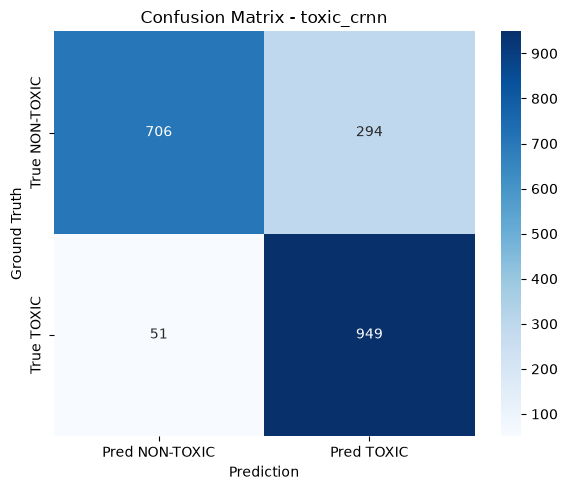

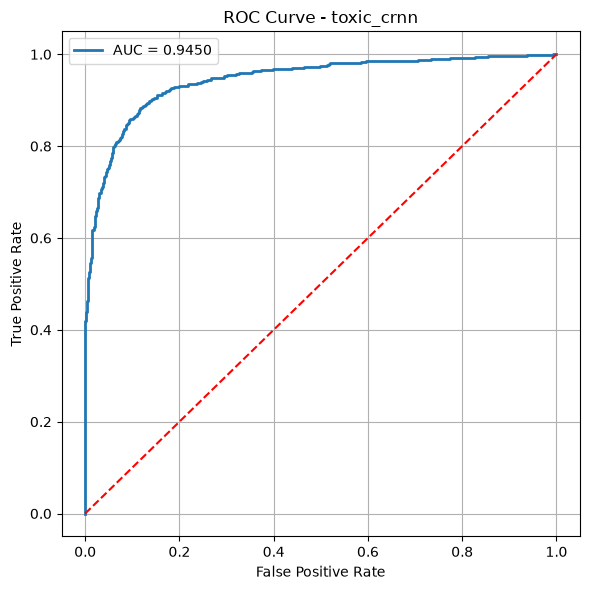

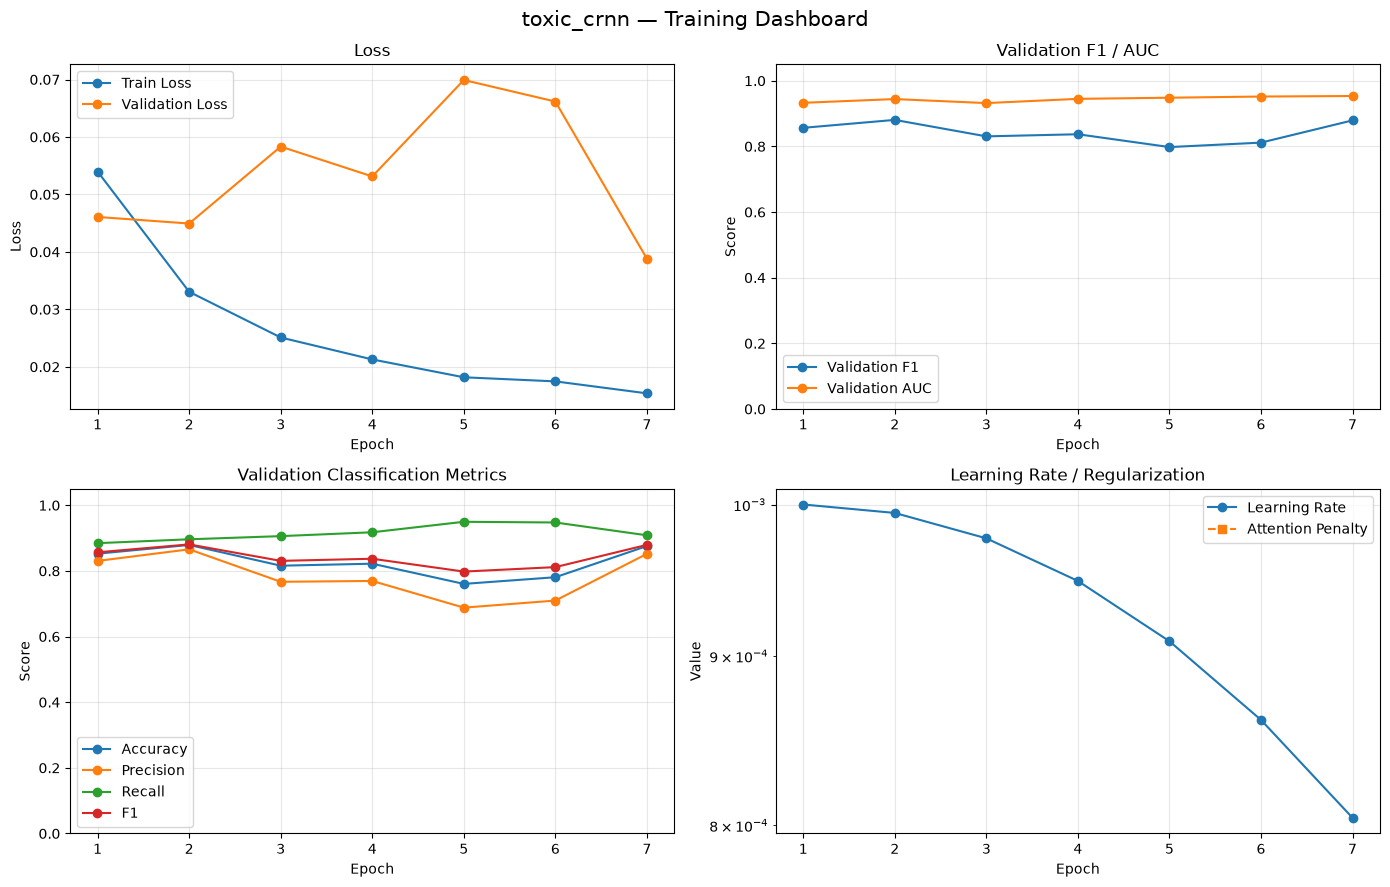

[PLOT] Saved: benchmark_outputs\plots\toxic_crnn_training_dashboard.png

[DONE] toxic_crnn
Test F1: 0.8462
Test AUC: 0.9450

[2/6] self_attentive_cnn

START MODEL: self_attentive_cnn

BALANCED TRAIN SAMPLER

Original toxicity distribution:
toxicity
0    8968
1    8946
Name: count, dtype: int64

Duration quartile boundaries:
0.00     0.682438
0.25     4.742312
0.50     6.744000
0.75     9.052500
1.00    19.232688
Name: duration, dtype: float64

Toxicity × Duration groups:
balance_group
0_Q1    3149
0_Q2    2210
0_Q3    1677
0_Q4    1932
1_Q1    1332
1_Q2    2283
1_Q3    2787
1_Q4    2544
Name: count, dtype: int64

Sampling weights:
balance_group
0_Q1    0.000318
0_Q2    0.000452
0_Q3    0.000596
0_Q4    0.000518
1_Q1    0.000751
1_Q2    0.000438
1_Q3    0.000359
1_Q4    0.000393
Name: count, dtype: float64

Sampler:
  Number of samples : 17914
  Number of groups  : 8
  Strategy           : toxicity x duration quartile


a:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\envLab\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Training model: self_attentive_cnn
Device: cuda
Learning rate: 0.001
Weight decay: 0.01
Attention entropy weight: 0.001
Checkpoint: benchmark_outputs\checkpoints\best_self_attentive_cnn.pth



Valid: 100%|██████████| 150/150 [00:10<00:00, 13.78it/s]


Epoch 01/20 | 1.7m | LR 1.00e-03 | Train 0.0636 | Valid 0.0499 | F1 0.8158 | AUC 0.9089 | AttnReg 0.28549
  Saved best checkpoint: benchmark_outputs\checkpoints\best_self_attentive_cnn.pth


...

Epoch 19/20 | 1.3m | LR 7.32e-05 | Train 0.0263 | Valid 0.0438 | F1 0.8715 | AUC 0.9316 | AttnReg 0.02706
  Saved best checkpoint: benchmark_outputs\checkpoints\best_self_attentive_cnn.pth


Valid: 100%|██████████| 150/150 [00:08<00:00, 17.68it/s]
C:\Users\ASUS TUF A17\AppData\Local\Temp\ipykernel_6132\1212830383.py:1232: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental featu

Epoch 20/20 | 1.4m | LR 5.58e-05 | Train 0.0259 | Valid 0.0427 | F1 0.8755 | AUC 0.9278 | AttnReg 0.02707
  Saved best checkpoint: benchmark_outputs\checkpoints\best_self_attentive_cnn.pth


Test: 100%|██████████| 63/63 [00:03<00:00, 17.80it/s]



TEST RESULTS - self_attentive_cnn
Accuracy : 0.8085
Precision: 0.7690
Recall   : 0.8820
F1-score : 0.8216
AUC-ROC  : 0.9118

Classification Report:

               precision    recall  f1-score   support

NON-TOXIC (0)       0.86      0.73      0.79      1000
    TOXIC (1)       0.77      0.88      0.82      1000

     accuracy                           0.81      2000
    macro avg       0.82      0.81      0.81      2000
 weighted avg       0.82      0.81      0.81      2000



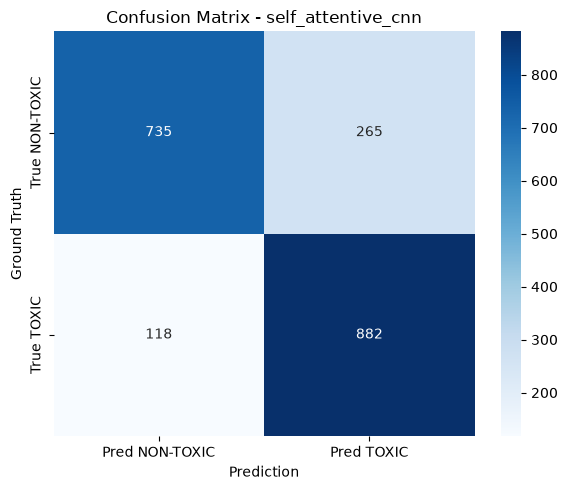

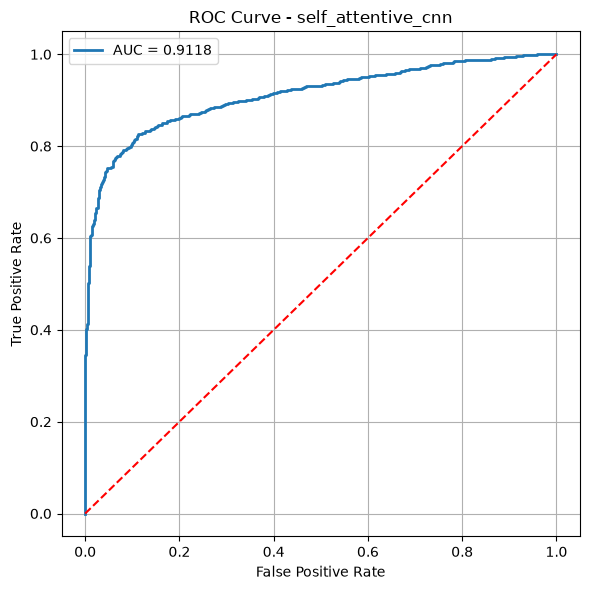

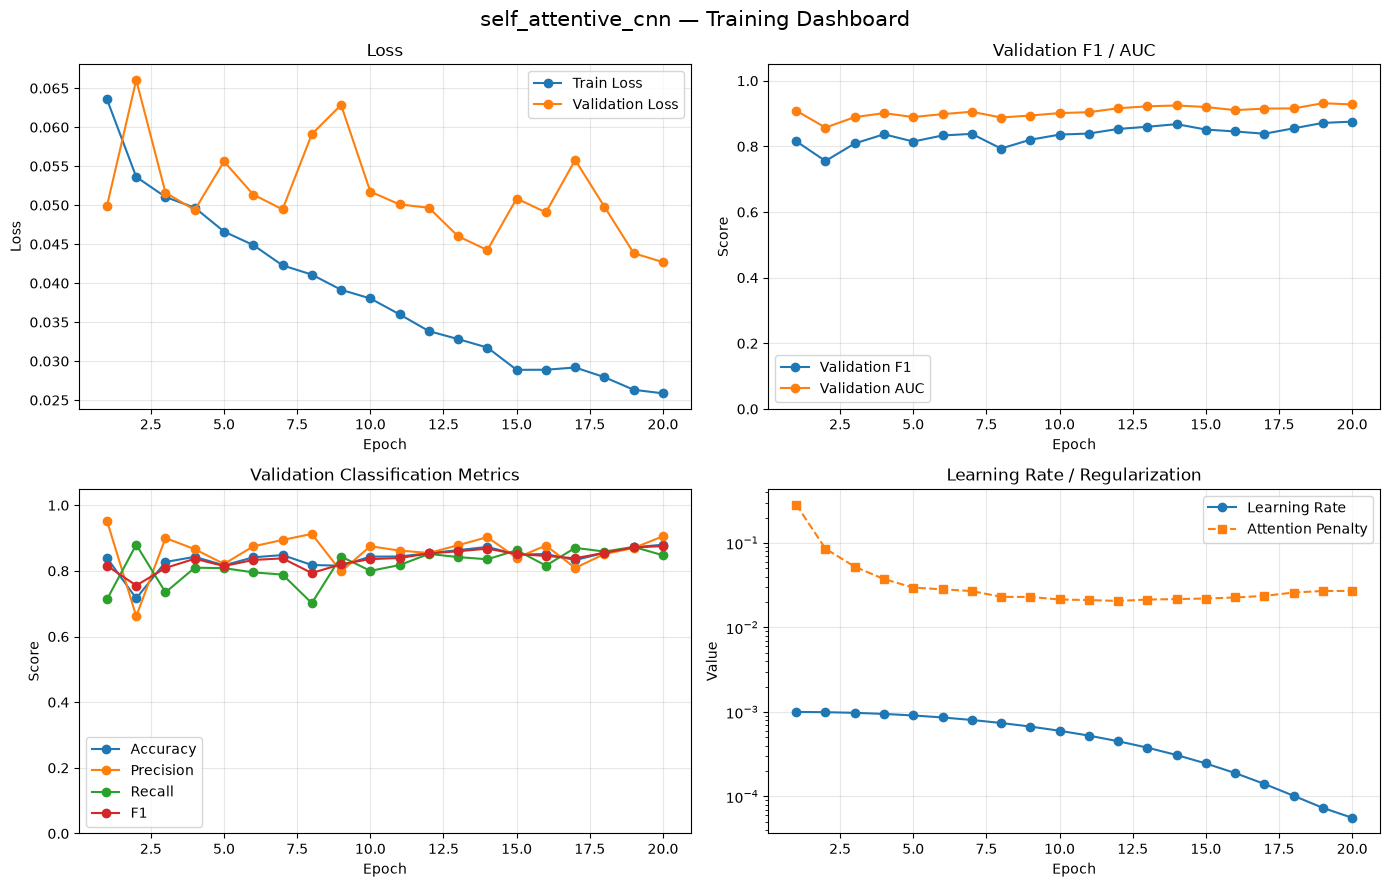

[PLOT] Saved: benchmark_outputs\plots\self_attentive_cnn_training_dashboard.png

[DONE] self_attentive_cnn
Test F1: 0.8216
Test AUC: 0.9118

[3/6] ssl_wavlm_classifier

START MODEL: ssl_wavlm_classifier


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /microsoft/wavlm-base-plus/resolve/main/preprocessor_config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 511f3734-250e-40ef-8883-7126723ab0a2)')' thrown while requesting HEAD https://huggingface.co/microsoft/wavlm-base-plus/resolve/main/preprocessor_config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /microsoft/wavlm-base-plus/resolve/main/preprocessor_config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: b04e1acc-e318-415f-a383-358a35dfbdf3)')' thrown while requesting HEAD https://huggingface.co/microsoft/wavlm-base-plus/resolv

[ssl_wavlm_classifier] epoch=01 valF1=0.9206 thr=0.535


train:   0%|          | 0/8957 [00:00<?, ?it/s]a:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\envLab\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
valid:   0%|          | 0/2390 [00:00<?, ?it/s]a:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\envLab\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
valid: 100%|██████████| 2390/2390 [02:24<00:00, 16.58it/s]


[ssl_wavlm_classifier] epoch=02 valF1=0.9353 thr=0.060


...

train:   0%|          | 0/8957 [00:00<?, ?it/s]a:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\envLab\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
valid:   0%|          | 0/2390 [00:00<?, ?it/s]a:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\envLab\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
valid: 100%|██████████| 2390/2390 [02:25<00:00, 16.46it/s]


[ssl_wavlm_classifier] epoch=19 valF1=0.9420 thr=1.000


train:   0%|          | 0/8957 [00:00<?, ?it/s]a:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\envLab\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
valid:   0%|          | 0/2390 [00:00<?, ?it/s]a:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\envLab\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
valid: 100%|██████████| 2390/2390 [02:24<00:00, 16.49it/s]


[ssl_wavlm_classifier] epoch=20 valF1=0.9421 thr=1.000


C:\Users\ASUS TUF A17\AppData\Local\Temp\ipykernel_6132\912638849.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_path, map_location=device)
val

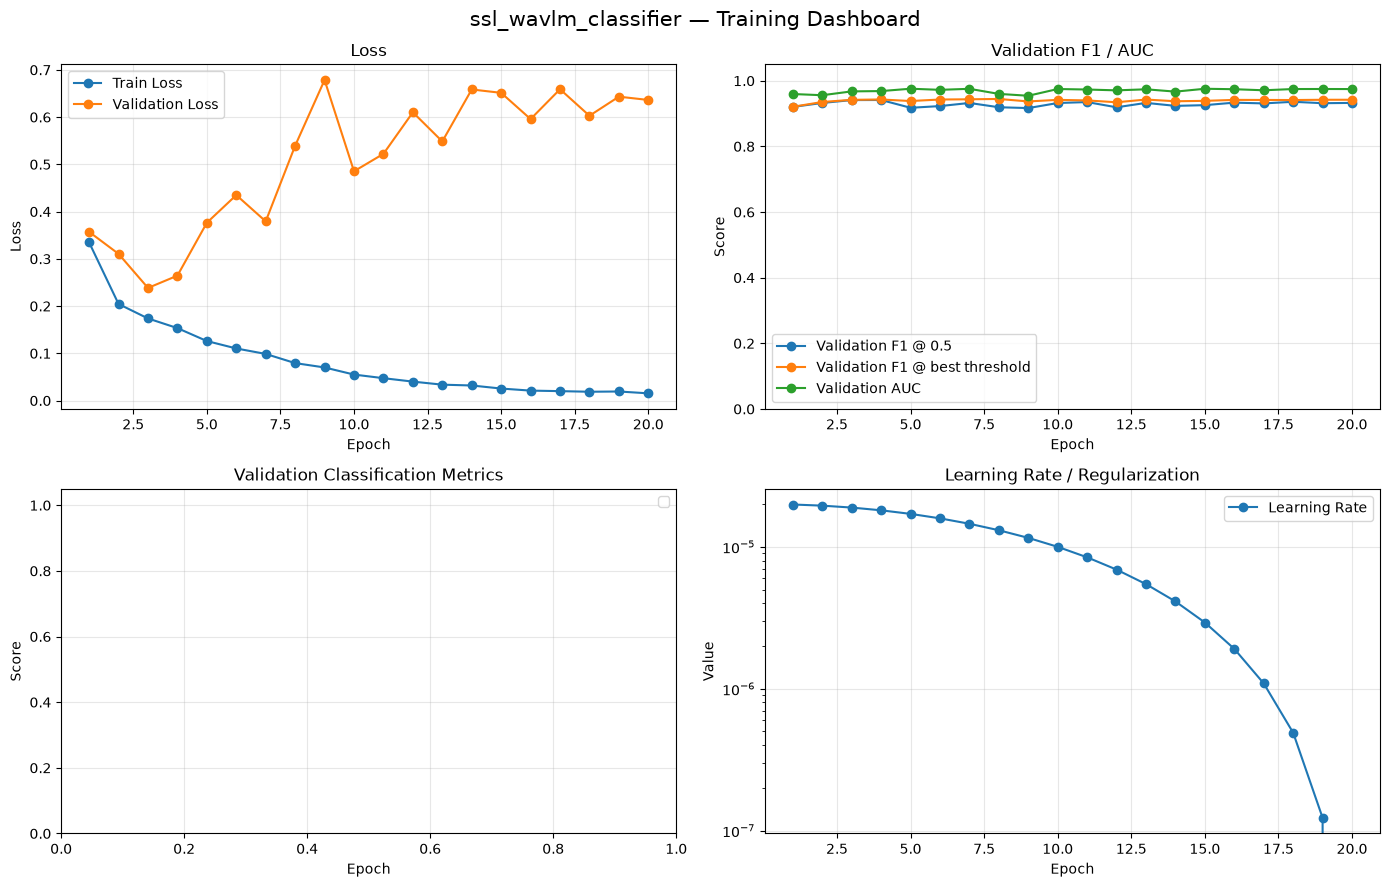

[PLOT] Saved: benchmark_outputs\plots\ssl_wavlm_classifier_training_dashboard.png


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /microsoft/wavlm-base-plus/resolve/main/preprocessor_config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 510346b1-1e7e-4d23-8f1f-e4ca7d9784a4)')' thrown while requesting HEAD https://huggingface.co/microsoft/wavlm-base-plus/resolve/main/preprocessor_config.json
Retrying in 1s [Retry 1/5].



[DONE] ssl_wavlm_classifier
Test F1: 0.8456
Test AUC: 0.7416

[4/6] ssl_wavlm_attention

START MODEL: ssl_wavlm_attention


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /microsoft/wavlm-base-plus/resolve/main/preprocessor_config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 1f440652-9799-43c7-8c12-bce06f9ebde9)')' thrown while requesting HEAD https://huggingface.co/microsoft/wavlm-base-plus/resolve/main/preprocessor_config.json
Retrying in 2s [Retry 2/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /microsoft/wavlm-base-plus/resolve/main/preprocessor_config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: d4f27bc5-d045-4a7e-bf25-f7baa2cd8286)')' thrown while requesting HEAD https://huggingface.co/microsoft/wavlm-base-plus/resolv

KeyboardInterrupt: 

In [39]:
# ============================================================
# 7.14 UNIFIED MULTI-MODEL BENCHMARK RUNNER — 5 ACTIVE / 11 AVAILABLE
# ============================================================
#
# This is the ONLY training runner for the scientific benchmark.
#
# Main benchmark / ablation set:
#   1. toxic_crnn
#   2. self_attentive_cnn
#   3. ssl_wavlm_classifier
#   4. ssl_wavlm_attention
#   5. ssl_wavlm_multiscale
#   6. ours_wavlm_multiscale_supcon
#
# The WavLM family is deliberately structured as a controlled
# ablation: simple classifier -> attention pooling -> multi-scale
# temporal modeling -> multi-scale + supervised contrastive learning.
#
# After EVERY model:
#   TRAIN -> VALIDATE -> TEST -> DASHBOARD -> LOG -> CLEANUP
#
# History is saved to:
#   benchmark_outputs/logs/<model>_history.json
#   benchmark_outputs/logs/<model>_history.csv
#   benchmark_outputs/logs/<model>_train.jsonl
#
# Plots are saved to:
#   benchmark_outputs/plots/<model>_training_dashboard.png
#   benchmark_outputs/plots/<model>_confusion_matrix.png
#   benchmark_outputs/plots/<model>_roc.png
#   benchmark_outputs/plots/<model>_pr.png
#
# Set RUN_UNIFIED_MULTI_MODEL = False to skip training.
# ============================================================

import gc
from pathlib import Path
from datetime import datetime

RUN_UNIFIED_MULTI_MODEL = True

EXPERIMENT_EPOCHS = 20

MEL_BATCH_SIZE = 32
RAW_SSL_BATCH_SIZE = 2

SKIP_FAILED_MODELS = True

# Set True if a complete history + metrics file already exists.
# In that case the model is NOT retrained.
REUSE_COMPLETED_MODELS = True

# ============================================================
# MODEL SELECTION
# ------------------------------------------------------------
# All 11 models remain defined below and can be re-enabled at
# any time. Only these 5 are active for the main benchmark:
#
# 1. toxic_crnn
#    -> original/simple acoustic baseline
# 2. self_attentive_cnn
#    -> CNN + temporal self-attention acoustic baseline
# 3. toxcl_audio
#    -> toxicity-specific ToXCL-inspired architecture
# 4. ssl_wavlm
#    -> strong modern self-supervised speech backbone
# 5. ours_wavlm_multiscale_supcon
#    -> proposed model / main research contribution
#
# The remaining 6 are DISABLED, not deleted.
# To re-enable one, simply add its model id to this list.
# ============================================================

UNIFIED_MODELS_TO_RUN = [
    "toxic_crnn",
    "self_attentive_cnn",
    "ssl_wavlm_classifier",
    "ssl_wavlm_attention",
    "ssl_wavlm_multiscale",
    "ours_wavlm_multiscale_supcon",
]

DISABLED_MODELS = [
    "toxcl_audio",
    "lightweight_wav2vec_transformer",
    "mutox_style",
    "cnn_logmel_delta_delta",
    "cnn_multires_logmel",
    "cnn_residual_logmel",
    "ssl_data2vec",
]

SSL_RUN_CONFIG = {
    "ssl_wavlm_classifier": {
        "hf_id": "microsoft/wavlm-base-plus",
        "architecture": "classifier",
        "proposed": False,
    },
    "ssl_wavlm_attention": {
        "hf_id": "microsoft/wavlm-base-plus",
        "architecture": "attention",
        "proposed": False,
    },
    "ssl_wavlm_multiscale": {
        "hf_id": "microsoft/wavlm-base-plus",
        "architecture": "multiscale",
        "proposed": False,
    },
    "ours_wavlm_multiscale_supcon": {
        "hf_id": "microsoft/wavlm-base-plus",
        "architecture": "multiscale_supcon",
        "proposed": True,
    },
}

MODEL_FAMILY_MAP = {
    "toxic_crnn": "CNN",
    "self_attentive_cnn": "CNN",
    "toxcl_audio": "CNN/Transformer",
    "lightweight_wav2vec_transformer": "SSL Audio",
    "mutox_style": "SSL Audio",
    "cnn_logmel_delta_delta": "CNN",
    "cnn_multires_logmel": "CNN",
    "cnn_residual_logmel": "CNN",
    "ssl_wavlm": "SSL Audio",
    "ssl_wavlm_classifier": "SSL Audio",
    "ssl_wavlm_attention": "SSL Audio",
    "ssl_wavlm_multiscale": "SSL Audio",
    "ssl_data2vec": "SSL Audio",
    "ours_wavlm_multiscale_supcon": "Proposed",
}

BENCHMARK_ID_MAP = {
    "toxic_crnn": "cnn_toxic_crnn",
    "self_attentive_cnn": "cnn_self_attentive",
    "toxcl_audio": "cnn_toxcl_audio",
    "lightweight_wav2vec_transformer": "ssl_wav2vec2_transformer",
    "mutox_style": "ssl_mutox_style",
    "cnn_logmel_delta_delta": "cnn_logmel_delta_delta",
    "cnn_multires_logmel": "cnn_multires_logmel",
    "cnn_residual_logmel": "cnn_residual_logmel",
    "ssl_wavlm": "ssl_wavlm",
    "ssl_wavlm_classifier": "ssl_wavlm_classifier",
    "ssl_wavlm_attention": "ssl_wavlm_attention",
    "ssl_wavlm_multiscale": "ssl_wavlm_multiscale",
    "ssl_data2vec": "ssl_data2vec",
    "ours_wavlm_multiscale_supcon": "ours_wavlm_multiscale_supcon",
}


def _json_safe(obj):
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {str(k): _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(x) for x in obj]
    return obj


def save_training_history(model_name, history, config_dict=None):
    """
    Persist history in JSON + CSV + JSONL.
    This makes it possible to redraw plots without retraining.
    """
    history_dir = DIRS["logs"]
    history_dir.mkdir(parents=True, exist_ok=True)

    payload = {
        "model": model_name,
        "saved_at": datetime.now().isoformat(),
        "config": _json_safe(config_dict or {}),
        "history": _json_safe(history),
    }

    json_path = history_dir / f"{model_name}_history.json"
    csv_path = history_dir / f"{model_name}_history.csv"
    jsonl_path = history_dir / f"{model_name}_train.jsonl"

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

    if isinstance(history, dict):
        pd.DataFrame(history).to_csv(
            csv_path,
            index=False,
        )

        with open(jsonl_path, "w", encoding="utf-8") as f:
            n = max(
                [len(v) for v in history.values() if isinstance(v, list)]
                or [0]
            )
            for i in range(n):
                row = {"epoch": i + 1}
                for key, values in history.items():
                    if isinstance(values, list) and i < len(values):
                        row[key] = _json_safe(values[i])
                f.write(
                    json.dumps(
                        row,
                        ensure_ascii=False,
                    )
                    + "\n"
                )

    return {
        "json": str(json_path),
        "csv": str(csv_path),
        "jsonl": str(jsonl_path),
    }


def save_training_dashboard(
    model_name,
    history,
    save_dir=None,
):
    """
    One combined 2x2 training dashboard per model.

    Panels:
      A. Train / Validation loss
      B. Validation F1 / AUC
      C. Validation Accuracy / Precision / Recall
      D. Learning rate / Attention regularization
    """
    save_dir = Path(
        save_dir or DIRS["plots"]
    )
    save_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # Normalize both history formats:
    # dict-of-lists from train_model
    # list-of-dicts from train_ssl_benchmark_model
    if isinstance(history, list):
        h = pd.DataFrame(history)
    else:
        h = pd.DataFrame(history)

    if h.empty:
        print(f"[PLOT] No history for {model_name}")
        return None

    if "epoch" not in h.columns:
        h.insert(
            0,
            "epoch",
            np.arange(1, len(h) + 1),
        )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 9),
    )

    # --------------------------------------------------------
    # A. Loss
    # --------------------------------------------------------
    ax = axes[0, 0]

    if "train_loss" in h.columns:
        ax.plot(
            h["epoch"],
            h["train_loss"],
            marker="o",
            label="Train Loss",
        )

    if "valid_loss" in h.columns:
        ax.plot(
            h["epoch"],
            h["valid_loss"],
            marker="o",
            label="Validation Loss",
        )

    ax.set_title("Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    ax.legend()

    # --------------------------------------------------------
    # B. F1 / AUC
    # --------------------------------------------------------
    ax = axes[0, 1]

    if "valid_f1" in h.columns:
        ax.plot(
            h["epoch"],
            h["valid_f1"],
            marker="o",
            label="Validation F1",
        )

    if "valid_f1_at_05" in h.columns:
        ax.plot(
            h["epoch"],
            h["valid_f1_at_05"],
            marker="o",
            label="Validation F1 @ 0.5",
        )

    if "valid_f1_best_threshold" in h.columns:
        ax.plot(
            h["epoch"],
            h["valid_f1_best_threshold"],
            marker="o",
            label="Validation F1 @ best threshold",
        )

    if "valid_auc" in h.columns:
        ax.plot(
            h["epoch"],
            h["valid_auc"],
            marker="o",
            label="Validation AUC",
        )

    ax.set_title("Validation F1 / AUC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend()

    # --------------------------------------------------------
    # C. Classification metrics
    # --------------------------------------------------------
    ax = axes[1, 0]

    for key, label in [
        ("valid_accuracy", "Accuracy"),
        ("valid_precision", "Precision"),
        ("valid_recall", "Recall"),
        ("valid_f1", "F1"),
    ]:
        if key in h.columns:
            ax.plot(
                h["epoch"],
                h[key],
                marker="o",
                label=label,
            )

    ax.set_title("Validation Classification Metrics")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend()

    # --------------------------------------------------------
    # D. LR / regularization
    # --------------------------------------------------------
    ax = axes[1, 1]

    if "lr" in h.columns:
        ax.plot(
            h["epoch"],
            h["lr"],
            marker="o",
            label="Learning Rate",
        )
        ax.set_yscale("log")

    if "attention_penalty" in h.columns:
        ax.plot(
            h["epoch"],
            h["attention_penalty"],
            marker="s",
            linestyle="--",
            label="Attention Penalty",
        )

    ax.set_title("Learning Rate / Regularization")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)
    ax.legend()

    fig.suptitle(
        f"{model_name} — Training Dashboard",
        fontsize=15,
    )

    fig.tight_layout()

    path = (
        save_dir
        / f"{model_name}_training_dashboard.png"
    )

    fig.savefig(
        path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(f"[PLOT] Saved: {path}")

    return str(path)


def save_model_result_json(
    model_name,
    result_row,
):
    path = (
        DIRS["logs"]
        / f"{model_name}_metrics.json"
    )

    with open(
        path,
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            _json_safe(result_row),
            f,
            ensure_ascii=False,
            indent=2,
        )

    return str(path)


def cleanup_after_model(
    model=None,
    optimizer=None,
    loader=None,
):
    """
    Explicitly release Python references and CUDA cache.
    """
    for obj_name in ["model", "optimizer", "loader"]:
        obj = locals().get(obj_name)
        if obj is not None:
            del obj

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

        allocated = (
            torch.cuda.memory_allocated()
            / (1024 ** 3)
        )
        reserved = (
            torch.cuda.memory_reserved()
            / (1024 ** 3)
        )

        print(
            f"[GPU CLEANUP] "
            f"allocated={allocated:.2f} GB | "
            f"reserved={reserved:.2f} GB"
        )


def _normalize_ssl_history(history):
    """
    Convert SSL list-of-dicts history to a dict-of-lists
    for persistence/replotting.
    """
    if not history:
        return {}

    if isinstance(history, dict):
        return history

    keys = sorted(
        {
            key
            for row in history
            for key in row.keys()
        }
    )

    return {
        key: [
            row.get(key, np.nan)
            for row in history
        ]
        for key in keys
    }


def run_one_unified_model(model_name):
    """
    Train/test ONE model and return one normalized result row.
    """
    print("\n" + "=" * 110)
    print(f"START MODEL: {model_name}")
    print("=" * 110)

    start_total = time.time()

    family = MODEL_FAMILY_MAP[model_name]
    benchmark_id = BENCHMARK_ID_MAP[model_name]

    # --------------------------------------------------------
    # Existing + new CNN models
    # --------------------------------------------------------
    if model_name in MEL_MODEL_NAMES or model_name in RAW_MODEL_NAMES:

        cfg = TrainConfig(
            model_name=model_name,
            batch_size=(
                MEL_BATCH_SIZE
                if model_name in MEL_MODEL_NAMES
                else RAW_SSL_BATCH_SIZE
            ),
            epochs=EXPERIMENT_EPOCHS,
            lr=1e-3,
            raw_lr=2e-5,
            weight_decay=1e-2,
            raw_max_seconds=8.0,
            wav2vec_name="facebook/wav2vec2-base",
            freeze_feature_encoder=True,
            freeze_first_n_encoder_layers=6,
            attention_entropy_weight=(
                AUGMENT_CONFIG["attention_entropy_weight"]
            ),
            early_stopping_patience=5,
            save_dir=str(DIRS["checkpoints"]),
        )

        history_path = (
            DIRS["logs"]
            / f"{model_name}_history.json"
        )
        metrics_path = (
            DIRS["logs"]
            / f"{model_name}_metrics.json"
        )
        checkpoint_path = (
            Path(cfg.save_dir)
            / f"best_{model_name}.pth"
        )

        # Resume/reuse only when BOTH artifacts exist.
        if (
            REUSE_COMPLETED_MODELS
            and history_path.exists()
            and metrics_path.exists()
            and checkpoint_path.exists()
        ):
            print(
                f"[REUSE] Existing completed artifacts found "
                f"for {model_name}."
            )

            with open(
                history_path,
                "r",
                encoding="utf-8",
            ) as f:
                payload = json.load(f)

            with open(
                metrics_path,
                "r",
                encoding="utf-8",
            ) as f:
                saved_row = json.load(f)

            history = payload["history"]

            save_training_dashboard(
                model_name,
                history,
            )

            return saved_row

        (
            model,
            history,
            best_path,
            selected_test_loader,
        ) = train_model(cfg)

        # ----------------------------------------------------
        # Test best checkpoint
        # ----------------------------------------------------
        test_metrics, best_model = evaluate_checkpoint(
            cfg,
            best_path,
            test_loader=selected_test_loader,
        )

        # ----------------------------------------------------
        # Save history + plots IMMEDIATELY
        # ----------------------------------------------------
        history_paths = save_training_history(
            model_name,
            history,
            cfg.__dict__,
        )

        dashboard_path = save_training_dashboard(
            model_name,
            history,
        )

        best_valid_f1 = (
            max(history["valid_f1"])
            if history.get("valid_f1")
            else np.nan
        )

        best_valid_auc = (
            max(history["valid_auc"])
            if history.get("valid_auc")
            else np.nan
        )

        row = {
            "benchmark_id": benchmark_id,
            "model": model_name,
            "family": family,
            "status": "ok",
            "params_total": count_parameters(model)[0],
            "params_trainable": count_parameters(model)[1],
            "best_valid_f1": best_valid_f1,
            "best_valid_auc": best_valid_auc,
            "threshold": test_metrics.get(
                "threshold",
                cfg.threshold,
            ),
            "test_accuracy": test_metrics.get(
                "accuracy",
                np.nan,
            ),
            "test_balanced_accuracy": test_metrics.get(
                "balanced_accuracy",
                np.nan,
            ),
            "test_precision": test_metrics.get(
                "precision",
                np.nan,
            ),
            "test_recall": test_metrics.get(
                "recall",
                np.nan,
            ),
            "test_f1": test_metrics.get(
                "f1",
                np.nan,
            ),
            "test_mcc": test_metrics.get(
                "mcc",
                np.nan,
            ),
            "test_auc": test_metrics.get(
                "auc",
                np.nan,
            ),
            "test_auprc": test_metrics.get(
                "auprc",
                np.nan,
            ),
            "checkpoint": str(best_path),
            "history_json": history_paths["json"],
            "history_csv": history_paths["csv"],
            "training_dashboard": dashboard_path,
            "training_seconds": time.time() - start_total,
        }

        save_model_result_json(
            model_name,
            row,
        )

        # ----------------------------------------------------
        # Cleanup
        # ----------------------------------------------------
        del best_model
        del model
        del selected_test_loader
        del cfg

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            try:
                torch.cuda.ipc_collect()
            except Exception:
                pass

        return row

    # --------------------------------------------------------
    # New SSL / Proposed models
    # --------------------------------------------------------
    if model_name in SSL_RUN_CONFIG:

        cfg_ssl = SSL_RUN_CONFIG[model_name]
        hf_id = cfg_ssl["hf_id"]
        proposed = cfg_ssl["proposed"]

        history_path = (
            DIRS["logs"]
            / f"{model_name}_history.json"
        )
        metrics_path = (
            DIRS["logs"]
            / f"{model_name}_metrics.json"
        )
        checkpoint_path = (
            DIRS["checkpoints"]
            / f"{model_name}_best.pt"
        )

        # Existing SSL runner uses DIRS["checkpoints"].
        if (
            REUSE_COMPLETED_MODELS
            and history_path.exists()
            and metrics_path.exists()
            and checkpoint_path.exists()
        ):
            print(
                f"[REUSE] Existing completed artifacts found "
                f"for {model_name}."
            )

            with open(
                history_path,
                "r",
                encoding="utf-8",
            ) as f:
                payload = json.load(f)

            with open(
                metrics_path,
                "r",
                encoding="utf-8",
            ) as f:
                saved_row = json.load(f)

            save_training_dashboard(
                model_name,
                payload["history"],
            )

            return saved_row

        architecture = cfg_ssl.get("architecture", "attention")

        if architecture == "classifier":
            model = WavLMClassifier(
                hf_id,
                freeze_layers=6,
            )
        elif architecture == "attention":
            model = HFSSLClassifier(
                hf_id,
                freeze_layers=6,
            )
        elif architecture == "multiscale":
            model = WavLMMultiScaleClassifier(
                hf_id,
                freeze_layers=6,
            )
        elif architecture == "multiscale_supcon":
            model = WavLMMultiScaleSupCon(
                hf_id,
                freeze_layers=6,
            )
        else:
            raise ValueError(
                f"Unknown WavLM architecture: {architecture}"
            )

        (
            model,
            history,
            test_metrics,
            ckpt,
            total,
            trainable,
        ) = train_ssl_benchmark_model(
            model_name,
            model,
            epochs=EXPERIMENT_EPOCHS,
            lr=2e-5,
            batch_size=RAW_SSL_BATCH_SIZE,
            proposed=proposed,
        )

        history = _normalize_ssl_history(history)

        history_paths = save_training_history(
            model_name,
            history,
            {
                "model_id": model_name,
                "hf_id": hf_id,
                "epochs": EXPERIMENT_EPOCHS,
                "lr": 2e-5,
                "batch_size": RAW_SSL_BATCH_SIZE,
                "proposed": proposed,
                "architecture": architecture,
            },
        )

        dashboard_path = save_training_dashboard(
            model_name,
            history,
        )

        best_valid_f1 = (
            max(
                history.get(
                    "valid_f1_best_threshold",
                    [np.nan],
                )
            )
        )

        row = {
            "benchmark_id": benchmark_id,
            "model": model_name,
            "family": family,
            "status": "ok",
            "params_total": total,
            "params_trainable": trainable,
            "best_valid_f1": best_valid_f1,
            "best_valid_auc": max(
                history.get(
                    "valid_auc",
                    [np.nan],
                )
            ),
            "threshold": test_metrics.get(
                "threshold",
                0.5,
            ),
            "test_accuracy": test_metrics.get(
                "accuracy",
                np.nan,
            ),
            "test_balanced_accuracy": test_metrics.get(
                "balanced_accuracy",
                np.nan,
            ),
            "test_precision": test_metrics.get(
                "precision",
                np.nan,
            ),
            "test_recall": test_metrics.get(
                "recall",
                np.nan,
            ),
            "test_f1": test_metrics.get(
                "f1",
                np.nan,
            ),
            "test_mcc": test_metrics.get(
                "mcc",
                np.nan,
            ),
            "test_auc": test_metrics.get(
                "auc",
                np.nan,
            ),
            "test_auprc": test_metrics.get(
                "auprc",
                np.nan,
            ),
            "checkpoint": str(ckpt),
            "history_json": history_paths["json"],
            "history_csv": history_paths["csv"],
            "training_dashboard": dashboard_path,
            "training_seconds": time.time() - start_total,
        }

        # Existing SSL prediction files -> test curves/CM
        pred_path = (
            DIRS["predictions"]
            / f"{model_name}_predictions.csv"
        )

        if pred_path.exists():
            pred_df = pd.read_csv(pred_path)

            save_model_plots(
                model_name,
                pred_df["y_true"].to_numpy(),
                pred_df["prob_toxic"].to_numpy(),
                row["threshold"],
                history,
            )

        save_model_result_json(
            model_name,
            row,
        )

        del model
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            try:
                torch.cuda.ipc_collect()
            except Exception:
                pass

        return row

    raise ValueError(
        f"Unknown unified model: {model_name}"
    )


unified_rows = []
failed_model_errors = {}

if RUN_UNIFIED_MULTI_MODEL:

    print("=" * 110)
    print("UNIFIED 11-MODEL SCIENTIFIC BENCHMARK")
    print("=" * 110)
    print("Models:")
    for i, name in enumerate(
        UNIFIED_MODELS_TO_RUN,
        start=1,
    ):
        print(f"  {i:02d}. {name}")

    print(
        f"\nEpochs: {EXPERIMENT_EPOCHS}"
    )
    print(
        f"Mel batch size: {MEL_BATCH_SIZE}"
    )
    print(
        f"Raw SSL batch size: {RAW_SSL_BATCH_SIZE}"
    )
    print(
        f"Reuse completed: {REUSE_COMPLETED_MODELS}"
    )

    for idx, model_name in enumerate(
        UNIFIED_MODELS_TO_RUN,
        start=1,
    ):
        try:
            print(
                f"\n[{idx}/{len(UNIFIED_MODELS_TO_RUN)}] "
                f"{model_name}"
            )

            row = run_one_unified_model(
                model_name
            )

            unified_rows.append(row)

            # Save cumulative results after EVERY model.
            cumulative_df = pd.DataFrame(
                unified_rows
            )

            cumulative_df.to_csv(
                DIRS["tables"]
                / "FULL_BENCHMARK_RESULTS_PROGRESS.csv",
                index=False,
            )

            print(
                f"\n[DONE] {model_name}"
            )
            print(
                f"Test F1: "
                f"{row.get('test_f1', np.nan):.4f}"
            )
            print(
                f"Test AUC: "
                f"{row.get('test_auc', np.nan):.4f}"
            )

        except Exception as exc:
            failed_model_errors[
                model_name
            ] = repr(exc)

            error_row = {
                "benchmark_id": BENCHMARK_ID_MAP.get(
                    model_name,
                    model_name,
                ),
                "model": model_name,
                "family": MODEL_FAMILY_MAP.get(
                    model_name,
                    "Unknown",
                ),
                "status": "failed",
                "error": repr(exc),
            }

            unified_rows.append(
                error_row
            )

            print(
                f"\nFAILED: {model_name}"
            )
            traceback.print_exc()

            if not SKIP_FAILED_MODELS:
                raise

            # Strong cleanup after failure.
            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                try:
                    torch.cuda.ipc_collect()
                except Exception:
                    pass

# This becomes the canonical table consumed by the final cells.
checkpoint_test_df = pd.DataFrame(
    unified_rows
)

if not checkpoint_test_df.empty:
    checkpoint_test_df = (
        checkpoint_test_df
        .sort_values(
            "test_f1",
            ascending=False,
            na_position="last",
        )
        .reset_index(drop=True)
    )

checkpoint_test_df.to_csv(
    DIRS["tables"] / "FULL_BENCHMARK_RESULTS_ALL.csv",
    index=False,
)

# Compatibility for the family-level cells below.
combined = checkpoint_test_df.copy()

print("\n" + "=" * 110)
print("UNIFIED BENCHMARK SUMMARY")
print("=" * 110)

display(
    checkpoint_test_df
)

if failed_model_errors:
    print("\nFAILED MODELS:")
    for name, error in failed_model_errors.items():
        print(f"- {name}: {error}")

print(
    "\nAll per-model histories are under:",
    DIRS["logs"],
)
print(
    "All per-model plots are under:",
    DIRS["plots"],
)


## 7.15 Optional CNN baseline export

The original notebook already trains `toxic_crnn`, `self_attentive_cnn` and `toxcl_audio`. Do **not** silently replace them with the new models. For the paper, keep the original architectures as fixed baselines and add the new SSL models as separate rows.

If `results_df` exists from the original experiment, the next cell normalizes its columns into the scientific benchmark table.


In [ ]:
# ============================================================
# 7.16 FINAL BENCHMARK RESULTS — ACTIVE MODELS
# ============================================================

if "checkpoint_test_df" not in globals():
    raise RuntimeError(
        "Run cell 7.14 UNIFIED MULTI-MODEL BENCHMARK first."
    )

if checkpoint_test_df.empty:
    raise RuntimeError(
        "checkpoint_test_df is empty. "
        "Check model training failures."
    )

final_benchmark_df = checkpoint_test_df.copy()

required_columns = [
    "benchmark_id",
    "model",
    "family",
    "status",
    "test_accuracy",
    "test_balanced_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_mcc",
    "test_auc",
    "test_auprc",
    "threshold",
    "checkpoint",
]

for col in required_columns:
    if col not in final_benchmark_df.columns:
        final_benchmark_df[col] = np.nan

final_benchmark_df = (
    final_benchmark_df[required_columns]
    .sort_values(
        "test_f1",
        ascending=False,
        na_position="last",
    )
    .reset_index(drop=True)
)

output_path = (
    DIRS["tables"]
    / "FULL_BENCHMARK_RESULTS_ALL.csv"
)

final_benchmark_df.to_csv(
    output_path,
    index=False,
)

print("=" * 90)
print(f"FINAL BENCHMARK RESULTS — {len(UNIFIED_MODELS_TO_RUN)} ACTIVE MODELS")
print("=" * 90)
print(f"Saved to: {output_path}")

display(final_benchmark_df)


FINAL BENCHMARK RESULTS — 5 ACTIVE MODELS
Saved to: benchmark_outputs\tables\FULL_BENCHMARK_RESULTS_ALL.csv


,benchmark_id,model,family,status,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_mcc,test_auc,test_auprc,threshold,checkpoint
0,ssl_wavlm,ssl_wavlm,SSL Audio,ok,0.8835,0.8835,0.850228,0.931,0.888783,0.770485,0.910279,0.864934,0.999998,benchmark_outputs\checkpoints\ssl_wavlm_best.pt
1,cnn_toxic_crnn,toxic_crnn,CNN,ok,0.8275,0.8275,0.763475,0.949,0.846188,0.675239,0.944964,0.952028,0.500000,benchmark_outputs\checkpoints\best_toxic_crnn.pth
2,ours_wavlm_multiscale_supcon,ours_wavlm_multiscale_supcon,Proposed,ok,0.8120,0.8120,0.742613,0.955,0.835521,0.651201,0.916330,0.877291,0.999992,benchmark_outputs\checkpoints\ours_wavlm_multi...
3,cnn_self_attentive,self_attentive_cnn,CNN,ok,0.8055,0.8055,0.801579,0.812,0.806756,0.611052,0.866846,0.896299,0.500000,benchmark_outputs\checkpoints\best_self_attent...
4,cnn_toxcl_audio,toxcl_audio,CNN/Transformer,ok,0.6035,0.6035,0.569980,0.843,0.680113,0.235813,0.736217,0.767248,0.500000,benchmark_outputs\checkpoints\best_toxcl_audio...


In [ ]:

# ============================================================
# 7.17 FAMILY-LEVEL COMPARISON PLOTS + PAPER TABLES
# ============================================================
if "combined" in globals() and not combined.empty:
    plot_df = combined.dropna(subset=["test_f1"]).copy()

    # Model ranking
    ranking = plot_df.sort_values("test_f1", ascending=False)
    ranking.to_csv(DIRS["tables"] / "model_ranking_by_test_f1.csv", index=False)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(ranking["benchmark_id"].astype(str), ranking["test_f1"])
    ax.set_ylim(0, 1)
    ax.set_ylabel("Test F1")
    ax.set_xlabel("Model")
    ax.set_title("Utterance-level Toxic Speech Classification — Test F1")
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    fig.savefig(DIRS["plots"] / "benchmark_test_f1_ranking.png", dpi=220)
    plt.close(fig)

    # Family means are descriptive only; do not use them as a statistical claim.
    family_table = (
        plot_df.groupby("family", dropna=False)
        .agg(
            models=("benchmark_id","count"),
            mean_f1=("test_f1","mean"),
            best_f1=("test_f1","max"),
            mean_auc=("test_auc","mean"),
            best_auc=("test_auc","max"),
        )
        .reset_index()
        .sort_values("best_f1", ascending=False)
    )
    family_table.to_csv(DIRS["tables"] / "family_summary.csv", index=False)

    fig, ax = plt.subplots(figsize=(8,5))
    ax.bar(family_table["family"].astype(str), family_table["best_f1"])
    ax.set_ylim(0,1)
    ax.set_ylabel("Best test F1")
    ax.set_title("Best model by benchmark family")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    fig.savefig(DIRS["plots"] / "family_best_f1.png", dpi=220)
    plt.close(fig)

    display(family_table)


,family,models,mean_f1,best_f1,mean_auc,best_auc
3,SSL Audio,1,0.888783,0.888783,0.910279,0.910279
0,CNN,2,0.826472,0.846188,0.905905,0.944964
2,Proposed,1,0.835521,0.835521,0.916330,0.916330
1,CNN/Transformer,1,0.680113,0.680113,0.736217,0.736217


In [ ]:

# ============================================================
# 7.18 REPRODUCIBILITY MANIFEST
# ============================================================
manifest = {
    "seed": BENCHMARK_SEED,
    "dataset_csv": str(FULL_CSV) if "FULL_CSV" in globals() else None,
    "split_column": "split",
    "label_column": "toxicity",
    "audio_column": "audio_full_path",
    "primary_metric": "test_f1",
    "secondary_metrics": ["balanced_accuracy","precision","recall","mcc","auc","auprc"],
    "threshold_selection": "validation F1; test is never used to choose threshold",
    "bootstrap": {"n": 1000, "ci": "95%"},
    "families": ["SSL Audio","CNN","CNN/Transformer","Proposed"],
    "benchmark_models_active": UNIFIED_MODELS_TO_RUN if "UNIFIED_MODELS_TO_RUN" in globals() else [],
    "benchmark_models_disabled": DISABLED_MODELS if "DISABLED_MODELS" in globals() else [],
    "benchmark_models_available": list(BENCHMARK_ID_MAP.keys()) if "BENCHMARK_ID_MAP" in globals() else [],
    "per_model_history": "benchmark_outputs/logs/<model>_history.json",
    "per_model_dashboard": "benchmark_outputs/plots/<model>_training_dashboard.png",
    "output_root": str(BENCHMARK_ROOT.resolve()),
}
save_json(manifest, DIRS["configs"] / "benchmark_manifest.json")
print("Saved:", DIRS["configs"] / "benchmark_manifest.json")
print("All benchmark artifacts are under:", BENCHMARK_ROOT.resolve())


Saved: benchmark_outputs\configs\benchmark_manifest.json
All benchmark artifacts are under: A:\A _ Working\Researching\B - AIoT Lab VN\VITOSA SpeechRun\train ben dual\benchmark_outputs



FINAL TEST REPORT — toxic_crnn
[REUSE PREDICTIONS] toxic_crnn

Threshold              : 0.5000000000
Accuracy               : 0.8275000000
Balanced Accuracy      : 0.8275000000

NON-TOXIC (0)
  Precision            : 0.9326287979
  Recall               : 0.7060000000
  F1-score             : 0.8036425726
  Support              : 1000

TOXIC (1)
  Precision            : 0.7634754626
  Recall               : 0.9490000000
  F1-score             : 0.8461881409
  Support              : 1000

MACRO AVG
  Precision            : 0.8480521302
  Recall               : 0.8275000000
  F1-score             : 0.8249153567

WEIGHTED AVG
  Precision            : 0.8480521302
  Recall               : 0.8275000000
  F1-score             : 0.8249153567

MCC                    : 0.6752394321
AUC-ROC                : 0.9449640000
AUPRC                  : 0.9520284768

Support TOTAL          : 2000

Confusion Matrix
                  Predicted
                  NON-TOXIC   TOXIC
True NON-TOXIC           70

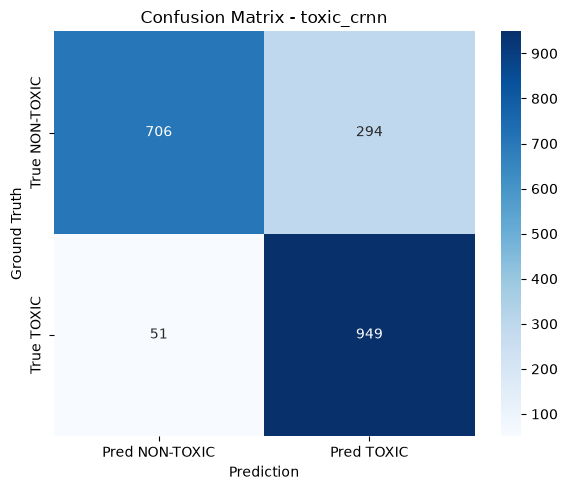

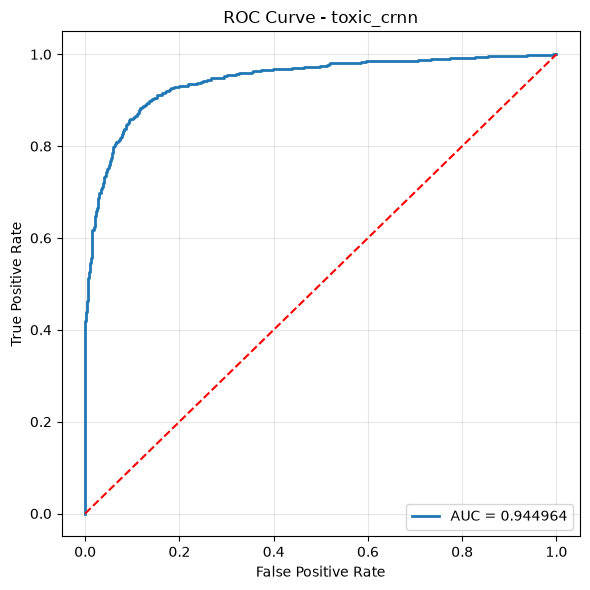

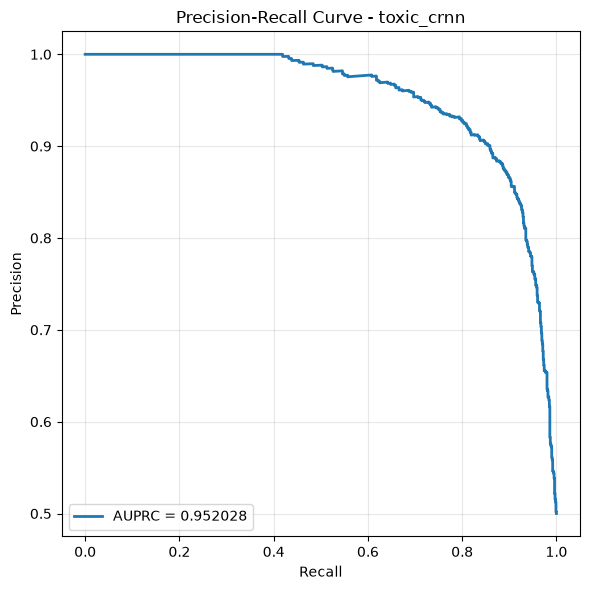


[DONE] toxic_crnn

FINAL TEST REPORT — self_attentive_cnn
[REUSE PREDICTIONS] self_attentive_cnn

Threshold              : 0.5000000000
Accuracy               : 0.8055000000
Balanced Accuracy      : 0.8055000000

NON-TOXIC (0)
  Precision            : 0.8095238095
  Recall               : 0.7990000000
  F1-score             : 0.8042274786
  Support              : 1000

TOXIC (1)
  Precision            : 0.8015794669
  Recall               : 0.8120000000
  F1-score             : 0.8067560854
  Support              : 1000

MACRO AVG
  Precision            : 0.8055516382
  Recall               : 0.8055000000
  F1-score             : 0.8054917820

WEIGHTED AVG
  Precision            : 0.8055516382
  Recall               : 0.8055000000
  F1-score             : 0.8054917820

MCC                    : 0.6110516360
AUC-ROC                : 0.8668460000
AUPRC                  : 0.8962992793

Support TOTAL          : 2000

Confusion Matrix
                  Predicted
                  NON-TOXIC 

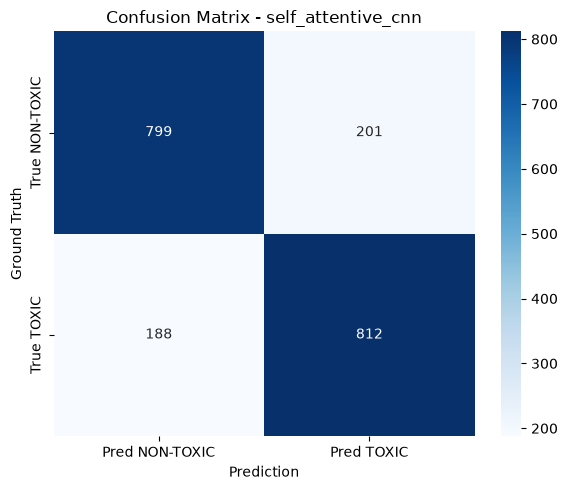

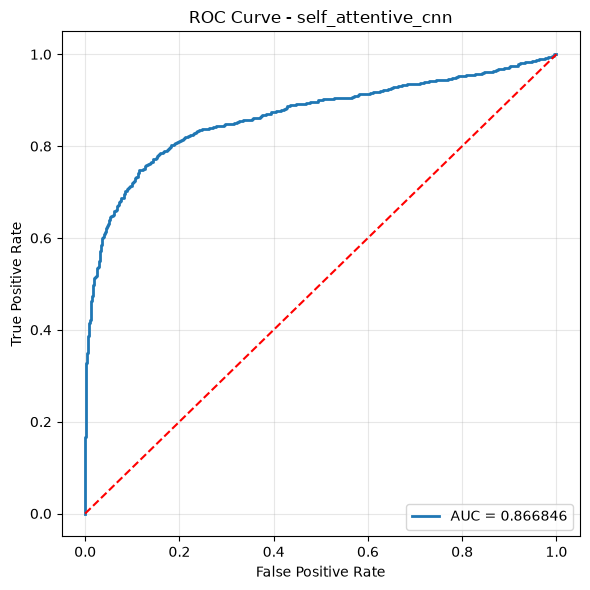

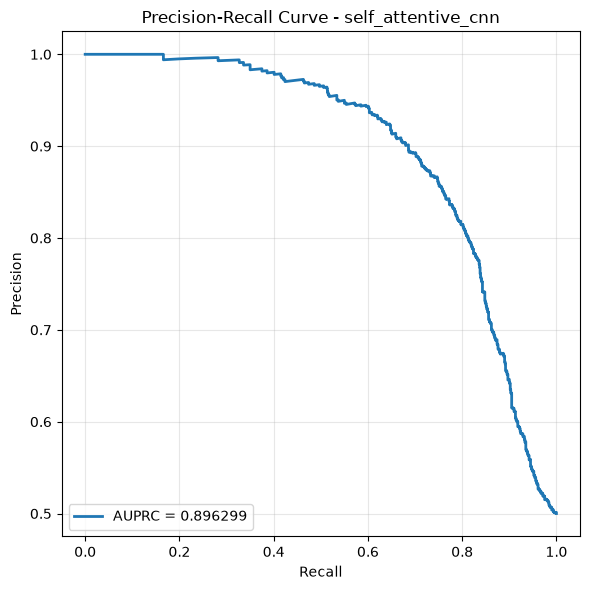


[DONE] self_attentive_cnn

FINAL TEST REPORT — toxcl_audio
[REUSE PREDICTIONS] toxcl_audio

Threshold              : 0.5000000000
Accuracy               : 0.6035000000
Balanced Accuracy      : 0.6035000000

NON-TOXIC (0)
  Precision            : 0.6986564299
  Recall               : 0.3640000000
  F1-score             : 0.4786324786
  Support              : 1000

TOXIC (1)
  Precision            : 0.5699797160
  Recall               : 0.8430000000
  F1-score             : 0.6801129488
  Support              : 1000

MACRO AVG
  Precision            : 0.6343180730
  Recall               : 0.6035000000
  F1-score             : 0.5793727137

WEIGHTED AVG
  Precision            : 0.6343180730
  Recall               : 0.6035000000
  F1-score             : 0.5793727137

MCC                    : 0.2358128118
AUC-ROC                : 0.7362165000
AUPRC                  : 0.7672476449

Support TOTAL          : 2000

Confusion Matrix
                  Predicted
                  NON-TOXIC   TOXI

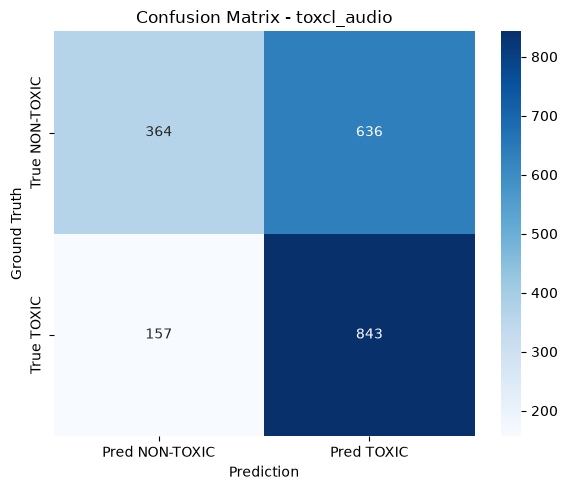

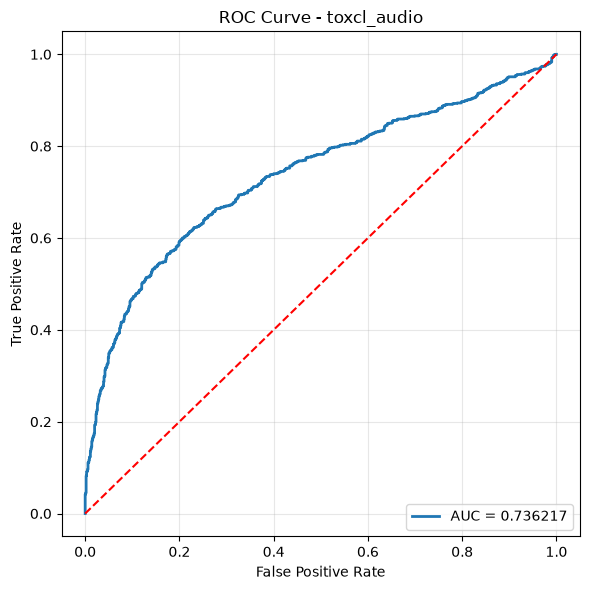

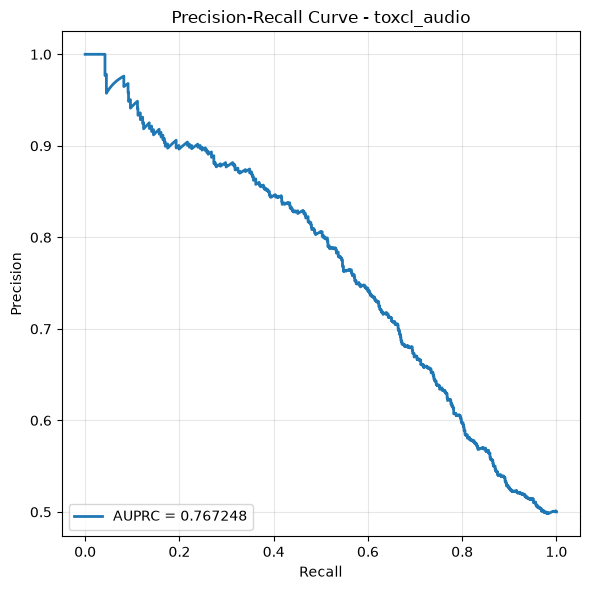


[DONE] toxcl_audio

FINAL TEST REPORT — ssl_wavlm
[REUSE PREDICTIONS] ssl_wavlm

Threshold              : 0.9999979734
Accuracy               : 0.8835000000
Balanced Accuracy      : 0.8835000000

NON-TOXIC (0)
  Precision            : 0.9237569061
  Recall               : 0.8360000000
  F1-score             : 0.8776902887
  Support              : 1000

TOXIC (1)
  Precision            : 0.8502283105
  Recall               : 0.9310000000
  F1-score             : 0.8887828162
  Support              : 1000

MACRO AVG
  Precision            : 0.8869926083
  Recall               : 0.8835000000
  F1-score             : 0.8832365525

WEIGHTED AVG
  Precision            : 0.8869926083
  Recall               : 0.8835000000
  F1-score             : 0.8832365525

MCC                    : 0.7704846923
AUC-ROC                : 0.9102790000
AUPRC                  : 0.8649343257

Support TOTAL          : 2000

Confusion Matrix
                  Predicted
                  NON-TOXIC   TOXIC
True NON-

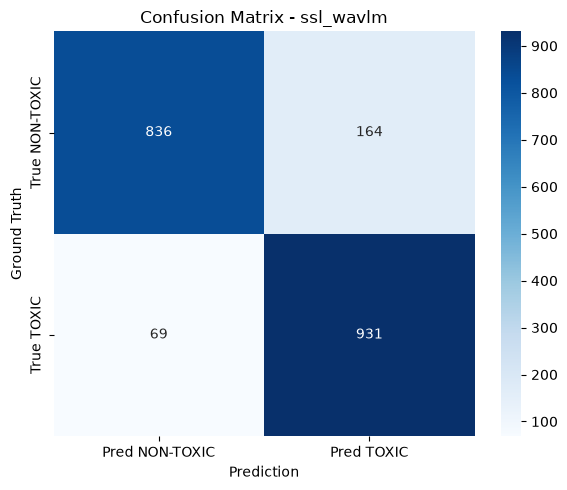

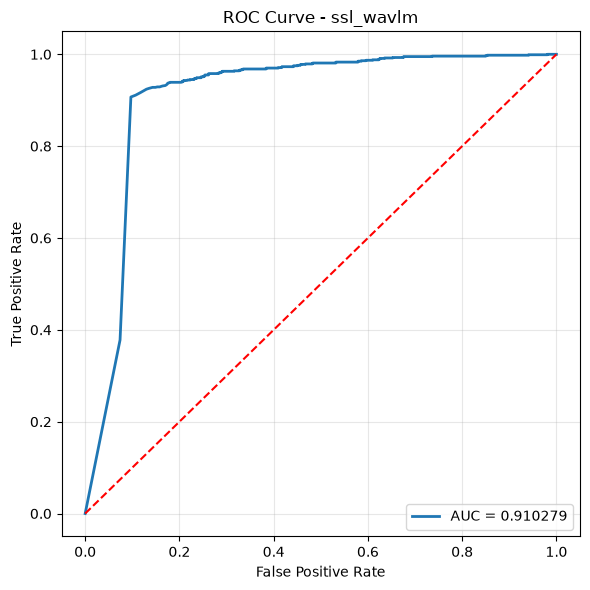

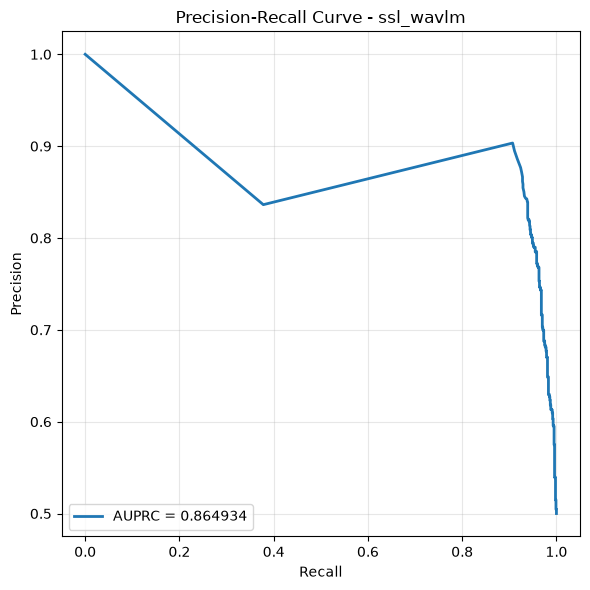


[DONE] ssl_wavlm

FINAL TEST REPORT — ours_wavlm_multiscale_supcon
[REUSE PREDICTIONS] ours_wavlm_multiscale_supcon

Threshold              : 0.9999915361
Accuracy               : 0.8120000000
Balanced Accuracy      : 0.8120000000

NON-TOXIC (0)
  Precision            : 0.9369747899
  Recall               : 0.6690000000
  F1-score             : 0.7806301050
  Support              : 1000

TOXIC (1)
  Precision            : 0.7426127527
  Recall               : 0.9550000000
  F1-score             : 0.8355205599
  Support              : 1000

MACRO AVG
  Precision            : 0.8397937713
  Recall               : 0.8120000000
  F1-score             : 0.8080753325

WEIGHTED AVG
  Precision            : 0.8397937713
  Recall               : 0.8120000000
  F1-score             : 0.8080753325

MCC                    : 0.6512009111
AUC-ROC                : 0.9163300000
AUPRC                  : 0.8772912910

Support TOTAL          : 2000

Confusion Matrix
                  Predicted
         

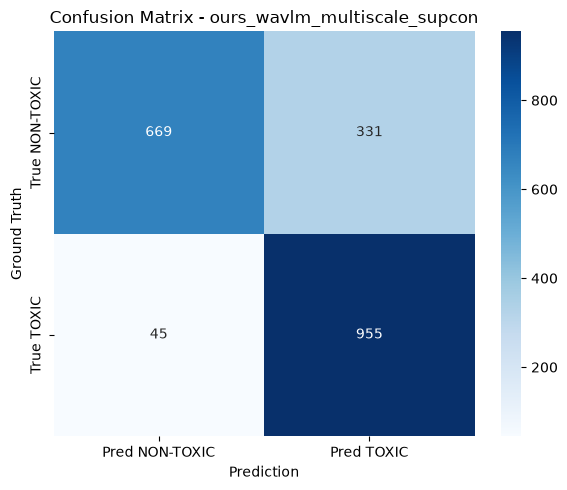

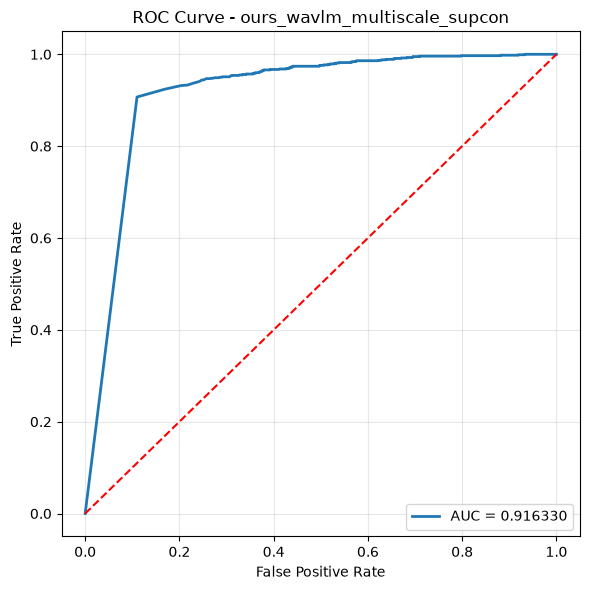

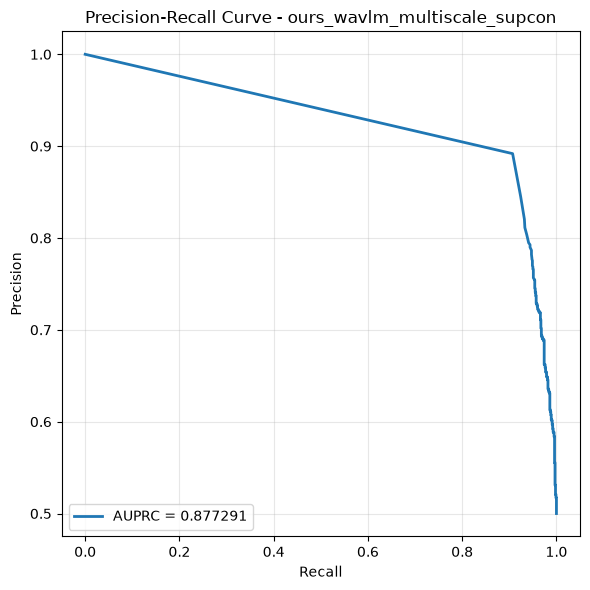


[DONE] ours_wavlm_multiscale_supcon

FINAL TEST RESULTS — ALL 5 ACTIVE MODELS


,benchmark_id,model,family,status,params_total,params_trainable,training_seconds,threshold,n_test,accuracy,...,report_toxic_f1,report_toxic_support,report_macro_precision,report_macro_recall,report_macro_f1,report_macro_support,report_weighted_precision,report_weighted_recall,report_weighted_f1,report_weighted_support
0,cnn_toxic_crnn,toxic_crnn,CNN,ok,1218498,1218498,503.726081,0.500000,2000,0.8275,...,0.846188,1000.0,0.848052,0.8275,0.824915,2000.0,0.848052,0.8275,0.824915,2000.0
1,cnn_self_attentive,self_attentive_cnn,CNN,ok,833762,833762,655.391790,0.500000,2000,0.8055,...,0.806756,1000.0,0.805552,0.8055,0.805492,2000.0,0.805552,0.8055,0.805492,2000.0
2,cnn_toxcl_audio,toxcl_audio,CNN/Transformer,ok,1896778,1896778,536.162408,0.500000,2000,0.6035,...,0.680113,1000.0,0.634318,0.6035,0.579373,2000.0,0.634318,0.6035,0.579373,2000.0
3,ssl_wavlm,ssl_wavlm,SSL Audio,ok,94613106,47878394,29605.192230,0.999998,2000,0.8835,...,0.888783,1000.0,0.886993,0.8835,0.883237,2000.0,0.886993,0.8835,0.883237,2000.0
4,ours_wavlm_multiscale_supcon,ours_wavlm_multiscale_supcon,Proposed,ok,95141363,48406651,30572.164888,0.999992,2000,0.8120,...,0.835521,1000.0,0.839794,0.8120,0.808075,2000.0,0.839794,0.8120,0.808075,2000.0



[SAVED] COMPLETE CSV:
benchmark_outputs\tables\FINAL_TEST_RESULTS_ALL_METRICS.csv

[SAVED] TRANSPOSED CSV:
benchmark_outputs\tables\FINAL_TEST_RESULTS_ALL_METRICS_TRANSPOSED.csv

7.15 FINAL TEST REPORT COMPLETED


In [ ]:
# ============================================================
# 7.15 FINAL TEST REPORT — ALL 5 ACTIVE MODELS
# ------------------------------------------------------------
# Purpose:
#   - DO NOT retrain
#   - Reuse existing *_predictions.csv when available
#   - If a CNN prediction CSV is missing, run INFERENCE ONLY
#     from its saved best checkpoint and save the predictions.
#   - Generate complete test evaluation for ALL 5 active models.
#
# Models:
#   1. toxic_crnn
#   2. self_attentive_cnn
#   3. toxcl_audio
#   4. ssl_wavlm
#   5. ours_wavlm_multiscale_supcon
#
# Outputs:
#   - Accuracy
#   - Balanced Accuracy
#   - NON-TOXIC Precision / Recall / F1 / Support
#   - TOXIC Precision / Recall / F1 / Support
#   - Macro Precision / Recall / F1 / Support
#   - Weighted Precision / Recall / F1 / Support
#   - AUC-ROC
#   - AUPRC
#   - MCC
#   - Threshold
#   - TN / FP / FN / TP
#   - Classification Report
#   - Confusion Matrix
#   - ROC Curve
#   - Precision-Recall Curve
#   - Complete CSV with ALL numerical values
#
# IMPORTANT:
#   - This cell NEVER calls train_model().
#   - For CNN models, inference is performed directly from the
#     saved best checkpoint only when predictions.csv is missing.
#   - For SSL models, existing predictions.csv is reused.
# ============================================================

from pathlib import Path
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)


# ============================================================
# ALL ACTIVE MODELS — BENCHMARK + WavLM ABLATION
# ============================================================

FINAL_REPORT_MODELS = [
    "toxic_crnn",
    "self_attentive_cnn",
    "ssl_wavlm_classifier",
    "ssl_wavlm_attention",
    "ssl_wavlm_multiscale",
    "ours_wavlm_multiscale_supcon",
]

CNN_REPORT_MODELS = {
    "toxic_crnn",
    "self_attentive_cnn",
    "toxcl_audio",
}

SSL_REPORT_MODELS = {
    "ssl_wavlm_classifier",
    "ssl_wavlm_attention",
    "ssl_wavlm_multiscale",
    "ours_wavlm_multiscale_supcon",
}

FINAL_REPORT_FAMILY = {
    "toxic_crnn": "CNN",
    "self_attentive_cnn": "CNN",
    "toxcl_audio": "CNN/Transformer",
    "ssl_wavlm_classifier": "SSL Audio",
    "ssl_wavlm_attention": "SSL Audio",
    "ssl_wavlm_multiscale": "SSL Audio",
    "ours_wavlm_multiscale_supcon": "Proposed",
}


# ============================================================
# DIRECTORIES
# ============================================================

FINAL_REPORT_PRED_DIR = Path(DIRS["predictions"])
FINAL_REPORT_METRIC_DIR = Path(DIRS["logs"])
FINAL_REPORT_PLOT_DIR = Path(DIRS["plots"])
FINAL_REPORT_TABLE_DIR = Path(DIRS["tables"])

for _dir in [
    FINAL_REPORT_PRED_DIR,
    FINAL_REPORT_METRIC_DIR,
    FINAL_REPORT_PLOT_DIR,
    FINAL_REPORT_TABLE_DIR,
]:
    _dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# LOAD SAVED METRICS
# ============================================================

def _load_saved_metrics(model_name):
    metrics_path = (
        FINAL_REPORT_METRIC_DIR
        / f"{model_name}_metrics.json"
    )

    if not metrics_path.exists():
        return {}

    try:
        with open(metrics_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as exc:
        print(
            f"[WARN] Cannot read metrics JSON for {model_name}: {exc}"
        )
        return {}


def _load_saved_threshold(model_name, default=0.5):
    metrics = _load_saved_metrics(model_name)

    try:
        return float(metrics.get("threshold", default))
    except Exception:
        return float(default)


# ============================================================
# BUILD THE SAME CNN CONFIG USED BY THE UNIFIED RUNNER
# ------------------------------------------------------------
# This is inference-only. No train_model() is called.
# ============================================================

def _build_cnn_config(model_name):
    return TrainConfig(
        model_name=model_name,
        batch_size=MEL_BATCH_SIZE,
        epochs=EXPERIMENT_EPOCHS,
        lr=1e-3,
        raw_lr=2e-5,
        weight_decay=1e-2,
        raw_max_seconds=8.0,
        wav2vec_name="facebook/wav2vec2-base",
        freeze_feature_encoder=True,
        freeze_first_n_encoder_layers=6,
        attention_entropy_weight=(
            AUGMENT_CONFIG["attention_entropy_weight"]
        ),
        early_stopping_patience=5,
        save_dir=str(DIRS["checkpoints"]),
    )


# ============================================================
# FIND CHECKPOINT
# ============================================================

def _find_checkpoint(model_name):
    saved_metrics = _load_saved_metrics(model_name)

    saved_checkpoint = saved_metrics.get("checkpoint")

    candidates = []

    if saved_checkpoint:
        candidates.append(Path(saved_checkpoint))

    candidates.extend([
        FINAL_REPORT_METRIC_DIR.parent
        / "checkpoints"
        / f"best_{model_name}.pth",
        Path(DIRS["checkpoints"])
        / f"best_{model_name}.pth",
    ])

    for candidate in candidates:
        try:
            candidate = candidate.resolve()
        except Exception:
            candidate = Path(candidate)

        if candidate.exists():
            return candidate

    return None


# ============================================================
# CNN INFERENCE FROM SAVED CHECKPOINT
# ============================================================

def _generate_cnn_predictions(model_name):
    """
    Run TEST inference only for a CNN model.

    IMPORTANT:
        - No training
        - No optimizer
        - No backward()
        - No train_model()

    Returns:
        y_true, prob_toxic, threshold
    """

    checkpoint_path = _find_checkpoint(model_name)

    if checkpoint_path is None:
        raise FileNotFoundError(
            f"No checkpoint found for {model_name}."
        )

    print(
        f"[INFERENCE ONLY] {model_name}"
    )
    print(
        f"[CHECKPOINT] {checkpoint_path}"
    )

    config = _build_cnn_config(model_name)

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )

    model = create_model(
        config
    ).to(device)

    state_dict = checkpoint.get(
        "model_state_dict",
        checkpoint,
    )

    model.load_state_dict(
        state_dict
    )

    model.eval()

    # Use the same dataset/dataloader factory as the benchmark.
    # This guarantees that test preprocessing is identical.
    _, _, test_loader = create_dataloaders_for_model(
        config
    )

    threshold = float(
        checkpoint.get(
            "threshold",
            _load_saved_threshold(
                model_name,
                config.threshold,
            ),
        )
    )

    all_targets = []
    all_probs = []

    with torch.no_grad():

        for batch in tqdm(
            test_loader,
            desc=f"Test inference — {model_name}",
        ):

            logits, labels, _ = forward_batch(
                model,
                batch,
                device,
                model_name,
            )

            probs = (
                torch.sigmoid(logits)
                .view(-1)
                .detach()
                .cpu()
                .numpy()
            )

            all_probs.extend(
                probs.tolist()
            )

            all_targets.extend(
                labels.int()
                .view(-1)
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

    y_true = np.asarray(
        all_targets,
        dtype=int,
    )

    prob_toxic = np.asarray(
        all_probs,
        dtype=float,
    )

    pred_df = pd.DataFrame({
        "y_true": y_true,
        "prob_toxic": prob_toxic,
    })

    pred_path = (
        FINAL_REPORT_PRED_DIR
        / f"{model_name}_predictions.csv"
    )

    pred_df.to_csv(
        pred_path,
        index=False,
        float_format="%.10f",
    )

    print(
        f"[SAVED PREDICTIONS] {pred_path}"
    )

    del model
    del test_loader
    del checkpoint
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

    return (
        y_true,
        prob_toxic,
        threshold,
        pred_df,
    )


# ============================================================
# GET PREDICTIONS FOR ALL 5 MODELS
# ============================================================

def _load_or_generate_predictions(model_name):

    pred_path = (
        FINAL_REPORT_PRED_DIR
        / f"{model_name}_predictions.csv"
    )

    # --------------------------------------------------------
    # Existing prediction file
    # --------------------------------------------------------
    if pred_path.exists():

        print(
            f"[REUSE PREDICTIONS] {model_name}"
        )

        pred_df = pd.read_csv(
            pred_path
        )

        required_cols = {
            "y_true",
            "prob_toxic",
        }

        missing = (
            required_cols
            - set(pred_df.columns)
        )

        if missing:
            raise ValueError(
                f"{pred_path} is missing columns: "
                f"{sorted(missing)}"
            )

        y_true = (
            pred_df["y_true"]
            .to_numpy()
            .astype(int)
        )

        prob_toxic = (
            pred_df["prob_toxic"]
            .to_numpy()
            .astype(float)
        )

        threshold = _load_saved_threshold(
            model_name
        )

        return (
            y_true,
            prob_toxic,
            threshold,
            pred_df,
        )

    # --------------------------------------------------------
    # Missing prediction file
    # --------------------------------------------------------
    if model_name in CNN_REPORT_MODELS:

        return _generate_cnn_predictions(
            model_name
        )

    raise FileNotFoundError(
        f"Prediction file missing for SSL model:\n"
        f"{pred_path}\n\n"
        f"The existing SSL benchmark must first generate "
        f"this file."
    )


# ============================================================
# SAVE PLOTS
# ============================================================

def _save_confusion_matrix(
    model_name,
    cm,
):

    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Pred NON-TOXIC",
            "Pred TOXIC",
        ],
        yticklabels=[
            "True NON-TOXIC",
            "True TOXIC",
        ],
    )

    plt.xlabel(
        "Prediction"
    )

    plt.ylabel(
        "Ground Truth"
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.tight_layout()

    path = (
        FINAL_REPORT_PLOT_DIR
        / f"{model_name}_confusion_matrix.png"
    )

    plt.savefig(
        path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    return path


def _save_roc_curve(
    model_name,
    y_true,
    prob_toxic,
    auc_roc,
):

    if len(
        np.unique(y_true)
    ) != 2:
        return None

    fpr, tpr, _ = roc_curve(
        y_true,
        prob_toxic,
    )

    plt.figure(
        figsize=(6, 6)
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {auc_roc:.6f}",
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="red",
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        f"ROC Curve - {model_name}"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    path = (
        FINAL_REPORT_PLOT_DIR
        / f"{model_name}_roc.png"
    )

    plt.savefig(
        path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    return path


def _save_pr_curve(
    model_name,
    y_true,
    prob_toxic,
    auprc,
):

    if len(
        np.unique(y_true)
    ) != 2:
        return None

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_true,
            prob_toxic,
        )
    )

    plt.figure(
        figsize=(6, 6)
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=f"AUPRC = {auprc:.6f}",
    )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(
        f"Precision-Recall Curve - {model_name}"
    )

    plt.legend(
        loc="lower left"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    path = (
        FINAL_REPORT_PLOT_DIR
        / f"{model_name}_pr.png"
    )

    plt.savefig(
        path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close()

    return path


# ============================================================
# EVALUATE ONE MODEL
# ============================================================

def _evaluate_final_model(model_name):

    print(
        "\n"
        + "=" * 110
    )

    print(
        f"FINAL TEST REPORT — {model_name}"
    )

    print(
        "=" * 110
    )

    family = FINAL_REPORT_FAMILY[
        model_name
    ]

    saved_metrics = _load_saved_metrics(
        model_name
    )

    benchmark_id = saved_metrics.get(
        "benchmark_id",
        model_name,
    )

    status = saved_metrics.get(
        "status",
        "ok",
    )

    params_total = saved_metrics.get(
        "params_total",
        np.nan,
    )

    params_trainable = saved_metrics.get(
        "params_trainable",
        np.nan,
    )

    training_seconds = saved_metrics.get(
        "training_seconds",
        np.nan,
    )

    # --------------------------------------------------------
    # Load/recover exact test predictions
    # --------------------------------------------------------

    (
        y_true,
        prob_toxic,
        threshold,
        pred_df,
    ) = _load_or_generate_predictions(
        model_name
    )

    y_pred = (
        prob_toxic >= threshold
    ).astype(int)

    # --------------------------------------------------------
    # Full classification report
    # --------------------------------------------------------

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=[
            "NON-TOXIC (0)",
            "TOXIC (1)",
        ],
        output_dict=True,
        zero_division=0,
    )

    report_text = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=[
            "NON-TOXIC (0)",
            "TOXIC (1)",
        ],
        digits=6,
        zero_division=0,
    )

    # --------------------------------------------------------
    # Accuracy / balanced accuracy
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred,
    )

    # --------------------------------------------------------
    # Class metrics
    # --------------------------------------------------------

    non_toxic_precision = precision_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0,
    )

    non_toxic_recall = recall_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0,
    )

    non_toxic_f1 = f1_score(
        y_true,
        y_pred,
        pos_label=0,
        zero_division=0,
    )

    toxic_precision = precision_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0,
    )

    toxic_recall = recall_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0,
    )

    toxic_f1 = f1_score(
        y_true,
        y_pred,
        pos_label=1,
        zero_division=0,
    )

    # --------------------------------------------------------
    # Macro / weighted metrics
    # --------------------------------------------------------

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    weighted_precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    weighted_recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    # --------------------------------------------------------
    # MCC / AUC / AUPRC
    # --------------------------------------------------------

    mcc = matthews_corrcoef(
        y_true,
        y_pred,
    )

    if len(
        np.unique(y_true)
    ) == 2:

        auc_roc = roc_auc_score(
            y_true,
            prob_toxic,
        )

        auprc = average_precision_score(
            y_true,
            prob_toxic,
        )

    else:
        auc_roc = np.nan
        auprc = np.nan

    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    tn, fp, fn, tp = [
        int(x)
        for x in cm.ravel()
    ]

    # --------------------------------------------------------
    # Support
    # --------------------------------------------------------

    non_toxic_support = int(
        (y_true == 0).sum()
    )

    toxic_support = int(
        (y_true == 1).sum()
    )

    total_support = int(
        len(y_true)
    )

    # --------------------------------------------------------
    # Extract exact classification-report rows
    # --------------------------------------------------------

    non_toxic_report = report_dict[
        "NON-TOXIC (0)"
    ]

    toxic_report = report_dict[
        "TOXIC (1)"
    ]

    macro_report = report_dict[
        "macro avg"
    ]

    weighted_report = report_dict[
        "weighted avg"
    ]

    # ========================================================
    # PRINT EVERYTHING
    # ========================================================

    print(
        f"\nThreshold              : {threshold:.10f}"
    )
    print(
        f"Accuracy               : {accuracy:.10f}"
    )
    print(
        f"Balanced Accuracy      : {balanced_accuracy:.10f}"
    )

    print(
        f"\nNON-TOXIC (0)"
    )
    print(
        f"  Precision            : {non_toxic_precision:.10f}"
    )
    print(
        f"  Recall               : {non_toxic_recall:.10f}"
    )
    print(
        f"  F1-score             : {non_toxic_f1:.10f}"
    )
    print(
        f"  Support              : {non_toxic_support}"
    )

    print(
        f"\nTOXIC (1)"
    )
    print(
        f"  Precision            : {toxic_precision:.10f}"
    )
    print(
        f"  Recall               : {toxic_recall:.10f}"
    )
    print(
        f"  F1-score             : {toxic_f1:.10f}"
    )
    print(
        f"  Support              : {toxic_support}"
    )

    print(
        f"\nMACRO AVG"
    )
    print(
        f"  Precision            : {macro_precision:.10f}"
    )
    print(
        f"  Recall               : {macro_recall:.10f}"
    )
    print(
        f"  F1-score             : {macro_f1:.10f}"
    )

    print(
        f"\nWEIGHTED AVG"
    )
    print(
        f"  Precision            : {weighted_precision:.10f}"
    )
    print(
        f"  Recall               : {weighted_recall:.10f}"
    )
    print(
        f"  F1-score             : {weighted_f1:.10f}"
    )

    print(
        f"\nMCC                    : {mcc:.10f}"
    )
    print(
        f"AUC-ROC                : {auc_roc:.10f}"
    )
    print(
        f"AUPRC                  : {auprc:.10f}"
    )

    print(
        f"\nSupport TOTAL          : {total_support}"
    )

    print(
        "\nConfusion Matrix"
    )
    print(
        "                  Predicted"
    )
    print(
        "                  NON-TOXIC   TOXIC"
    )
    print(
        f"True NON-TOXIC    {tn:10d} {fp:8d}"
    )
    print(
        f"True TOXIC        {fn:10d} {tp:8d}"
    )

    print(
        "\nClassification Report"
    )
    print(
        report_text
    )

    # ========================================================
    # SAVE TXT
    # ========================================================

    report_txt_path = (
        FINAL_REPORT_METRIC_DIR
        / f"{model_name}_FULL_TEST_REPORT.txt"
    )

    with open(
        report_txt_path,
        "w",
        encoding="utf-8",
    ) as f:

        f.write(
            f"FINAL TEST REPORT — {model_name}\n"
        )
        f.write(
            "=" * 110
            + "\n\n"
        )

        f.write(
            f"Threshold              : {threshold:.10f}\n"
        )
        f.write(
            f"Accuracy               : {accuracy:.10f}\n"
        )
        f.write(
            f"Balanced Accuracy      : {balanced_accuracy:.10f}\n"
        )
        f.write(
            f"Precision (NON-TOXIC)  : {non_toxic_precision:.10f}\n"
        )
        f.write(
            f"Recall (NON-TOXIC)     : {non_toxic_recall:.10f}\n"
        )
        f.write(
            f"F1 (NON-TOXIC)         : {non_toxic_f1:.10f}\n"
        )
        f.write(
            f"Precision (TOXIC)      : {toxic_precision:.10f}\n"
        )
        f.write(
            f"Recall (TOXIC)         : {toxic_recall:.10f}\n"
        )
        f.write(
            f"F1 (TOXIC)             : {toxic_f1:.10f}\n"
        )
        f.write(
            f"Macro Precision        : {macro_precision:.10f}\n"
        )
        f.write(
            f"Macro Recall           : {macro_recall:.10f}\n"
        )
        f.write(
            f"Macro F1               : {macro_f1:.10f}\n"
        )
        f.write(
            f"Weighted Precision     : {weighted_precision:.10f}\n"
        )
        f.write(
            f"Weighted Recall        : {weighted_recall:.10f}\n"
        )
        f.write(
            f"Weighted F1            : {weighted_f1:.10f}\n"
        )
        f.write(
            f"MCC                    : {mcc:.10f}\n"
        )
        f.write(
            f"AUC-ROC                : {auc_roc:.10f}\n"
        )
        f.write(
            f"AUPRC                  : {auprc:.10f}\n"
        )
        f.write(
            f"Support NON-TOXIC      : {non_toxic_support}\n"
        )
        f.write(
            f"Support TOXIC          : {toxic_support}\n"
        )
        f.write(
            f"Support TOTAL          : {total_support}\n"
        )
        f.write(
            f"TN                     : {tn}\n"
        )
        f.write(
            f"FP                     : {fp}\n"
        )
        f.write(
            f"FN                     : {fn}\n"
        )
        f.write(
            f"TP                     : {tp}\n\n"
        )

        f.write(
            "CLASSIFICATION REPORT\n"
        )
        f.write(
            "=" * 110
            + "\n"
        )
        f.write(
            report_text
        )

    # ========================================================
    # SAVE COMPLETE CLASSIFICATION REPORT CSV
    # ========================================================

    full_report_df = pd.DataFrame([
        {
            "model": model_name,
            "family": family,
            "status": status,
            "class": "NON-TOXIC (0)",
            "precision": non_toxic_report["precision"],
            "recall": non_toxic_report["recall"],
            "f1_score": non_toxic_report["f1-score"],
            "support": non_toxic_report["support"],
        },
        {
            "model": model_name,
            "family": family,
            "status": status,
            "class": "TOXIC (1)",
            "precision": toxic_report["precision"],
            "recall": toxic_report["recall"],
            "f1_score": toxic_report["f1-score"],
            "support": toxic_report["support"],
        },
        {
            "model": model_name,
            "family": family,
            "status": status,
            "class": "macro avg",
            "precision": macro_report["precision"],
            "recall": macro_report["recall"],
            "f1_score": macro_report["f1-score"],
            "support": macro_report["support"],
        },
        {
            "model": model_name,
            "family": family,
            "status": status,
            "class": "weighted avg",
            "precision": weighted_report["precision"],
            "recall": weighted_report["recall"],
            "f1_score": weighted_report["f1-score"],
            "support": weighted_report["support"],
        },
    ])

    full_report_csv_path = (
        FINAL_REPORT_TABLE_DIR
        / f"{model_name}_FULL_CLASSIFICATION_REPORT.csv"
    )

    full_report_df.to_csv(
        full_report_csv_path,
        index=False,
        float_format="%.10f",
    )

    # ========================================================
    # SAVE CONFUSION MATRIX CSV
    # ========================================================

    cm_df = pd.DataFrame([
        {
            "model": model_name,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
        }
    ])

    cm_csv_path = (
        FINAL_REPORT_TABLE_DIR
        / f"{model_name}_CONFUSION_MATRIX.csv"
    )

    cm_df.to_csv(
        cm_csv_path,
        index=False,
    )

    # ========================================================
    # PLOTS
    # ========================================================

    cm_plot_path = _save_confusion_matrix(
        model_name,
        cm,
    )

    roc_plot_path = _save_roc_curve(
        model_name,
        y_true,
        prob_toxic,
        auc_roc,
    )

    pr_plot_path = _save_pr_curve(
        model_name,
        y_true,
        prob_toxic,
        auprc,
    )

    # ========================================================
    # ONE COMPLETE SUMMARY ROW
    # ========================================================

    summary_row = {
        "benchmark_id": benchmark_id,
        "model": model_name,
        "family": family,
        "status": status,
        "params_total": params_total,
        "params_trainable": params_trainable,
        "training_seconds": training_seconds,
        "threshold": threshold,
        "n_test": total_support,

        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,

        "non_toxic_precision": non_toxic_precision,
        "non_toxic_recall": non_toxic_recall,
        "non_toxic_f1": non_toxic_f1,
        "non_toxic_support": non_toxic_support,

        "toxic_precision": toxic_precision,
        "toxic_recall": toxic_recall,
        "toxic_f1": toxic_f1,
        "toxic_support": toxic_support,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "macro_support": macro_report["support"],

        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "weighted_support": weighted_report["support"],

        "mcc": mcc,
        "auc_roc": auc_roc,
        "auprc": auprc,

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,

        # Direct classification_report values
        "report_non_toxic_precision": non_toxic_report["precision"],
        "report_non_toxic_recall": non_toxic_report["recall"],
        "report_non_toxic_f1": non_toxic_report["f1-score"],
        "report_non_toxic_support": non_toxic_report["support"],

        "report_toxic_precision": toxic_report["precision"],
        "report_toxic_recall": toxic_report["recall"],
        "report_toxic_f1": toxic_report["f1-score"],
        "report_toxic_support": toxic_report["support"],

        "report_macro_precision": macro_report["precision"],
        "report_macro_recall": macro_report["recall"],
        "report_macro_f1": macro_report["f1-score"],
        "report_macro_support": macro_report["support"],

        "report_weighted_precision": weighted_report["precision"],
        "report_weighted_recall": weighted_report["recall"],
        "report_weighted_f1": weighted_report["f1-score"],
        "report_weighted_support": weighted_report["support"],
    }

    return {
        "summary_row": summary_row,
        "classification_report_df": full_report_df,
        "prediction_df": pred_df,
        "classification_report_text": report_text,
        "report_txt_path": report_txt_path,
        "full_report_csv_path": full_report_csv_path,
        "cm_csv_path": cm_csv_path,
        "cm_plot_path": cm_plot_path,
        "roc_plot_path": roc_plot_path,
        "pr_plot_path": pr_plot_path,
    }


# ============================================================
# RUN ALL 5 ACTIVE MODELS
# ============================================================

final_report_results = []
final_report_failed = {}

for _model_name in FINAL_REPORT_MODELS:

    try:

        _result = _evaluate_final_model(
            _model_name
        )

        final_report_results.append(
            _result
        )

        print(
            f"\n[DONE] {_model_name}"
        )

    except Exception as exc:

        final_report_failed[
            _model_name
        ] = repr(exc)

        print(
            "\n"
            + "=" * 110
        )
        print(
            f"FAILED — {_model_name}"
        )
        print(
            "=" * 110
        )
        print(
            repr(exc)
        )


# ============================================================
# FINAL COMPLETE CSV
# ============================================================

if final_report_results:

    final_full_results_df = pd.DataFrame(
        [
            result["summary_row"]
            for result in final_report_results
        ]
    )

    # Keep the benchmark order, not a metric ranking.
    model_order = {
        name: idx
        for idx, name in enumerate(
            FINAL_REPORT_MODELS
        )
    }

    final_full_results_df["_order"] = (
        final_full_results_df["model"]
        .map(model_order)
    )

    final_full_results_df = (
        final_full_results_df
        .sort_values("_order")
        .drop(columns=["_order"])
        .reset_index(drop=True)
    )

    final_complete_csv_path = (
        FINAL_REPORT_TABLE_DIR
        / "FINAL_TEST_RESULTS_ALL_METRICS.csv"
    )

    final_full_results_df.to_csv(
        final_complete_csv_path,
        index=False,
        float_format="%.10f",
    )

    # ========================================================
    # TRANSPOSED CSV
    # ========================================================

    final_transposed_df = (
        final_full_results_df
        .set_index("model")
        .T
    )

    transposed_csv_path = (
        FINAL_REPORT_TABLE_DIR
        / "FINAL_TEST_RESULTS_ALL_METRICS_TRANSPOSED.csv"
    )

    final_transposed_df.to_csv(
        transposed_csv_path
    )

    # ========================================================
    # DISPLAY ALL 5
    # ========================================================

    print(
        "\n"
        + "=" * 130
    )

    print(
        "FINAL TEST RESULTS — ALL 5 ACTIVE MODELS"
    )

    print(
        "=" * 130
    )

    display(
        final_full_results_df
    )

    print(
        "\n[SAVED] COMPLETE CSV:"
    )
    print(
        final_complete_csv_path
    )

    print(
        "\n[SAVED] TRANSPOSED CSV:"
    )
    print(
        transposed_csv_path
    )

else:

    print(
        "\n[ERROR] No model completed final evaluation."
    )


# ============================================================
# FAILURE SUMMARY
# ============================================================

if final_report_failed:

    print(
        "\n"
        + "=" * 110
    )

    print(
        "FAILED MODELS"
    )

    print(
        "=" * 110
    )

    for _name, _error in final_report_failed.items():
        print(
            f"- {_name}: {_error}"
        )


# ============================================================
# END
# ============================================================

print(
    "\n"
    + "=" * 110
)

print(
    "7.15 FINAL TEST REPORT COMPLETED"
)

print(
    "=" * 110
)